In [37]:
import pandas as pd
import numpy as np
from pathlib import Path

# ---- config (edit if your column names differ) ----
CSV_IN = "cfsr2026.csv"
MAJOR_COLS = ["major1", "major2", "major3"]
GENDER_COL = "gender"        # 1 = men, 2 = women (others excluded)
SPK_PREFIX = "spk"           # tolerance items prefix
ITEM_MIN, ITEM_MAX = 1, 4    # Likert scale bounds
MIN_MEN = 100
MIN_WOMEN = 100

# ---- major codebook (as provided) ----
MAJOR_MAP = {
    1: "Accounting",
    2: "African/Afr-American Studies",
    3: "Agricultural/Food Sciences",
    4: "Animal Science",
    5: "Anthropology",
    6: "Archaeology",
    7: "Architecture",
    8: "Art History",
    9: "Asian/Mideast Lang & Lit",
    10: "Asian/Mideast Studies",
    11: "Physics and Astronomy",
    12: "Biochemistry and Molecular Biology",
    13: "Biological Sciences",
    14: "Business",
    15: "Chemistry",
    16: "Classics",
    17: "Cognitive Science",
    18: "Communication",
    19: "Computer Science",
    20: "Dance",
    21: "Data Science",
    22: "Development Studies",
    23: "Digital Media Design",
    24: "Earth Sciences",
    25: "Economics",
    26: "Education",
    27: "Engineering Sciences",
    28: "English",
    29: "Environmental Studies",
    30: "Ethnicity and Race Studies",
    31: "European Cultural Studies",
    32: "Fashion",
    33: "Film and Media Studies",
    34: "Finance",
    35: "Fine Arts",
    36: "French and Italian",
    37: "Geography",
    38: "German Studies",
    39: "History",
    40: "Hotel Administration",
    41: "International Relations",
    42: "Jewish Studies",
    43: "Lat Am/Latino/Carib Studies",
    44: "Law/Criminology",
    45: "Linguistics",
    46: "Marketing",
    47: "Mathematics",
    48: "Music",
    50: "Neuroscience",
    51: "Nursing",
    52: "Philosophy",
    53: "Physical Education",
    54: "Political Science",
    55: "Portuguese and Brazilian Studies",
    56: "Pre-Medical",
    57: "Psychological and Brain Sciences",
    58: "Public Health",
    59: "Public Policy",
    61: "Real Estate",
    62: "Religion",
    63: "Robotics and Intelligent Systems",
    65: "Sociology",
    66: "Spanish and Portuguese",
    67: "Statistics",
    68: "Studio Art",
    69: "Theater",
    70: "Undecided",
    71: "Urban Studies",
    72: "Visual Arts",
    73: "Women's and Gender Studies",
    74: "other",
}
EXCLUDE_MAJOR_CODES = {98, 99}


def ensure_tolerance(
    df: pd.DataFrame,
    prefix: str = SPK_PREFIX,
    min_val: int = ITEM_MIN,
    max_val: int = ITEM_MAX
) -> pd.DataFrame:
    """Add tolerance_score_pct if missing, using all columns starting with prefix."""
    if "tolerance_score_pct" in df.columns:
        return df

    spk_cols = [c for c in df.columns if c.lower().startswith(prefix.lower())]
    if not spk_cols:
        raise ValueError(
            "No tolerance items found. Expected columns starting with "
            f"'{prefix}' or an existing 'tolerance_score_pct'."
        )

    df[spk_cols] = df[spk_cols].apply(pd.to_numeric, errors="coerce")
    answered = df[spk_cols].notna().sum(axis=1)
    raw_sum = df[spk_cols].sum(axis=1, min_count=1)
    min_sum = answered * min_val
    max_sum = answered * max_val

    with np.errstate(invalid="ignore", divide="ignore"):
        pct = ((raw_sum - min_sum) / (max_sum - min_sum)) * 100

    df["tolerance_score_pct"] = np.where(answered > 0, np.clip(pct, 0, 100), np.nan).round(1)
    return df


def major_tolerance_summary(
    csv_in: str = CSV_IN,
    out_csv: str | None = None,
    sort_ascending: bool = False
) -> pd.DataFrame:
    df = pd.read_csv(csv_in)
    df = ensure_tolerance(df)

    # Keep only men (1) and women (2)
    df = df[df[GENDER_COL].isin([1, 2])].copy()

    # Add a stable respondent id if none present
    if "respondent_id" not in df.columns:
        df = df.reset_index().rename(columns={"index": "respondent_id"})

    # Coerce majors to numeric
    for col in MAJOR_COLS:
        if col not in df.columns:
            raise ValueError(f"Missing required column '{col}'.")
        df[col] = pd.to_numeric(df[col], errors="coerce")

    valid_codes_no_excl = (set(MAJOR_MAP.keys()) - EXCLUDE_MAJOR_CODES)

    # Long format; de-duplicate per person/major
    long = (
        df.melt(
            id_vars=["respondent_id", GENDER_COL, "tolerance_score_pct"],
            value_vars=MAJOR_COLS,
            var_name="major_slot",
            value_name="major_code",
        )
        .dropna(subset=["major_code"])
        .copy()
    )
    long["major_code"] = long["major_code"].astype(int)
    long = long[long["major_code"].isin(valid_codes_no_excl)]
    long = long.drop_duplicates(subset=["respondent_id", "major_code"])

    # Overall (men+women combined) average tolerance per major
    overall = (
        long.groupby("major_code", as_index=False)
            .agg(
                overall_avg_tolerance=("tolerance_score_pct", "mean"),
                overall_n=("respondent_id", "nunique"),
            )
    )
    overall["overall_avg_tolerance"] = overall["overall_avg_tolerance"].round(1)

    # Aggregate by (major_code, gender)
    agg = (
        long.groupby(["major_code", GENDER_COL], as_index=False)
            .agg(
                tolerance=("tolerance_score_pct", "mean"),
                n=("respondent_id", "nunique"),
            )
    )

    # Pivot to male/female columns
    piv = agg.pivot(index="major_code", columns=GENDER_COL, values=["tolerance", "n"])

    def col_name(tup):
        metric, gender = tup
        sex = "male" if gender == 1 else "female"
        return f"{sex}_{'tolerance' if metric == 'tolerance' else 'n'}"

    piv.columns = [col_name(c) for c in piv.columns]
    piv = piv.reset_index()

    # Attach labels + overall
    piv["major"] = piv["major_code"].map(MAJOR_MAP)
    piv = piv.merge(overall[["major_code", "overall_avg_tolerance"]], on="major_code", how="left")

    # Round gender means
    for c in ["male_tolerance", "female_tolerance"]:
        if c in piv.columns:
            piv[c] = piv[c].round(1)

    # Average of male & female tolerance (unweighted mean of the two group means)
    piv["avg_mf_tolerance"] = (
        piv[["male_tolerance", "female_tolerance"]]
        .mean(axis=1, skipna=True)
        .round(1)
    )

    # Enforce minimum n for BOTH men and women
    piv["male_n"] = pd.to_numeric(piv.get("male_n"), errors="coerce")
    piv["female_n"] = pd.to_numeric(piv.get("female_n"), errors="coerce")
    keep = (piv["male_n"] >= MIN_MEN) & (piv["female_n"] >= MIN_WOMEN)

    # % male (among men+women in that major)
    denom = piv["male_n"] + piv["female_n"]
    piv["pct_male"] = np.where(denom > 0, (piv["male_n"] / denom) * 100, np.nan).round(1)

    out = (
        piv.loc[keep, ["major", "avg_mf_tolerance", "overall_avg_tolerance", "pct_male"]]
           .sort_values("avg_mf_tolerance", ascending=sort_ascending, na_position="last")
           .reset_index(drop=True)
    )

    # Write output
    if out_csv is None:
        p = Path(csv_in)
        out_csv = p.with_name(p.stem + "_major_avg_tolerance.csv")
    out.to_csv(out_csv, index=False)

    print(f"Wrote: {out_csv}")
    print(out.head(100).to_string(index=False))
    return out


if __name__ == "__main__":
    major_tolerance_summary(CSV_IN, out_csv=None, sort_ascending=False)


Wrote: cfsr2026_major_avg_tolerance.csv
                             major  avg_mf_tolerance  overall_avg_tolerance  pct_male
                        Philosophy              49.4                   48.3      42.4
                           History              46.2                   45.1      41.7
                 Political Science              46.2                   43.7      32.4
                     Public Policy              45.2                   43.0      32.8
           International Relations              44.2                   41.8      28.9
                       Mathematics              43.8                   44.3      54.2
             Physics and Astronomy              43.6                   43.8      51.9
      African/Afr-American Studies              42.8                   41.8      38.0
                           English              42.8                   39.3      18.6
                        Statistics              42.0                   41.9      48.7
              

/var/folders/6p/86hvnths0bb7nsydcyhcx87m0000gp/T/ipykernel_12571/1576916561.py:126: DtypeWarning: Columns (14,79) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_in)


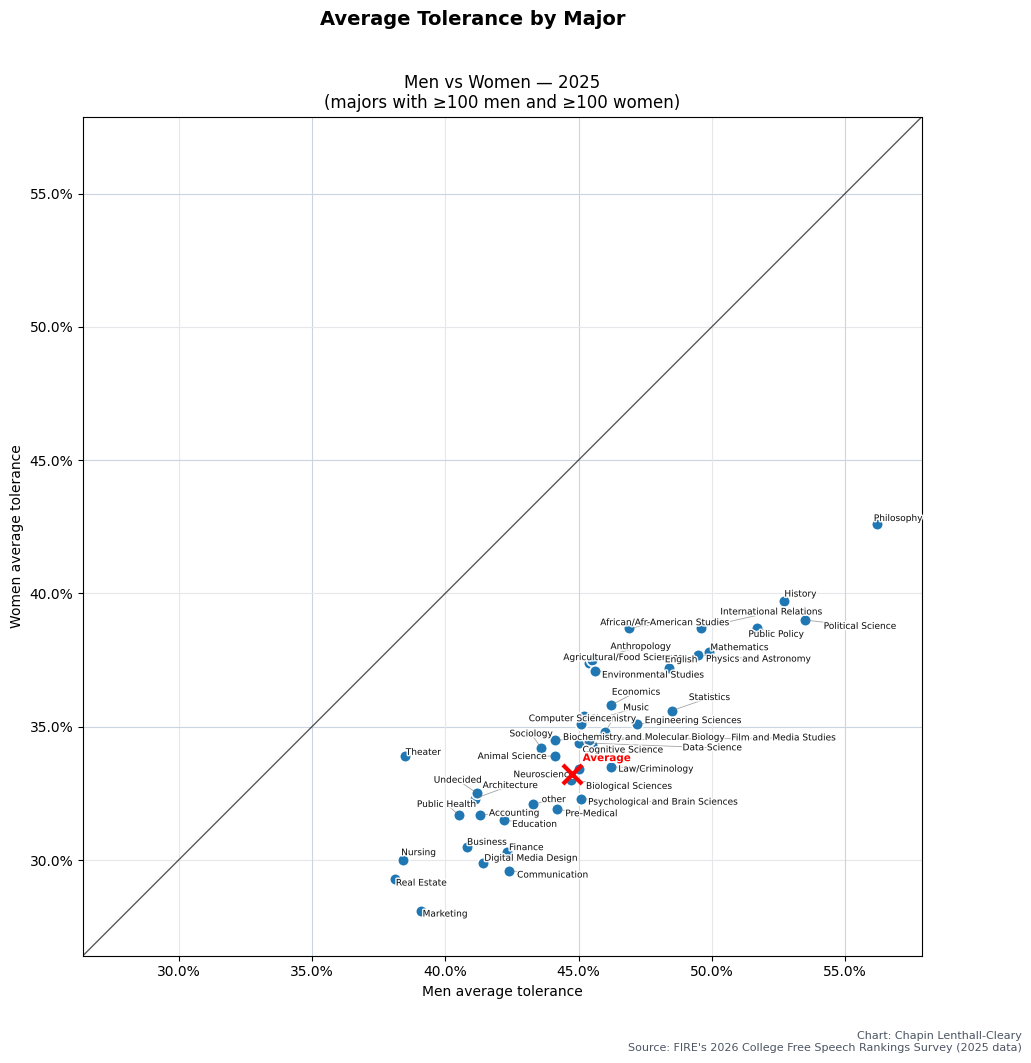

Saved: /Users/chapin.lenthall-cleary/scatter_major_male_vs_female_tolerance.png


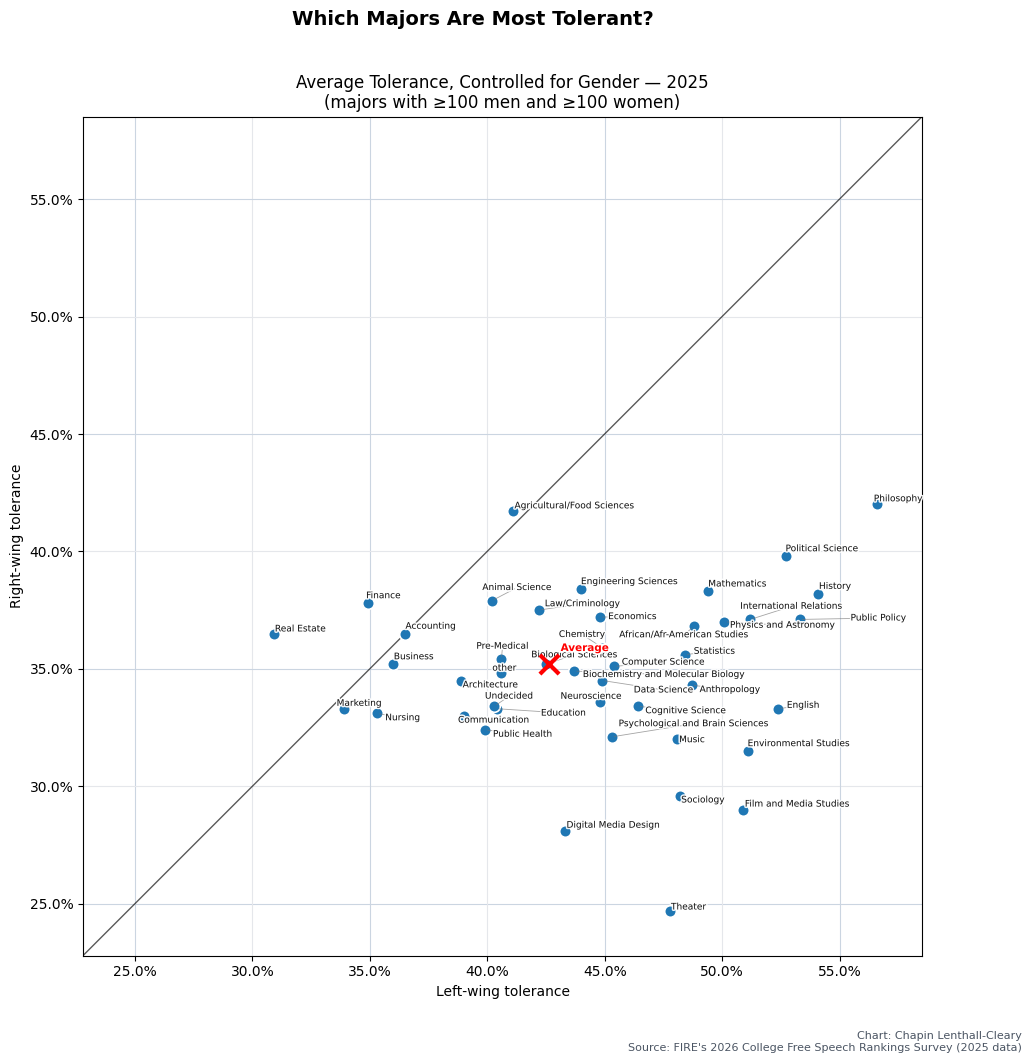

Saved: /Users/chapin.lenthall-cleary/scatter_major_left_vs_right_mfavg.png


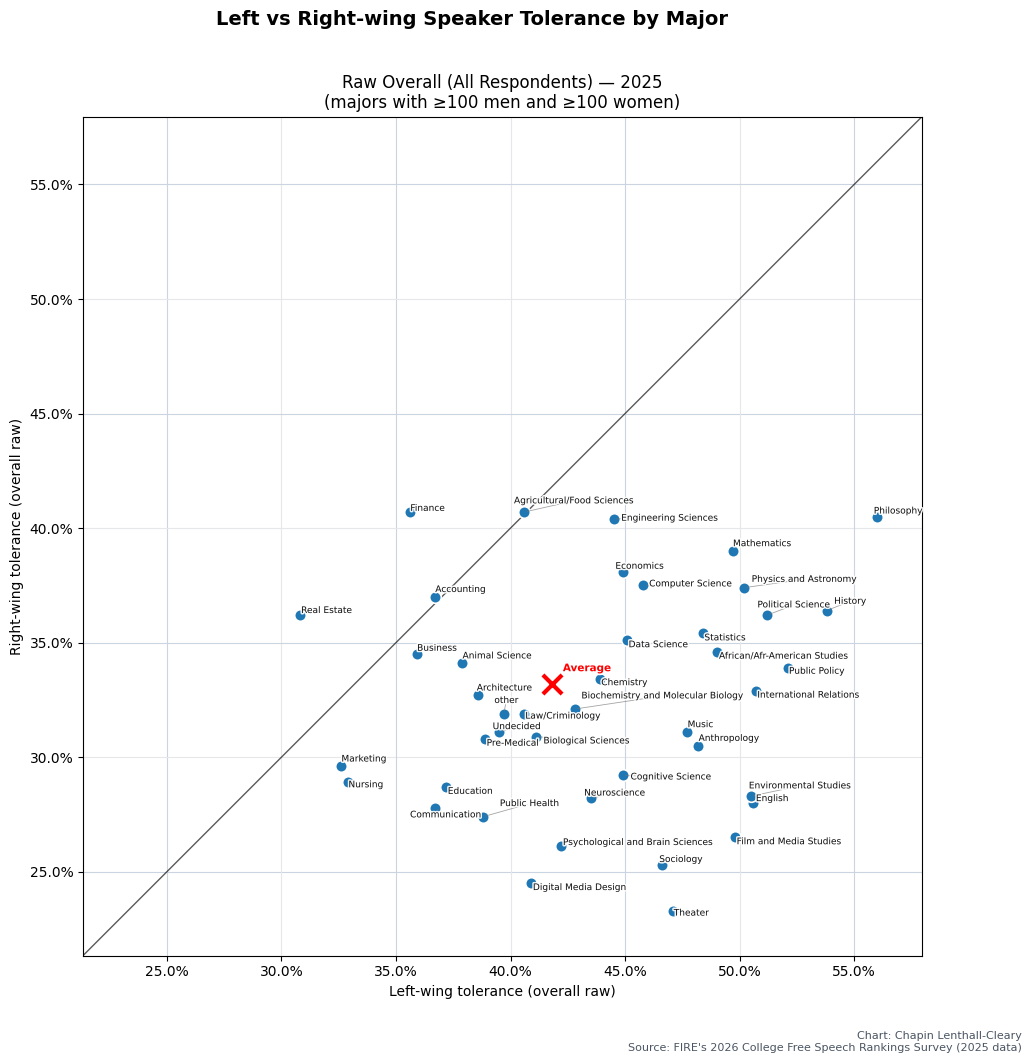

Saved: /Users/chapin.lenthall-cleary/scatter_major_left_vs_right_raw.png


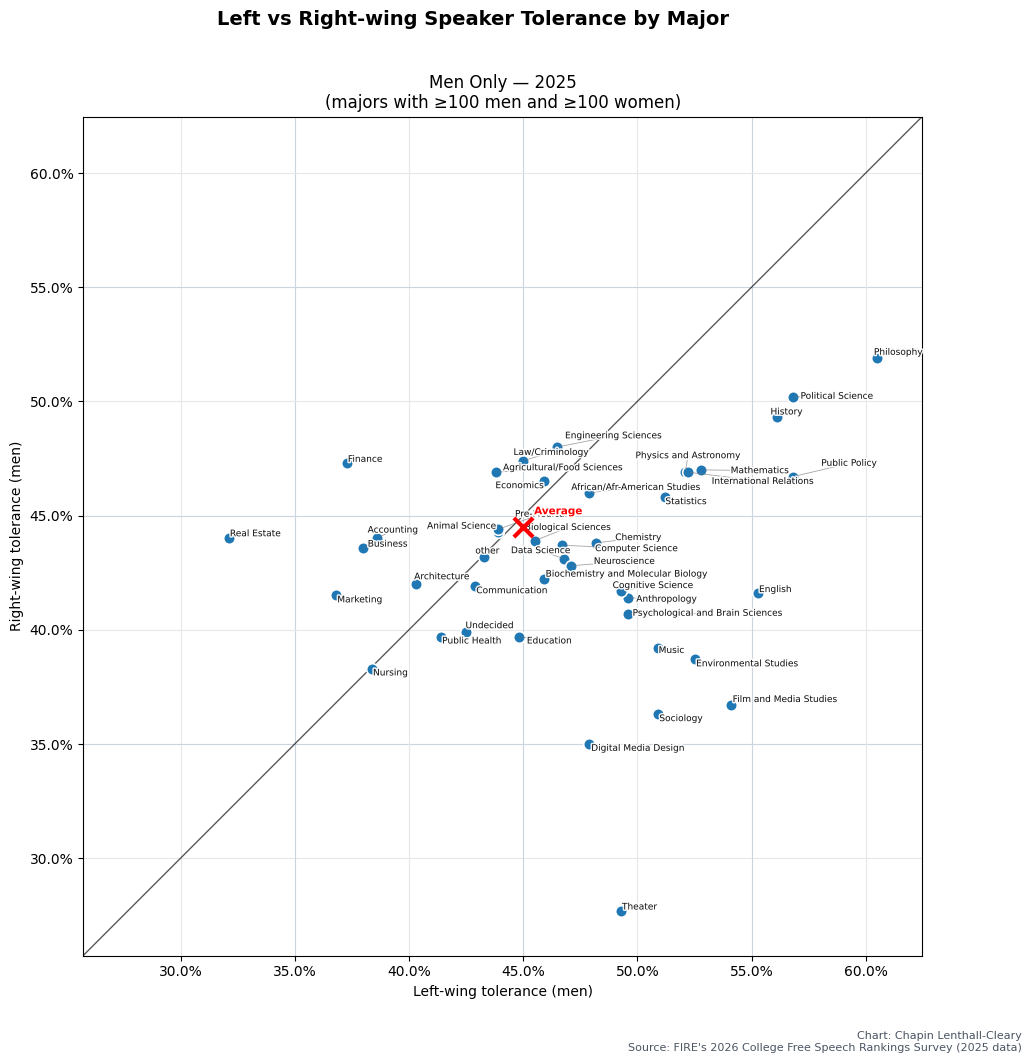

Saved: /Users/chapin.lenthall-cleary/scatter_major_left_vs_right_men.png


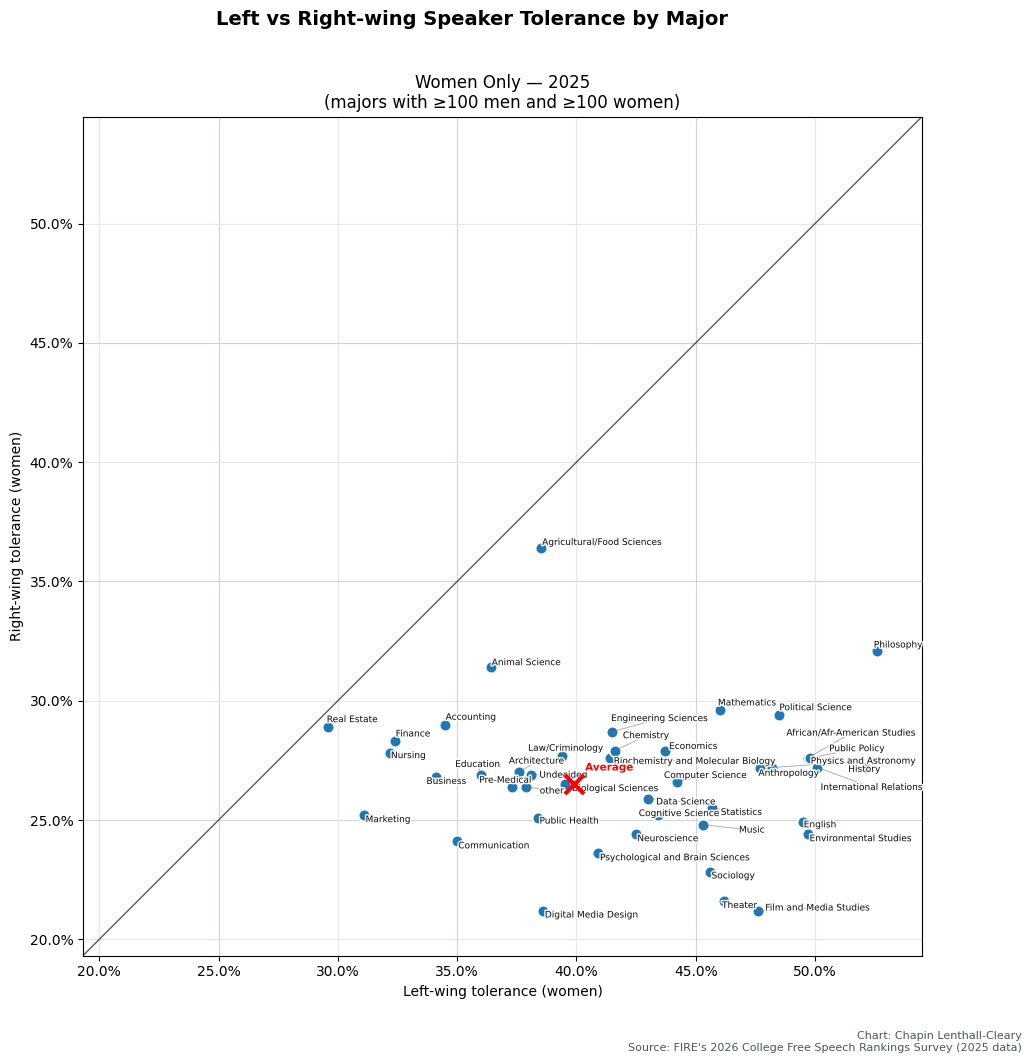

Saved: /Users/chapin.lenthall-cleary/scatter_major_left_vs_right_women.png


In [8]:
#I used plot 2.
#!/usr/bin/env python3
"""
Major-level scatterplots (one point per major), restricted to majors with
>= 100 men and >= 100 women (unique respondents within the major, across major1/2/3).

Plots:
1) Men vs Women overall tolerance (x = men avg, y = women avg)
2) Left vs Right tolerance — MF Average (x = avg(male_left, female_left), y = avg(male_right, female_right))
3) Left vs Right tolerance — Raw Overall (x = mean(left), y = mean(right) across all respondents in major)
4) Left vs Right tolerance — Men only (x = male_left mean, y = male_right mean)
5) Left vs Right tolerance — Women only (x = female_left mean, y = female_right mean)

Adds to EVERY plot:
• A population-weighted red “X” labeled “Average”
• A plot-specific figure supertitle (passed per plot call)
• Bottom-right credits label (like your example)
• Reduced gap between suptitle and the axes title

Requires (recommended):
  pip install adjustText

Saves:
  - scatter_major_male_vs_female_tolerance.png
  - scatter_major_left_vs_right_mfavg.png
  - scatter_major_left_vs_right_raw.png
  - scatter_major_left_vs_right_men.png
  - scatter_major_left_vs_right_women.png
"""

from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import matplotlib.patheffects as pe

# --- adjustText (optional but recommended) ---
try:
    from adjustText import adjust_text
    HAS_ADJUSTTEXT = True
except ImportError:
    HAS_ADJUSTTEXT = False

# ---------------- Config ----------------
CSV_PATH = Path("cfsr2026.csv")

MAJOR_COLS = ["major1", "major2", "major3"]
GENDER_COL = "gender"     # 1 = men, 2 = women
SPK_PREFIX = "spk"        # overall tolerance items prefix (for tolerance_score_pct)
ITEM_MIN, ITEM_MAX = 1, 4

# Optional year filter (applies only if YEAR_COL exists in the file)
YEAR_COL = "datayear"
YEAR = 2025  # set to None to disable filtering

MIN_MEN = 100
MIN_WOMEN = 100

# Left/Right triads using YOUR column names
RIGHT_TRIAD = ["spkabortion", "spktrans", "spkblm"]          # "Right-wing Speakers"
LEFT_TRIAD  = ["spkchurch", "spkpolice", "spkchildren"]      # "Left-wing Speakers"
SPK_LR = RIGHT_TRIAD + LEFT_TRIAD

# Figure size: 30% larger
FIG_W, FIG_H = 8.8 * 1.3, 8.6 * 1.3

# Labeling (slightly smaller)
LABEL_FONTSIZE = 6.5
LABEL_ALPHA = 0.92

# Zoom buffer
BUFFER_PP_MIN = 1.5
BUFFER_FRAC = 0.06

# ---- Suptitle / credits like your example ----
CREDIT_TEXT = (
    "Chart: Chapin Lenthall-Cleary\n"
    "Source: FIRE's 2026 College Free Speech Rankings Survey (2025 data)"
)

# Less vertical gap between suptitle and axes title:
SUPTITLE_Y = 0.958
TITLE_PAD = 6  # smaller title padding
# tight_layout rect: [left, bottom, right, top] — give axes more vertical room (less whitespace)
TIGHT_LAYOUT_RECT = [0.02, 0.06, 0.98, 0.945]

CREDIT_X, CREDIT_Y = 0.98, 0.025
CREDIT_COLOR = "#4b5563"
# ----------------------------------------

# ---- major codebook (as provided) ----
MAJOR_MAP = {
    1: "Accounting",
    2: "African/Afr-American Studies",
    3: "Agricultural/Food Sciences",
    4: "Animal Science",
    5: "Anthropology",
    6: "Archaeology",
    7: "Architecture",
    8: "Art History",
    9: "Asian/Mideast Lang & Lit",
    10: "Asian/Mideast Studies",
    11: "Physics and Astronomy",
    12: "Biochemistry and Molecular Biology",
    13: "Biological Sciences",
    14: "Business",
    15: "Chemistry",
    16: "Classics",
    17: "Cognitive Science",
    18: "Communication",
    19: "Computer Science",
    20: "Dance",
    21: "Data Science",
    22: "Development Studies",
    23: "Digital Media Design",
    24: "Earth Sciences",
    25: "Economics",
    26: "Education",
    27: "Engineering Sciences",
    28: "English",
    29: "Environmental Studies",
    30: "Ethnicity and Race Studies",
    31: "European Cultural Studies",
    32: "Fashion",
    33: "Film and Media Studies",
    34: "Finance",
    35: "Fine Arts",
    36: "French and Italian",
    37: "Geography",
    38: "German Studies",
    39: "History",
    40: "Hotel Administration",
    41: "International Relations",
    42: "Jewish Studies",
    43: "Lat Am/Latino/Carib Studies",
    44: "Law/Criminology",
    45: "Linguistics",
    46: "Marketing",
    47: "Mathematics",
    48: "Music",
    50: "Neuroscience",
    51: "Nursing",
    52: "Philosophy",
    53: "Physical Education",
    54: "Political Science",
    55: "Portuguese and Brazilian Studies",
    56: "Pre-Medical",
    57: "Psychological and Brain Sciences",
    58: "Public Health",
    59: "Public Policy",
    61: "Real Estate",
    62: "Religion",
    63: "Robotics and Intelligent Systems",
    65: "Sociology",
    66: "Spanish and Portuguese",
    67: "Statistics",
    68: "Studio Art",
    69: "Theater",
    70: "Undecided",
    71: "Urban Studies",
    72: "Visual Arts",
    73: "Women's and Gender Studies",
    74: "other",
}
EXCLUDE_MAJOR_CODES = {98, 99}


def ensure_tolerance(df: pd.DataFrame,
                     prefix: str = SPK_PREFIX,
                     min_val: int = ITEM_MIN,
                     max_val: int = ITEM_MAX) -> pd.DataFrame:
    """Add tolerance_score_pct if missing, using all columns starting with prefix."""
    if "tolerance_score_pct" in df.columns:
        return df

    spk_cols = [c for c in df.columns if c.lower().startswith(prefix.lower())]
    if not spk_cols:
        raise ValueError(
            f"No tolerance items found (expected columns starting with '{prefix}') "
            "or an existing 'tolerance_score_pct'."
        )

    df[spk_cols] = df[spk_cols].apply(pd.to_numeric, errors="coerce")
    answered = df[spk_cols].notna().sum(axis=1)
    raw_sum = df[spk_cols].sum(axis=1, min_count=1)
    min_sum = answered * min_val
    max_sum = answered * max_val

    with np.errstate(invalid="ignore", divide="ignore"):
        pct = ((raw_sum - min_sum) / (max_sum - min_sum)) * 100

    df["tolerance_score_pct"] = np.where(answered > 0, np.clip(pct, 0, 100), np.nan).round(1)
    return df


def scale_triad_to_pct(sum_vals: pd.Series, k: int) -> pd.Series:
    """Maps triad sum (k..4k) to 0..100%."""
    return (sum_vals - k) / (3 * k) * 100.0


def alternating_grid(ax):
    """Alternating 5% gridlines (light / light-medium gray)."""
    light_gray, medium_gray = "#e5e7eb", "#cbd5e1"
    for v in range(0, 101, 5):
        ax.axhline(v, color=(light_gray if (v // 5) % 2 == 0 else medium_gray), linewidth=0.8, zorder=0)
        ax.axvline(v, color=(light_gray if (v // 5) % 2 == 0 else medium_gray), linewidth=0.8, zorder=0)


def pick_tick_step(span: float) -> int:
    if span <= 20:
        return 2
    if span <= 40:
        return 5
    return 10


def set_square_zoom(ax, x: pd.Series, y: pd.Series):
    """Zoom to points with buffer; same limits on x and y."""
    x = pd.to_numeric(x, errors="coerce").dropna()
    y = pd.to_numeric(y, errors="coerce").dropna()
    if x.empty or y.empty:
        ax.set_xlim(0, 100)
        ax.set_ylim(0, 100)
        return (0.0, 100.0)

    minv = float(min(x.min(), y.min()))
    maxv = float(max(x.max(), y.max()))
    span = max(1e-6, maxv - minv)

    buffer = max(BUFFER_PP_MIN, BUFFER_FRAC * span)
    lo = max(0.0, minv - buffer)
    hi = min(100.0, maxv + buffer)

    if hi - lo < 5:
        mid = (hi + lo) / 2.0
        lo = max(0.0, mid - 2.5)
        hi = min(100.0, mid + 2.5)

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)

    step = pick_tick_step(hi - lo)
    start = int(np.ceil(lo / step) * step)
    end = int(np.floor(hi / step) * step)
    ax.set_xticks(list(range(start, end + 1, step)))
    ax.set_yticks(list(range(start, end + 1, step)))

    return (lo, hi)


def label_points(ax, df_points: pd.DataFrame, xcol: str, ycol: str, label_col: str):
    """Label every point; repel with adjustText if available."""
    if not HAS_ADJUSTTEXT:
        print("adjustText not installed; using offset label fallback. Install with: pip install adjustText")
        offsets = [(4, 4), (4, -6), (-6, 4), (-6, -6), (6, 0), (0, 6), (-8, 0), (0, -8)]
        for i, (_, r) in enumerate(df_points.iterrows()):
            dx, dy = offsets[i % len(offsets)]
            ax.annotate(
                str(r[label_col]),
                (float(r[xcol]), float(r[ycol])),
                textcoords="offset points",
                xytext=(dx, dy),
                ha="left" if dx >= 0 else "right",
                va="bottom" if dy >= 0 else "top",
                fontsize=LABEL_FONTSIZE,
                alpha=LABEL_ALPHA,
                zorder=4,
                path_effects=[pe.withStroke(linewidth=2.2, foreground="white")]
            )
        return

    texts = []
    for _, r in df_points.iterrows():
        t = ax.text(
            float(r[xcol]), float(r[ycol]), str(r[label_col]),
            fontsize=LABEL_FONTSIZE, alpha=LABEL_ALPHA, zorder=4,
            path_effects=[pe.withStroke(linewidth=2.2, foreground="white")]
        )
        texts.append(t)

    adjust_text(
        texts,
        ax=ax,
        expand_points=(1.25, 1.35),
        expand_text=(1.10, 1.25),
        force_points=0.10,
        force_text=0.35,
        lim=250,
        arrowprops=dict(arrowstyle="-", lw=0.6, color="0.45", alpha=0.65),
    )


def build_major_long(df: pd.DataFrame, id_vars: list) -> pd.DataFrame:
    """Melt majors long, filter valid codes, de-dupe per person/major."""
    if "respondent_id" not in df.columns:
        df = df.reset_index().rename(columns={"index": "respondent_id"})

    for col in MAJOR_COLS:
        if col not in df.columns:
            raise ValueError(f"Missing required column '{col}'.")
        df[col] = pd.to_numeric(df[col], errors="coerce")

    valid_codes = set(MAJOR_MAP.keys()) - EXCLUDE_MAJOR_CODES

    long = (
        df.melt(
            id_vars=id_vars,
            value_vars=MAJOR_COLS,
            var_name="major_slot",
            value_name="major_code",
        )
        .dropna(subset=["major_code"])
        .copy()
    )
    long["major_code"] = pd.to_numeric(long["major_code"], errors="coerce").astype("Int64")
    long = long[long["major_code"].isin(valid_codes)].copy()

    return long.drop_duplicates(subset=["respondent_id", "major_code"])


def pivot_gender_means(agg: pd.DataFrame, value_cols: list) -> pd.DataFrame:
    """Wide male_*/female_* plus male_n/female_n."""
    piv_vals = agg.pivot(index="major_code", columns=GENDER_COL, values=value_cols)
    piv_n = agg.pivot(index="major_code", columns=GENDER_COL, values=["n"])

    def rename_cols(cols):
        out = []
        for metric, gender in cols:
            sex = "male" if int(gender) == 1 else "female"
            out.append(f"{sex}_{metric}")
        return out

    piv_vals.columns = rename_cols(piv_vals.columns)
    piv_n.columns = rename_cols(piv_n.columns)

    return pd.concat([piv_vals, piv_n], axis=1).reset_index()


def filter_min_counts(df_wide: pd.DataFrame) -> pd.DataFrame:
    df_wide["male_n"] = pd.to_numeric(df_wide.get("male_n"), errors="coerce")
    df_wide["female_n"] = pd.to_numeric(df_wide.get("female_n"), errors="coerce")
    keep = (df_wide["male_n"] >= MIN_MEN) & (df_wide["female_n"] >= MIN_WOMEN)
    out = df_wide.loc[keep].copy()
    out["total_n"] = out["male_n"] + out["female_n"]
    return out


def scatter_major_plot(
    df_points: pd.DataFrame,
    x: str,
    y: str,
    title: str,
    xlabel: str,
    ylabel: str,
    out_path: Path,
    suptitle_text: str,
    weights_x: str,
    weights_y: Optional[str] = None,
    label_col: str = "major",
    credit_text: str = CREDIT_TEXT,
):
    """
    Population-weighted average marker:
      x_avg = weighted mean of x using df_points[weights_x]
      y_avg = weighted mean of y using df_points[weights_y] (defaults to weights_x)
    """
    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

    alternating_grid(ax)
    ax.scatter(df_points[x], df_points[y], s=70, edgecolor="white", linewidth=1.2, zorder=3)

    # ---------------- Population-weighted Average marker ----------------
    x_ser = pd.to_numeric(df_points[x], errors="coerce")
    y_ser = pd.to_numeric(df_points[y], errors="coerce")

    wx = pd.to_numeric(df_points.get(weights_x), errors="coerce")
    wy = pd.to_numeric(df_points.get(weights_y), errors="coerce") if weights_y else wx

    x_avg = np.nan
    y_avg = np.nan

    mx = x_ser.notna() & wx.notna() & (wx > 0)
    my = y_ser.notna() & wy.notna() & (wy > 0)

    if mx.any():
        x_avg = float(np.average(x_ser[mx], weights=wx[mx]))
    if my.any():
        y_avg = float(np.average(y_ser[my], weights=wy[my]))

    if np.isfinite(x_avg) and np.isfinite(y_avg):
        ax.scatter([x_avg], [y_avg],
                   marker="x", s=190, linewidths=3.0, color="red", zorder=4.6)
        ax.annotate(
            "Average",
            (x_avg, y_avg),
            textcoords="offset points",
            xytext=(8, 8),
            ha="left",
            va="bottom",
            fontsize=LABEL_FONTSIZE + 1,
            fontweight="bold",
            color="red",
            zorder=5,
            path_effects=[pe.withStroke(linewidth=2.6, foreground="white")]
        )
    # -------------------------------------------------------------------

    lo, hi = set_square_zoom(ax, df_points[x], df_points[y])

    # Parity line within zoom window
    ax.plot([lo, hi], [lo, hi], color="black", linewidth=1, alpha=0.65, zorder=1.5)

    ax.set_title(title, pad=TITLE_PAD)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_aspect("equal", adjustable="box")
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=100))
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))

    label_points(ax, df_points, x, y, label_col)

    # --- Figure-level supertitle + credits ---
    fig.suptitle(suptitle_text, fontsize=14, fontweight="bold", y=SUPTITLE_Y)
    fig.text(
        CREDIT_X, CREDIT_Y, credit_text,
        ha="right", va="bottom", fontsize=8, color=CREDIT_COLOR
    )

    fig.tight_layout(rect=TIGHT_LAYOUT_RECT)
    fig.savefig(out_path, dpi=150)
    plt.show()
    print(f"Saved: {out_path.resolve()}")


def main():
    df = pd.read_csv(CSV_PATH, low_memory=False)

    # Optional year filter
    if YEAR is not None and YEAR_COL in df.columns:
        df[YEAR_COL] = pd.to_numeric(df[YEAR_COL], errors="coerce")
        df = df[df[YEAR_COL] == YEAR].copy()

    # Keep only men/women
    df[GENDER_COL] = pd.to_numeric(df[GENDER_COL], errors="coerce")
    df = df[df[GENDER_COL].isin([1, 2])].copy()
    if df.empty:
        raise SystemExit("No rows after filtering to men/women (gender in [1,2]).")

    # ---------------- Plot 1: Male vs Female overall tolerance by major ----------------
    df1 = ensure_tolerance(df.copy())

    long1 = build_major_long(
        df1,
        id_vars=["respondent_id", GENDER_COL, "tolerance_score_pct"]
    )
    long1["tolerance_score_pct"] = pd.to_numeric(long1["tolerance_score_pct"], errors="coerce")
    long1 = long1.dropna(subset=["tolerance_score_pct"])

    agg1 = (long1.groupby(["major_code", GENDER_COL], as_index=False)
                .agg(tolerance=("tolerance_score_pct", "mean"),
                     n=("respondent_id", "nunique")))
    wide1 = pivot_gender_means(agg1, ["tolerance"])
    wide1 = filter_min_counts(wide1)

    wide1["male_tolerance"] = pd.to_numeric(wide1["male_tolerance"], errors="coerce").round(1)
    wide1["female_tolerance"] = pd.to_numeric(wide1["female_tolerance"], errors="coerce").round(1)
    wide1["major"] = wide1["major_code"].map(MAJOR_MAP)

    scatter_major_plot(
        df_points=wide1,
        x="male_tolerance",
        y="female_tolerance",
        suptitle_text="Average Tolerance by Major",
        title=f"Men vs Women"
              f"{'' if YEAR is None else f' — {YEAR}'}\n(majors with ≥{MIN_MEN} men and ≥{MIN_WOMEN} women)",
        xlabel="Men average tolerance",
        ylabel="Women average tolerance",
        out_path=Path("scatter_major_male_vs_female_tolerance.png"),
        label_col="major",
        # population-weighted averages:
        weights_x="male_n",
        weights_y="female_n",
    )

    # ---------------- Left/Right tolerance per respondent ----------------
    df2 = df.copy()

    for c in SPK_LR:
        if c not in df2.columns:
            raise ValueError(f"Missing required column '{c}' for left/right triads.")
        df2[c] = pd.to_numeric(df2[c], errors="coerce")

    in_range = df2[SPK_LR].ge(1) & df2[SPK_LR].le(4)
    df2 = df2[in_range.all(axis=1)].copy()
    if df2.empty:
        raise SystemExit("No rows remain after requiring all six left/right spk* to be in [1,4].")

    df2["right_sum"] = df2[RIGHT_TRIAD].sum(axis=1)
    df2["left_sum"] = df2[LEFT_TRIAD].sum(axis=1)
    df2["right_pct"] = scale_triad_to_pct(df2["right_sum"], k=len(RIGHT_TRIAD))
    df2["left_pct"] = scale_triad_to_pct(df2["left_sum"], k=len(LEFT_TRIAD))

    long2 = build_major_long(
        df2,
        id_vars=["respondent_id", GENDER_COL, "left_pct", "right_pct"]
    )

    # Gender-specific means (used for MF-average + men-only + women-only)
    agg2 = (long2.groupby(["major_code", GENDER_COL], as_index=False)
                .agg(left_avg=("left_pct", "mean"),
                     right_avg=("right_pct", "mean"),
                     n=("respondent_id", "nunique")))
    wide2 = pivot_gender_means(agg2, ["left_avg", "right_avg"])

    # Raw overall left/right per major (ignoring gender)
    overall_lr = (long2.groupby("major_code", as_index=False)
                      .agg(left_raw=("left_pct", "mean"),
                           right_raw=("right_pct", "mean")))

    wide2 = wide2.merge(overall_lr, on="major_code", how="left")
    wide2["major"] = wide2["major_code"].map(MAJOR_MAP)

    # Apply min-count filter (based on gender counts) + add total_n
    wide2 = filter_min_counts(wide2)

    # MF-average inputs (unweighted average of male/female means)
    wide2["mf_left"] = wide2[["male_left_avg", "female_left_avg"]].mean(axis=1, skipna=True)
    wide2["mf_right"] = wide2[["male_right_avg", "female_right_avg"]].mean(axis=1, skipna=True)

    for c in [
        "mf_left", "mf_right", "left_raw", "right_raw",
        "male_left_avg", "male_right_avg", "female_left_avg", "female_right_avg",
    ]:
        if c in wide2.columns:
            wide2[c] = pd.to_numeric(wide2[c], errors="coerce").round(1)

    # Plot 2: MF average
    scatter_major_plot(
        df_points=wide2,
        x="mf_left",
        y="mf_right",
        suptitle_text="Which Majors Are Most Tolerant?",
        title=f"Average Tolerance, Controlled for Gender"
              f"{'' if YEAR is None else f' — {YEAR}'}\n(majors with ≥{MIN_MEN} men and ≥{MIN_WOMEN} women)",
        xlabel="Left-wing tolerance",
        ylabel="Right-wing tolerance",
        out_path=Path("scatter_major_left_vs_right_mfavg.png"),
        label_col="major",
        weights_x="total_n",
        weights_y="total_n",
    )

    # Plot 3: Raw overall
    scatter_major_plot(
        df_points=wide2,
        x="left_raw",
        y="right_raw",
        suptitle_text="Left vs Right-wing Speaker Tolerance by Major",
        title=f"Raw Overall (All Respondents)"
              f"{'' if YEAR is None else f' — {YEAR}'}\n(majors with ≥{MIN_MEN} men and ≥{MIN_WOMEN} women)",
        xlabel="Left-wing tolerance (overall raw)",
        ylabel="Right-wing tolerance (overall raw)",
        out_path=Path("scatter_major_left_vs_right_raw.png"),
        label_col="major",
        weights_x="total_n",
        weights_y="total_n",
    )

    # Plot 4: Men only
    scatter_major_plot(
        df_points=wide2,
        x="male_left_avg",
        y="male_right_avg",
        suptitle_text="Left vs Right-wing Speaker Tolerance by Major",
        title=f"Men Only"
              f"{'' if YEAR is None else f' — {YEAR}'}\n(majors with ≥{MIN_MEN} men and ≥{MIN_WOMEN} women)",
        xlabel="Left-wing tolerance (men)",
        ylabel="Right-wing tolerance (men)",
        out_path=Path("scatter_major_left_vs_right_men.png"),
        label_col="major",
        weights_x="male_n",
        weights_y="male_n",
    )

    # Plot 5: Women only
    scatter_major_plot(
        df_points=wide2,
        x="female_left_avg",
        y="female_right_avg",
        suptitle_text="Left vs Right-wing Speaker Tolerance by Major",
        title=f"Women Only"
              f"{'' if YEAR is None else f' — {YEAR}'}\n(majors with ≥{MIN_MEN} men and ≥{MIN_WOMEN} women)",
        xlabel="Left-wing tolerance (women)",
        ylabel="Right-wing tolerance (women)",
        out_path=Path("scatter_major_left_vs_right_women.png"),
        label_col="major",
        weights_x="female_n",
        weights_y="female_n",
    )


if __name__ == "__main__":
    main()


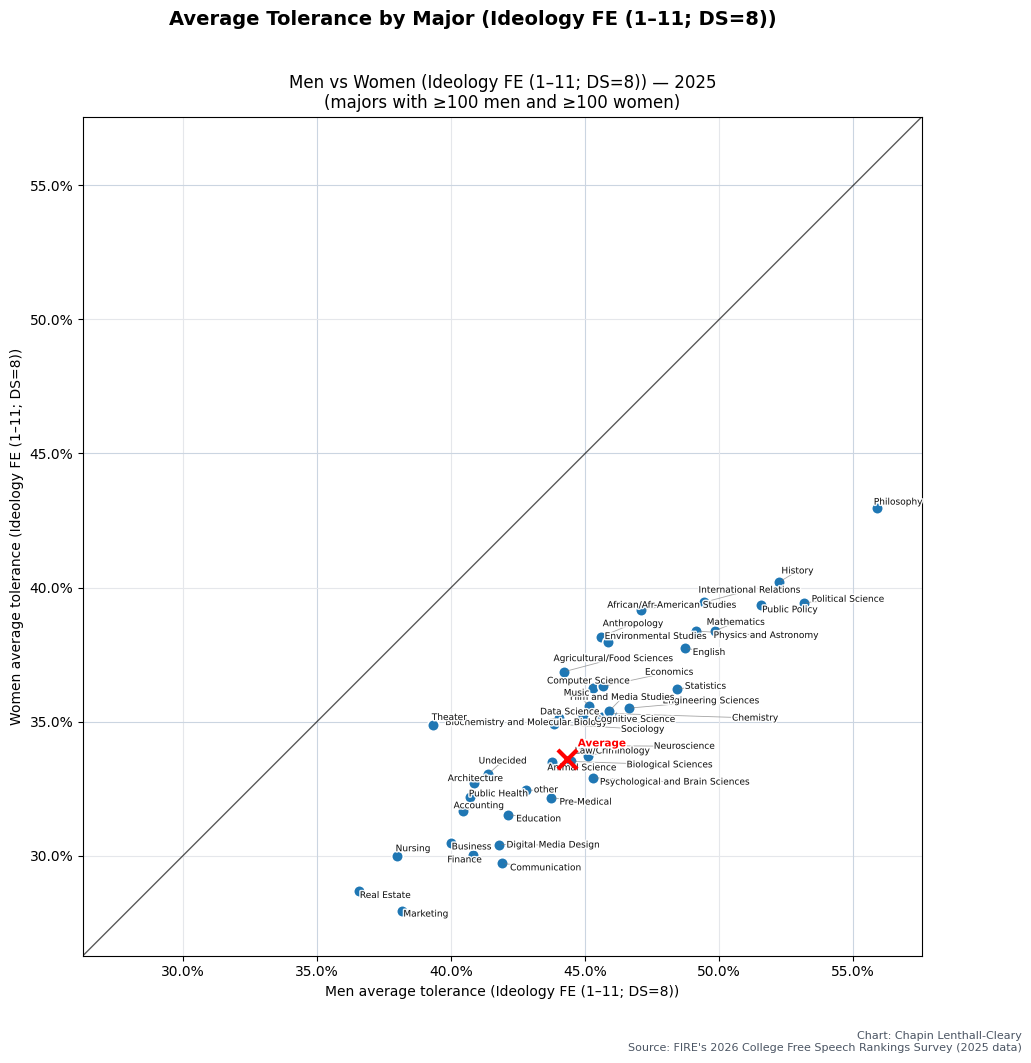

Saved: /Users/chapin.lenthall-cleary/scatter_major_male_vs_female_tolerance_ideoFE_all.png


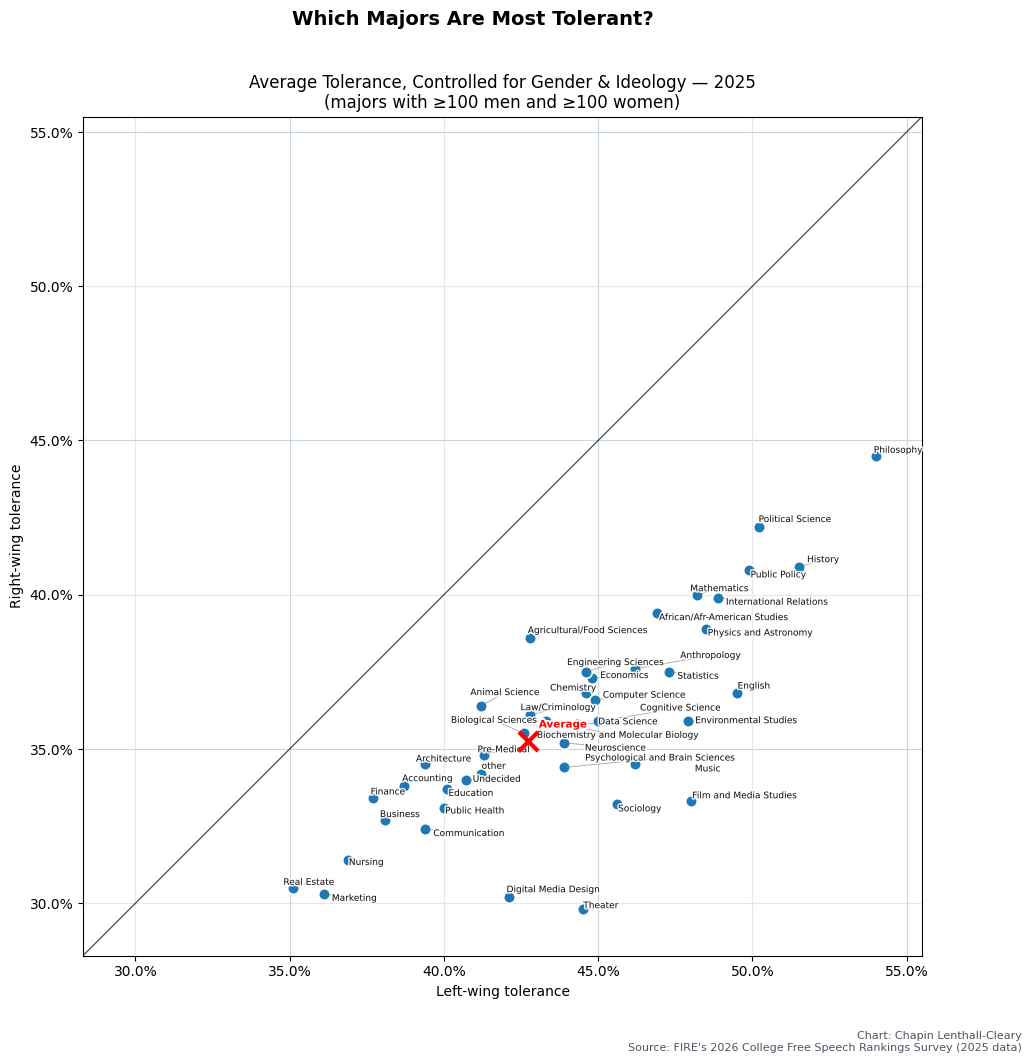

Saved: /Users/chapin.lenthall-cleary/scatter_major_left_vs_right_mfavg_ideoFE_all.png


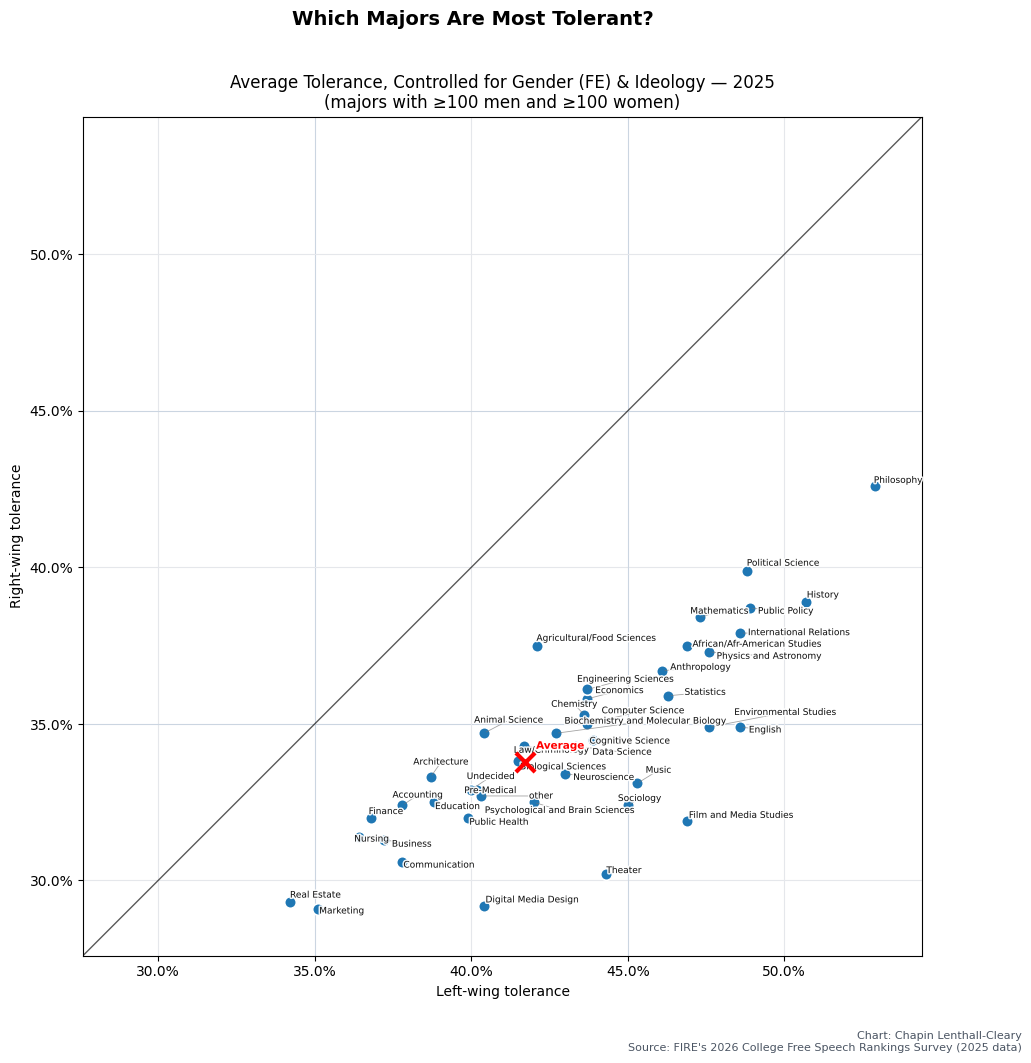

Saved: /Users/chapin.lenthall-cleary/scatter_major_left_vs_right_genderFE_ideoFE_all.png


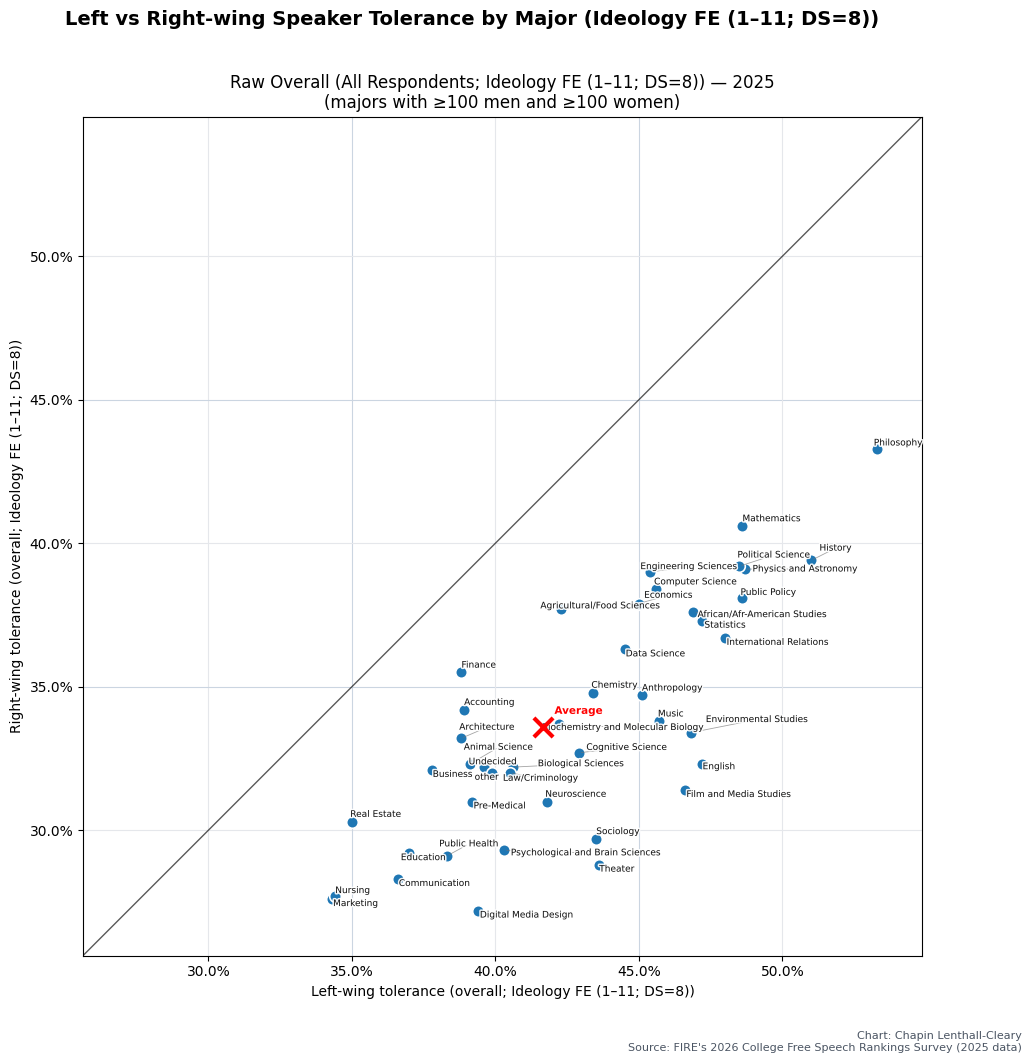

Saved: /Users/chapin.lenthall-cleary/scatter_major_left_vs_right_raw_ideoFE_all.png


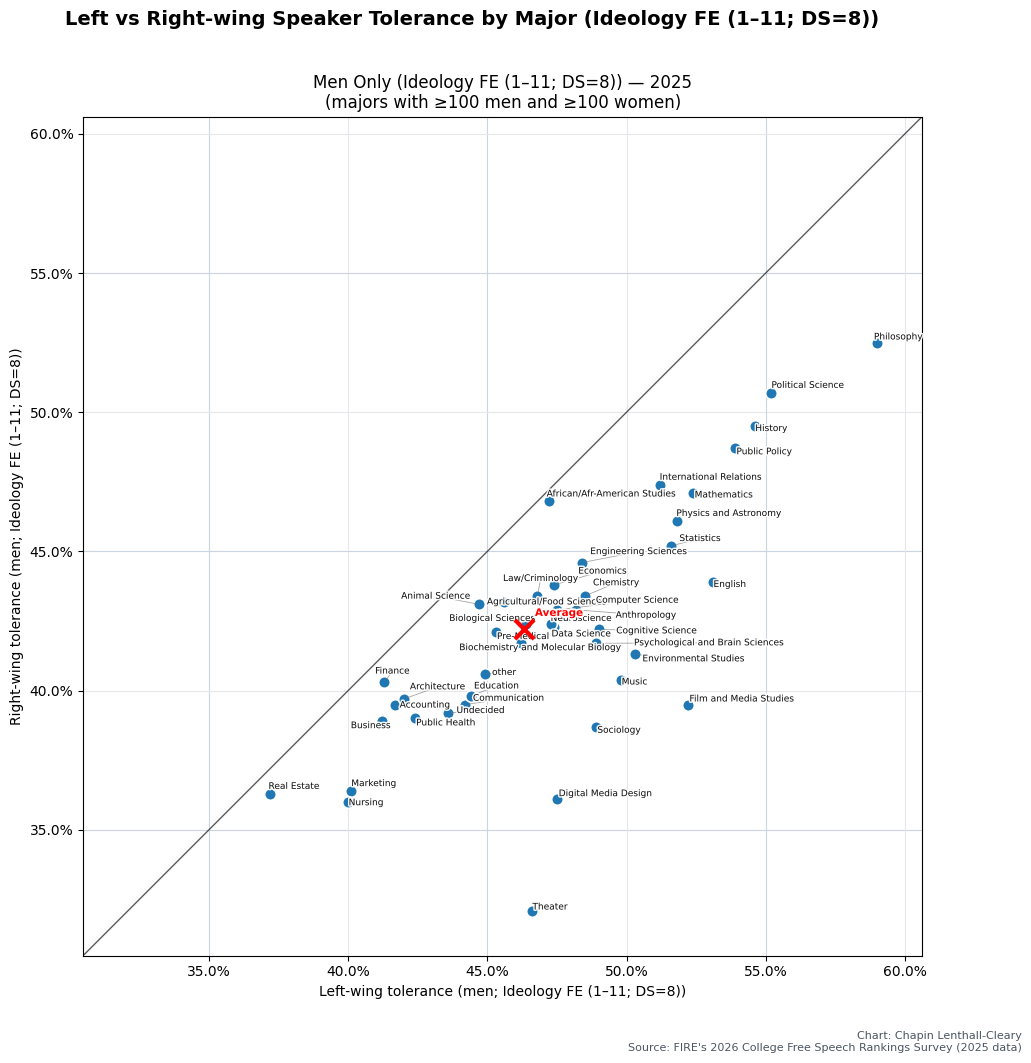

Saved: /Users/chapin.lenthall-cleary/scatter_major_left_vs_right_men_ideoFE_all.png


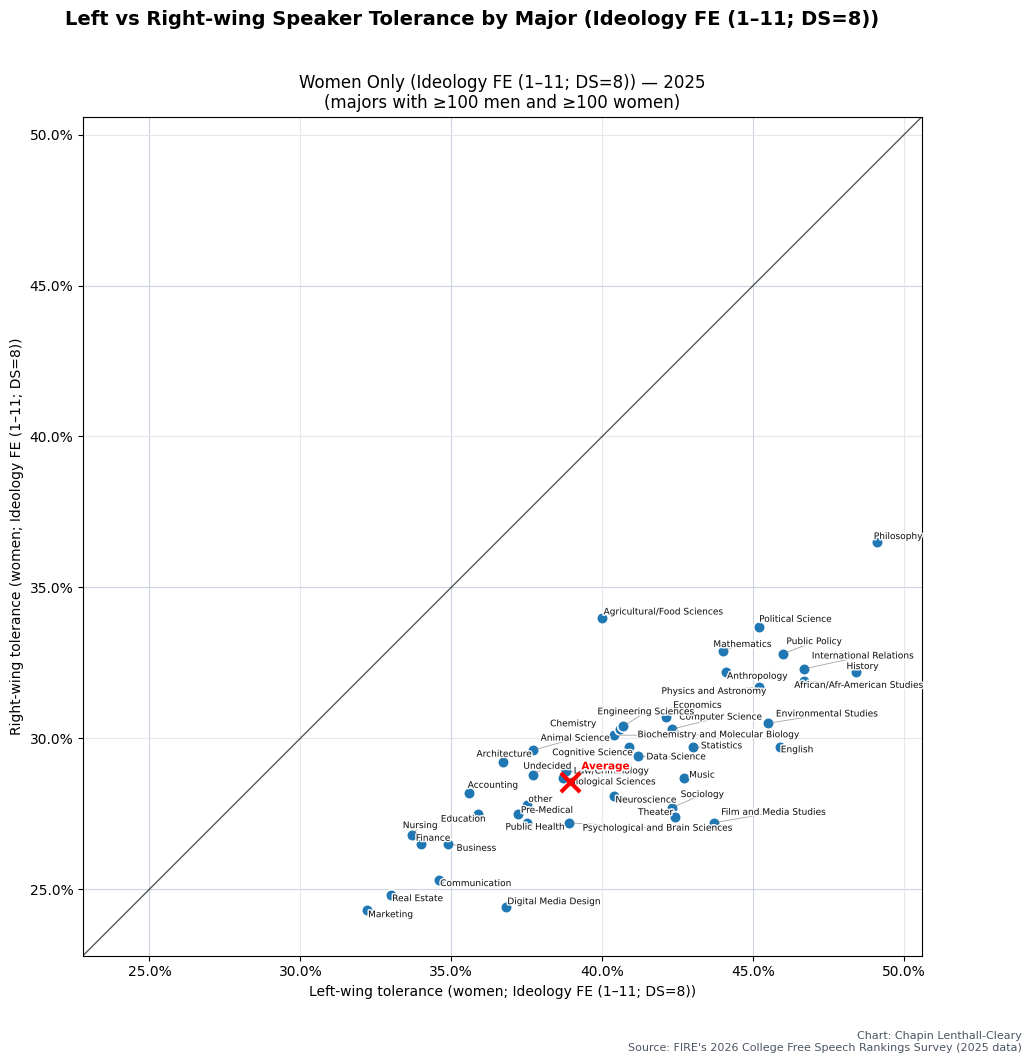

Saved: /Users/chapin.lenthall-cleary/scatter_major_left_vs_right_women_ideoFE_all.png


In [34]:
#I used plot 2.
#!/usr/bin/env python3
"""
Generate major-level scatterplots (one point per major), restricted to majors with
>= 100 men and >= 100 women (unique respondents per major across major1/2/3).

This script CONTAINS code for TWO ideology-control approaches:

SET A (Dummy regression / categorical FE)  ✅ RUNS BY DEFAULT
  - Uses all ideology categories 1..11 (NO recode; Democratic Socialists remain 8)
  - Controls ideology via fixed effects:
        y_adj = y - E[y | ideo] + E[y]

SET B (Linear ideology, restricted 1..7)   🚫 INCLUDED BUT NOT RUN BY DEFAULT
  - Keeps ideo in {1..7} only
  - Controls ideology via linear regression:
        y = a + b*ideo + e
        y_adj = y - b*(ideo - mean(ideo))

By default, ONLY the 6 plots from SET A are generated/shown/saved:
  1) Men vs Women overall tolerance (ideology-adjusted)
  2) Left vs Right tolerance by major using 50/50 M/F averaging (ideology-adjusted)
  3) Left vs Right tolerance by major using GENDER FE (ideology-adjusted, then gender-adjusted)
  4) Left vs Right raw overall (ideology-adjusted)
  5) Men-only (ideology-adjusted)
  6) Women-only (ideology-adjusted)

To run SET B too, flip RUN_LINEAR_1TO7 to True in main().
"""

from pathlib import Path
from typing import Optional, Callable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import matplotlib.patheffects as pe

# --- adjustText (optional but recommended) ---
try:
    from adjustText import adjust_text
    HAS_ADJUSTTEXT = True
except ImportError:
    HAS_ADJUSTTEXT = False

# ---------------- Config ----------------
CSV_PATH = Path("cfsr2026.csv")

MAJOR_COLS = ["major1", "major2", "major3"]
GENDER_COL = "gender"     # 1 = men, 2 = women
IDEO_COL = "ideo"

SPK_PREFIX = "spk"        # overall tolerance items prefix (for tolerance_score_pct)
ITEM_MIN, ITEM_MAX = 1, 4

# Optional year filter (applies only if YEAR_COL exists in the file)
YEAR_COL = "datayear"
YEAR = 2025  # set to None to disable filtering

MIN_MEN = 100
MIN_WOMEN = 100

# Left/Right triads using YOUR column names
RIGHT_TRIAD = ["spkabortion", "spktrans", "spkblm"]          # "Right-wing Speakers"
LEFT_TRIAD  = ["spkchurch", "spkpolice", "spkchildren"]      # "Left-wing Speakers"
SPK_LR = RIGHT_TRIAD + LEFT_TRIAD

# Keep adjusted outcomes on percent axes
CLIP_0_100_AFTER_ADJ = True

# Figure size: 30% larger
FIG_W, FIG_H = 8.8 * 1.3, 8.6 * 1.3

# Labeling (slightly smaller)
LABEL_FONTSIZE = 6.5
LABEL_ALPHA = 0.92

# Zoom buffer
BUFFER_PP_MIN = 1.5
BUFFER_FRAC = 0.06

# ---- Suptitle / credits ----
CREDIT_TEXT = (
    "Chart: Chapin Lenthall-Cleary\n"
    "Source: FIRE's 2026 College Free Speech Rankings Survey (2025 data)"
)
SUPTITLE_Y = 0.958
TITLE_PAD = 6
TIGHT_LAYOUT_RECT = [0.02, 0.06, 0.98, 0.945]
CREDIT_X, CREDIT_Y = 0.98, 0.025
CREDIT_COLOR = "#4b5563"
# ----------------------------------------

# ---- major codebook (as provided) ----
MAJOR_MAP = {
    1: "Accounting",
    2: "African/Afr-American Studies",
    3: "Agricultural/Food Sciences",
    4: "Animal Science",
    5: "Anthropology",
    6: "Archaeology",
    7: "Architecture",
    8: "Art History",
    9: "Asian/Mideast Lang & Lit",
    10: "Asian/Mideast Studies",
    11: "Physics and Astronomy",
    12: "Biochemistry and Molecular Biology",
    13: "Biological Sciences",
    14: "Business",
    15: "Chemistry",
    16: "Classics",
    17: "Cognitive Science",
    18: "Communication",
    19: "Computer Science",
    20: "Dance",
    21: "Data Science",
    22: "Development Studies",
    23: "Digital Media Design",
    24: "Earth Sciences",
    25: "Economics",
    26: "Education",
    27: "Engineering Sciences",
    28: "English",
    29: "Environmental Studies",
    30: "Ethnicity and Race Studies",
    31: "European Cultural Studies",
    32: "Fashion",
    33: "Film and Media Studies",
    34: "Finance",
    35: "Fine Arts",
    36: "French and Italian",
    37: "Geography",
    38: "German Studies",
    39: "History",
    40: "Hotel Administration",
    41: "International Relations",
    42: "Jewish Studies",
    43: "Lat Am/Latino/Carib Studies",
    44: "Law/Criminology",
    45: "Linguistics",
    46: "Marketing",
    47: "Mathematics",
    48: "Music",
    50: "Neuroscience",
    51: "Nursing",
    52: "Philosophy",
    53: "Physical Education",
    54: "Political Science",
    55: "Portuguese and Brazilian Studies",
    56: "Pre-Medical",
    57: "Psychological and Brain Sciences",
    58: "Public Health",
    59: "Public Policy",
    61: "Real Estate",
    62: "Religion",
    63: "Robotics and Intelligent Systems",
    65: "Sociology",
    66: "Spanish and Portuguese",
    67: "Statistics",
    68: "Studio Art",
    69: "Theater",
    70: "Undecided",
    71: "Urban Studies",
    72: "Visual Arts",
    73: "Women's and Gender Studies",
    74: "other",
}
EXCLUDE_MAJOR_CODES = {98, 99}


# ---------------- Scoring helpers ----------------
def ensure_tolerance(df: pd.DataFrame,
                     prefix: str = SPK_PREFIX,
                     min_val: int = ITEM_MIN,
                     max_val: int = ITEM_MAX) -> pd.DataFrame:
    """Add tolerance_score_pct if missing, using all columns starting with prefix."""
    if "tolerance_score_pct" in df.columns:
        return df

    spk_cols = [c for c in df.columns if c.lower().startswith(prefix.lower())]
    if not spk_cols:
        raise ValueError(
            f"No tolerance items found (expected columns starting with '{prefix}') "
            "or an existing 'tolerance_score_pct'."
        )

    df = df.copy()
    df[spk_cols] = df[spk_cols].apply(pd.to_numeric, errors="coerce")
    answered = df[spk_cols].notna().sum(axis=1)
    raw_sum = df[spk_cols].sum(axis=1, min_count=1)
    min_sum = answered * min_val
    max_sum = answered * max_val

    with np.errstate(invalid="ignore", divide="ignore"):
        pct = ((raw_sum - min_sum) / (max_sum - min_sum)) * 100

    df["tolerance_score_pct"] = np.where(answered > 0, np.clip(pct, 0, 100), np.nan).round(1)
    return df


def scale_triad_to_pct(sum_vals: pd.Series, k: int) -> pd.Series:
    """Maps triad sum (k..4k) to 0..100%."""
    return (sum_vals - k) / (3 * k) * 100.0


# ---------------- Ideology adjustment methods ----------------
def filter_ideology(df: pd.DataFrame, keep_codes: set[int]) -> pd.DataFrame:
    """Keep only rows with ideology codes in keep_codes (drops missing/other)."""
    if IDEO_COL not in df.columns:
        raise ValueError(f"Missing required column '{IDEO_COL}'.")
    df = df.copy()
    df[IDEO_COL] = pd.to_numeric(df[IDEO_COL], errors="coerce")
    return df[df[IDEO_COL].isin(keep_codes)].copy()


def residualize_categorical_fe(
    df: pd.DataFrame,
    value_cols: list[str],
    *,
    ideo_col: str = IDEO_COL,
    suffix: str = "_ideoadj",
    clip_0_100: bool = True
) -> pd.DataFrame:
    """
    Categorical fixed effects control (dummy-regression equivalent):
      y_adj = y - mean(y | group) + mean(y)

    By default group=IDEO_COL, but you can pass ideo_col=GENDER_COL (or any categorical).
    """
    df = df.copy()
    for col in value_cols:
        y = pd.to_numeric(df[col], errors="coerce")
        overall_mean = float(np.nanmean(y))

        means_by_group = (
            pd.DataFrame({ideo_col: df[ideo_col], col: y})
            .dropna(subset=[ideo_col, col])
            .groupby(ideo_col)[col]
            .mean()
        )

        adj = y - df[ideo_col].map(means_by_group) + overall_mean
        if clip_0_100:
            adj = np.clip(adj, 0, 100)
        df[col + suffix] = pd.to_numeric(adj, errors="coerce").round(1)

    return df


def residualize_linear_1to7(
    df: pd.DataFrame,
    value_cols: list[str],
    *,
    ideo_col: str = IDEO_COL,
    suffix: str = "_ideoadj",
    clip_0_100: bool = True
) -> pd.DataFrame:
    """
    Linear ideology control (ideo treated as numeric):
      y = a + b*ideo + e
      y_adj = y - b*(ideo - mean(ideo))
    """
    df = df.copy()
    x = pd.to_numeric(df[ideo_col], errors="coerce")

    for col in value_cols:
        y = pd.to_numeric(df[col], errors="coerce")
        m = x.notna() & y.notna()
        if not m.any():
            df[col + suffix] = np.nan
            continue

        xv = x[m].astype(float)
        yv = y[m].astype(float)

        xbar = float(xv.mean())
        ybar = float(yv.mean())
        varx = float(((xv - xbar) ** 2).mean())

        if varx <= 0:
            b = 0.0
        else:
            covxy = float(((xv - xbar) * (yv - ybar)).mean())
            b = covxy / varx

        adj = y - b * (x - xbar)
        if clip_0_100:
            adj = np.clip(adj, 0, 100)
        df[col + suffix] = pd.to_numeric(adj, errors="coerce").round(1)

    return df


# ---------------- Major reshaping helpers ----------------
def build_major_long(df: pd.DataFrame, id_vars: list) -> pd.DataFrame:
    """Melt majors long, filter valid codes, de-dupe per person/major."""
    df = df.copy()
    if "respondent_id" not in df.columns:
        df = df.reset_index().rename(columns={"index": "respondent_id"})

    for col in MAJOR_COLS:
        if col not in df.columns:
            raise ValueError(f"Missing required column '{col}'.")
        df[col] = pd.to_numeric(df[col], errors="coerce")

    valid_codes = set(MAJOR_MAP.keys()) - EXCLUDE_MAJOR_CODES

    long = (
        df.melt(
            id_vars=id_vars,
            value_vars=MAJOR_COLS,
            var_name="major_slot",
            value_name="major_code",
        )
        .dropna(subset=["major_code"])
        .copy()
    )
    long["major_code"] = pd.to_numeric(long["major_code"], errors="coerce").astype("Int64")
    long = long[long["major_code"].isin(valid_codes)].copy()

    return long.drop_duplicates(subset=["respondent_id", "major_code"])


def pivot_gender_means(agg: pd.DataFrame, value_cols: list) -> pd.DataFrame:
    """Wide male_*/female_* plus male_n/female_n."""
    piv_vals = agg.pivot(index="major_code", columns=GENDER_COL, values=value_cols)
    piv_n = agg.pivot(index="major_code", columns=GENDER_COL, values=["n"])

    def rename_cols(cols):
        out = []
        for metric, gender in cols:
            sex = "male" if int(gender) == 1 else "female"
            out.append(f"{sex}_{metric}")
        return out

    piv_vals.columns = rename_cols(piv_vals.columns)
    piv_n.columns = rename_cols(piv_n.columns)

    return pd.concat([piv_vals, piv_n], axis=1).reset_index()


def filter_min_counts(df_wide: pd.DataFrame) -> pd.DataFrame:
    df_wide = df_wide.copy()
    df_wide["male_n"] = pd.to_numeric(df_wide.get("male_n"), errors="coerce")
    df_wide["female_n"] = pd.to_numeric(df_wide.get("female_n"), errors="coerce")
    keep = (df_wide["male_n"] >= MIN_MEN) & (df_wide["female_n"] >= MIN_WOMEN)
    out = df_wide.loc[keep].copy()
    out["total_n"] = out["male_n"] + out["female_n"]
    return out


# ---------------- Plotting helpers ----------------
def alternating_grid(ax):
    """Alternating 5% gridlines (light / light-medium gray)."""
    light_gray, medium_gray = "#e5e7eb", "#cbd5e1"
    for v in range(0, 101, 5):
        ax.axhline(v, color=(light_gray if (v // 5) % 2 == 0 else medium_gray), linewidth=0.8, zorder=0)
        ax.axvline(v, color=(light_gray if (v // 5) % 2 == 0 else medium_gray), linewidth=0.8, zorder=0)


def pick_tick_step(span: float) -> int:
    if span <= 20:
        return 2
    if span <= 40:
        return 5
    return 10


def set_square_zoom(ax, x: pd.Series, y: pd.Series):
    """Zoom to points with buffer; same limits on x and y."""
    x = pd.to_numeric(x, errors="coerce").dropna()
    y = pd.to_numeric(y, errors="coerce").dropna()
    if x.empty or y.empty:
        ax.set_xlim(0, 100)
        ax.set_ylim(0, 100)
        return (0.0, 100.0)

    minv = float(min(x.min(), y.min()))
    maxv = float(max(x.max(), y.max()))
    span = max(1e-6, maxv - minv)

    buffer = max(BUFFER_PP_MIN, BUFFER_FRAC * span)
    lo = max(0.0, minv - buffer)
    hi = min(100.0, maxv + buffer)

    if hi - lo < 5:
        mid = (hi + lo) / 2.0
        lo = max(0.0, mid - 2.5)
        hi = min(100.0, mid + 2.5)

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)

    step = pick_tick_step(hi - lo)
    start = int(np.ceil(lo / step) * step)
    end = int(np.floor(hi / step) * step)
    ax.set_xticks(list(range(start, end + 1, step)))
    ax.set_yticks(list(range(start, end + 1, step)))

    return (lo, hi)


def label_points(ax, df_points: pd.DataFrame, xcol: str, ycol: str, label_col: str):
    """Label every point; repel with adjustText if available."""
    if not HAS_ADJUSTTEXT:
        offsets = [(4, 4), (4, -6), (-6, 4), (-6, -6), (6, 0), (0, 6), (-8, 0), (0, -8)]
        for i, (_, r) in enumerate(df_points.iterrows()):
            dx, dy = offsets[i % len(offsets)]
            ax.annotate(
                str(r[label_col]),
                (float(r[xcol]), float(r[ycol])),
                textcoords="offset points",
                xytext=(dx, dy),
                ha="left" if dx >= 0 else "right",
                va="bottom" if dy >= 0 else "top",
                fontsize=LABEL_FONTSIZE,
                alpha=LABEL_ALPHA,
                zorder=4,
                path_effects=[pe.withStroke(linewidth=2.2, foreground="white")]
            )
        return

    texts = []
    for _, r in df_points.iterrows():
        t = ax.text(
            float(r[xcol]), float(r[ycol]), str(r[label_col]),
            fontsize=LABEL_FONTSIZE, alpha=LABEL_ALPHA, zorder=4,
            path_effects=[pe.withStroke(linewidth=2.2, foreground="white")]
        )
        texts.append(t)

    adjust_text(
        texts,
        ax=ax,
        expand_points=(1.25, 1.35),
        expand_text=(1.10, 1.25),
        force_points=0.10,
        force_text=0.35,
        lim=250,
        arrowprops=dict(arrowstyle="-", lw=0.6, color="0.45", alpha=0.65),
    )


def scatter_major_plot(
    df_points: pd.DataFrame,
    x: str,
    y: str,
    title: str,
    xlabel: str,
    ylabel: str,
    out_path: Path,
    suptitle_text: str,
    weights_x: str,
    weights_y: Optional[str] = None,
    label_col: str = "major",
    credit_text: str = CREDIT_TEXT,
):
    """Scatter with population-weighted 'Average' marker."""
    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

    alternating_grid(ax)
    ax.scatter(df_points[x], df_points[y], s=70, edgecolor="white", linewidth=1.2, zorder=3)

    x_ser = pd.to_numeric(df_points[x], errors="coerce")
    y_ser = pd.to_numeric(df_points[y], errors="coerce")
    wx = pd.to_numeric(df_points.get(weights_x), errors="coerce")
    wy = pd.to_numeric(df_points.get(weights_y), errors="coerce") if weights_y else wx

    x_avg = np.nan
    y_avg = np.nan

    mx = x_ser.notna() & wx.notna() & (wx > 0)
    my = y_ser.notna() & wy.notna() & (wy > 0)

    if mx.any():
        x_avg = float(np.average(x_ser[mx], weights=wx[mx]))
    if my.any():
        y_avg = float(np.average(y_ser[my], weights=wy[my]))

    if np.isfinite(x_avg) and np.isfinite(y_avg):
        ax.scatter([x_avg], [y_avg], marker="x", s=190, linewidths=3.0, color="red", zorder=4.6)
        ax.annotate(
            "Average",
            (x_avg, y_avg),
            textcoords="offset points",
            xytext=(8, 8),
            ha="left",
            va="bottom",
            fontsize=LABEL_FONTSIZE + 1,
            fontweight="bold",
            color="red",
            zorder=5,
            path_effects=[pe.withStroke(linewidth=2.6, foreground="white")]
        )

    lo, hi = set_square_zoom(ax, df_points[x], df_points[y])
    ax.plot([lo, hi], [lo, hi], color="black", linewidth=1, alpha=0.65, zorder=1.5)

    ax.set_title(title, pad=TITLE_PAD)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_aspect("equal", adjustable="box")
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=100))
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))

    label_points(ax, df_points, x, y, label_col)

    fig.suptitle(suptitle_text, fontsize=14, fontweight="bold", y=SUPTITLE_Y)
    fig.text(CREDIT_X, CREDIT_Y, credit_text, ha="right", va="bottom", fontsize=8, color=CREDIT_COLOR)

    fig.tight_layout(rect=TIGHT_LAYOUT_RECT)
    fig.savefig(out_path, dpi=150)
    plt.show()
    print(f"Saved: {out_path.resolve()}")


# ---------------- Runner for each 6-plot set ----------------
def run_six_plots(
    df_base: pd.DataFrame,
    *,
    set_tag: str,
    set_desc: str,
    ideo_keep: set[int],
    residualize_fn: Callable[[pd.DataFrame, list[str]], pd.DataFrame],
):
    """Runs plots 1-6 using respondent-level ideology adjustment, then major aggregation."""
    df = filter_ideology(df_base, keep_codes=ideo_keep)
    if df.empty:
        print(f"[{set_tag}] No rows after ideology filter; skipping.")
        return

    # ---------- Plot 1: Men vs Women overall tolerance ----------
    df1 = ensure_tolerance(df.copy())
    df1 = residualize_fn(df1, ["tolerance_score_pct"])

    long1 = build_major_long(df1, id_vars=["respondent_id", GENDER_COL, "tolerance_score_pct_ideoadj"])
    long1["tolerance_score_pct_ideoadj"] = pd.to_numeric(long1["tolerance_score_pct_ideoadj"], errors="coerce")
    long1 = long1.dropna(subset=["tolerance_score_pct_ideoadj"])

    agg1 = (
        long1.groupby(["major_code", GENDER_COL], as_index=False)
        .agg(tolerance=("tolerance_score_pct_ideoadj", "mean"),
             n=("respondent_id", "nunique"))
    )
    wide1 = pivot_gender_means(agg1, ["tolerance"])
    wide1 = filter_min_counts(wide1)
    wide1["major"] = wide1["major_code"].map(MAJOR_MAP)

    scatter_major_plot(
        df_points=wide1,
        x="male_tolerance",
        y="female_tolerance",
        suptitle_text=f"Average Tolerance by Major ({set_desc})",
        title=f"Men vs Women ({set_desc}){'' if YEAR is None else f' — {YEAR}'}\n"
              f"(majors with ≥{MIN_MEN} men and ≥{MIN_WOMEN} women)",
        xlabel=f"Men average tolerance ({set_desc})",
        ylabel=f"Women average tolerance ({set_desc})",
        out_path=Path(f"scatter_major_male_vs_female_tolerance_{set_tag}.png"),
        label_col="major",
        weights_x="male_n",
        weights_y="female_n",
    )

    # ---------- Left/Right tolerance per respondent ----------
    df2 = df.copy()
    for c in SPK_LR:
        if c not in df2.columns:
            raise ValueError(f"Missing required column '{c}' for left/right triads.")
        df2[c] = pd.to_numeric(df2[c], errors="coerce")

    in_range = df2[SPK_LR].ge(1) & df2[SPK_LR].le(4)
    df2 = df2[in_range.all(axis=1)].copy()
    if df2.empty:
        print(f"[{set_tag}] No rows remain after requiring all six left/right spk* to be in [1,4].")
        return

    df2["right_sum"] = df2[RIGHT_TRIAD].sum(axis=1)
    df2["left_sum"] = df2[LEFT_TRIAD].sum(axis=1)
    df2["right_pct"] = scale_triad_to_pct(df2["right_sum"], k=len(RIGHT_TRIAD))
    df2["left_pct"] = scale_triad_to_pct(df2["left_sum"], k=len(LEFT_TRIAD))

    # Ideology adjustment (respondent-level)
    df2 = residualize_fn(df2, ["left_pct", "right_pct"])

    long2 = build_major_long(df2, id_vars=["respondent_id", GENDER_COL, "left_pct_ideoadj", "right_pct_ideoadj"])

    agg2 = (
        long2.groupby(["major_code", GENDER_COL], as_index=False)
        .agg(left_avg=("left_pct_ideoadj", "mean"),
             right_avg=("right_pct_ideoadj", "mean"),
             n=("respondent_id", "nunique"))
    )
    wide2 = pivot_gender_means(agg2, ["left_avg", "right_avg"])

    overall_lr = (
        long2.groupby("major_code", as_index=False)
        .agg(left_raw=("left_pct_ideoadj", "mean"),
             right_raw=("right_pct_ideoadj", "mean"))
    )

    wide2 = wide2.merge(overall_lr, on="major_code", how="left")
    wide2["major"] = wide2["major_code"].map(MAJOR_MAP)
    wide2 = filter_min_counts(wide2)

    # 50/50 split method (Plot 2)
    wide2["mf_left"] = wide2[["male_left_avg", "female_left_avg"]].mean(axis=1, skipna=True)
    wide2["mf_right"] = wide2[["male_right_avg", "female_right_avg"]].mean(axis=1, skipna=True)

    for c in ["mf_left", "mf_right", "left_raw", "right_raw",
              "male_left_avg", "male_right_avg", "female_left_avg", "female_right_avg"]:
        if c in wide2.columns:
            wide2[c] = pd.to_numeric(wide2[c], errors="coerce").round(1)

    # ---------- Plot 2: 50/50 M/F averaging (your prior method) ----------
    scatter_major_plot(
        df_points=wide2,
        x="mf_left",
        y="mf_right",
        suptitle_text="Which Majors Are Most Tolerant?",
        title=f"Average Tolerance, Controlled for Gender & Ideology"
              f"{'' if YEAR is None else f' — {YEAR}'}\n(majors with ≥{MIN_MEN} men and ≥{MIN_WOMEN} women)",
        xlabel="Left-wing tolerance",
        ylabel="Right-wing tolerance",
        out_path=Path(f"scatter_major_left_vs_right_mfavg_{set_tag}.png"),
        label_col="major",
        weights_x="total_n",
        weights_y="total_n",
    )

    # ---------- Plot 3 (NEW): control for gender via FE (like ideology), not 50/50 ----------
    # Start from respondent-level ideology-adjusted left/right, then de-mean by gender:
    df2_genderfe = residualize_categorical_fe(
        df2,
        ["left_pct_ideoadj", "right_pct_ideoadj"],
        ideo_col=GENDER_COL,          # treat gender like a categorical FE, same formula as ideology
        suffix="_genderadj",
        clip_0_100=CLIP_0_100_AFTER_ADJ,
    )

    long2_genderfe = build_major_long(
        df2_genderfe,
        id_vars=[
            "respondent_id",
            GENDER_COL,
            "left_pct_ideoadj_genderadj",
            "right_pct_ideoadj_genderadj",
        ],
    )

    # enforce ≥100 men and ≥100 women majors using the long data
    counts_genderfe = (
        long2_genderfe.groupby(["major_code", GENDER_COL], as_index=False)
        .agg(n=("respondent_id", "nunique"))
    )
    counts_wide_genderfe = (
        counts_genderfe.pivot(index="major_code", columns=GENDER_COL, values="n")
        .rename(columns={1: "male_n", 2: "female_n"})
        .reset_index()
    )

    overall_genderfe = (
        long2_genderfe.groupby("major_code", as_index=False)
        .agg(
            left_adj=("left_pct_ideoadj_genderadj", "mean"),
            right_adj=("right_pct_ideoadj_genderadj", "mean"),
        )
    )

    wide2_genderfe = overall_genderfe.merge(counts_wide_genderfe, on="major_code", how="left")
    wide2_genderfe = filter_min_counts(wide2_genderfe)
    wide2_genderfe["major"] = wide2_genderfe["major_code"].map(MAJOR_MAP)

    for c in ["left_adj", "right_adj"]:
        wide2_genderfe[c] = pd.to_numeric(wide2_genderfe[c], errors="coerce").round(1)

    scatter_major_plot(
        df_points=wide2_genderfe,
        x="left_adj",
        y="right_adj",
        suptitle_text="Which Majors Are Most Tolerant?",
        title=f"Average Tolerance, Controlled for Gender (FE) & Ideology"
              f"{'' if YEAR is None else f' — {YEAR}'}\n"
              f"(majors with ≥{MIN_MEN} men and ≥{MIN_WOMEN} women)",
        xlabel="Left-wing tolerance",
        ylabel="Right-wing tolerance",
        out_path=Path(f"scatter_major_left_vs_right_genderFE_{set_tag}.png"),
        label_col="major",
        weights_x="total_n",
        weights_y="total_n",
    )

    # ---------- Plot 4: Raw Overall (All respondents; ideology-adjusted only) ----------
    scatter_major_plot(
        df_points=wide2,
        x="left_raw",
        y="right_raw",
        suptitle_text=f"Left vs Right-wing Speaker Tolerance by Major ({set_desc})",
        title=f"Raw Overall (All Respondents; {set_desc})"
              f"{'' if YEAR is None else f' — {YEAR}'}\n(majors with ≥{MIN_MEN} men and ≥{MIN_WOMEN} women)",
        xlabel=f"Left-wing tolerance (overall; {set_desc})",
        ylabel=f"Right-wing tolerance (overall; {set_desc})",
        out_path=Path(f"scatter_major_left_vs_right_raw_{set_tag}.png"),
        label_col="major",
        weights_x="total_n",
        weights_y="total_n",
    )

    # ---------- Plot 5: Men only ----------
    scatter_major_plot(
        df_points=wide2,
        x="male_left_avg",
        y="male_right_avg",
        suptitle_text=f"Left vs Right-wing Speaker Tolerance by Major ({set_desc})",
        title=f"Men Only ({set_desc})"
              f"{'' if YEAR is None else f' — {YEAR}'}\n(majors with ≥{MIN_MEN} men and ≥{MIN_WOMEN} women)",
        xlabel=f"Left-wing tolerance (men; {set_desc})",
        ylabel=f"Right-wing tolerance (men; {set_desc})",
        out_path=Path(f"scatter_major_left_vs_right_men_{set_tag}.png"),
        label_col="major",
        weights_x="male_n",
        weights_y="male_n",
    )

    # ---------- Plot 6: Women only ----------
    scatter_major_plot(
        df_points=wide2,
        x="female_left_avg",
        y="female_right_avg",
        suptitle_text=f"Left vs Right-wing Speaker Tolerance by Major ({set_desc})",
        title=f"Women Only ({set_desc})"
              f"{'' if YEAR is None else f' — {YEAR}'}\n(majors with ≥{MIN_MEN} men and ≥{MIN_WOMEN} women)",
        xlabel=f"Left-wing tolerance (women; {set_desc})",
        ylabel=f"Right-wing tolerance (women; {set_desc})",
        out_path=Path(f"scatter_major_left_vs_right_women_{set_tag}.png"),
        label_col="major",
        weights_x="female_n",
        weights_y="female_n",
    )


def main():
    # Toggle these:
    RUN_DUMMY_FE_ALL = True
    RUN_LINEAR_1TO7 = False  # included, but not run unless you flip to True

    df0 = pd.read_csv(CSV_PATH, low_memory=False)

    if YEAR is not None and YEAR_COL in df0.columns:
        df0[YEAR_COL] = pd.to_numeric(df0[YEAR_COL], errors="coerce")
        df0 = df0[df0[YEAR_COL] == YEAR].copy()

    df0[GENDER_COL] = pd.to_numeric(df0[GENDER_COL], errors="coerce")
    df0 = df0[df0[GENDER_COL].isin([1, 2])].copy()
    if df0.empty:
        raise SystemExit("No rows after filtering to men/women (gender in [1,2]).")

    if IDEO_COL not in df0.columns:
        raise SystemExit(f"Missing required ideology column '{IDEO_COL}'.")
    df0[IDEO_COL] = pd.to_numeric(df0[IDEO_COL], errors="coerce")

    # SET A: all ideology categories (1..11), categorical FE (dummy regression)
    if RUN_DUMMY_FE_ALL:
        ALL_IDEO = set(range(1, 12))  # 1..11, NO recode
        def fe_all(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
            return residualize_categorical_fe(
                df, cols, suffix="_ideoadj",
                clip_0_100=CLIP_0_100_AFTER_ADJ
            )

        run_six_plots(
            df0,
            set_tag="ideoFE_all",
            set_desc="Ideology FE (1–11; DS=8)",
            ideo_keep=ALL_IDEO,
            residualize_fn=fe_all,
        )

    # SET B: restricted ideology 1..7, linear control (kept in script; not run by default)
    if RUN_LINEAR_1TO7:
        ID7 = set(range(1, 8))
        def lin_1to7(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
            return residualize_linear_1to7(
                df, cols, suffix="_ideoadj",
                clip_0_100=CLIP_0_100_AFTER_ADJ
            )

        run_six_plots(
            df0,
            set_tag="ideoLIN_1to7",
            set_desc="Ideology linear (1–7 only)",
            ideo_keep=ID7,
            residualize_fn=lin_1to7,
        )


if __name__ == "__main__":
    main()


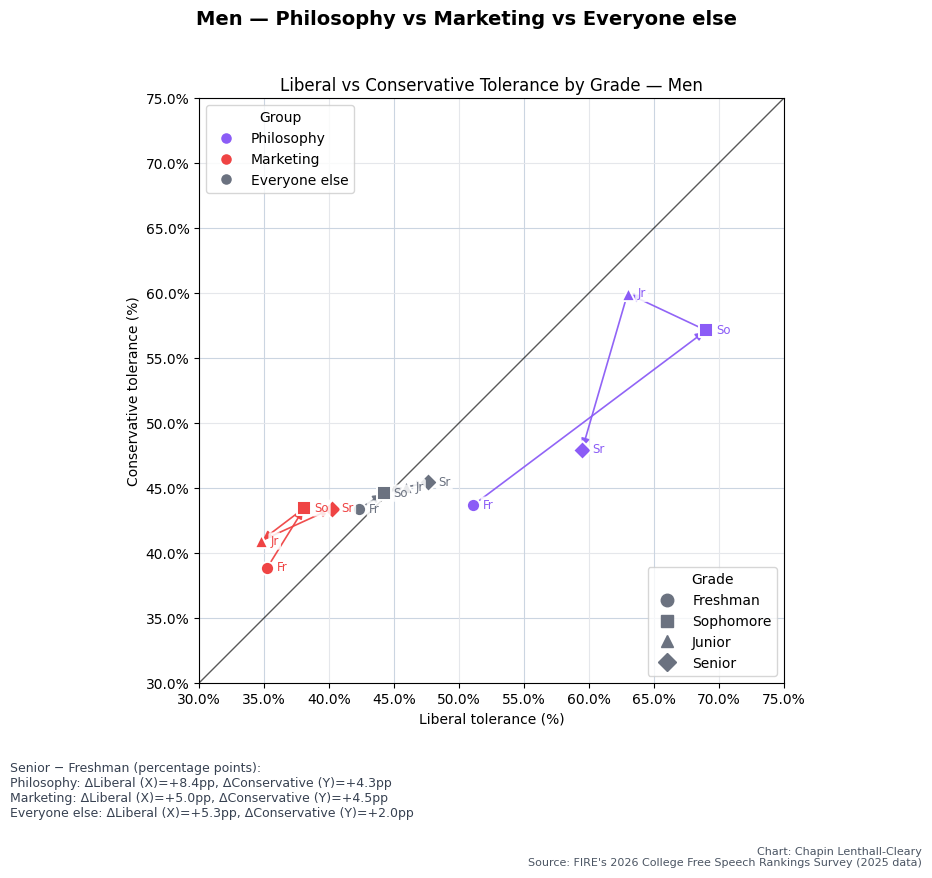

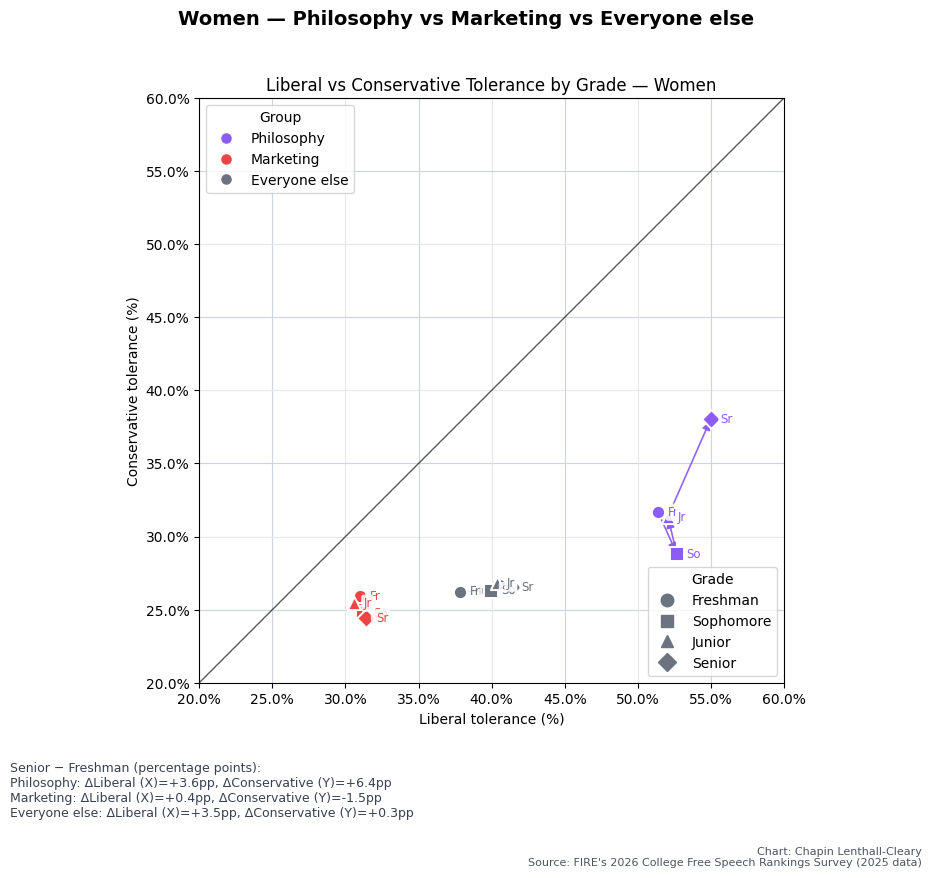

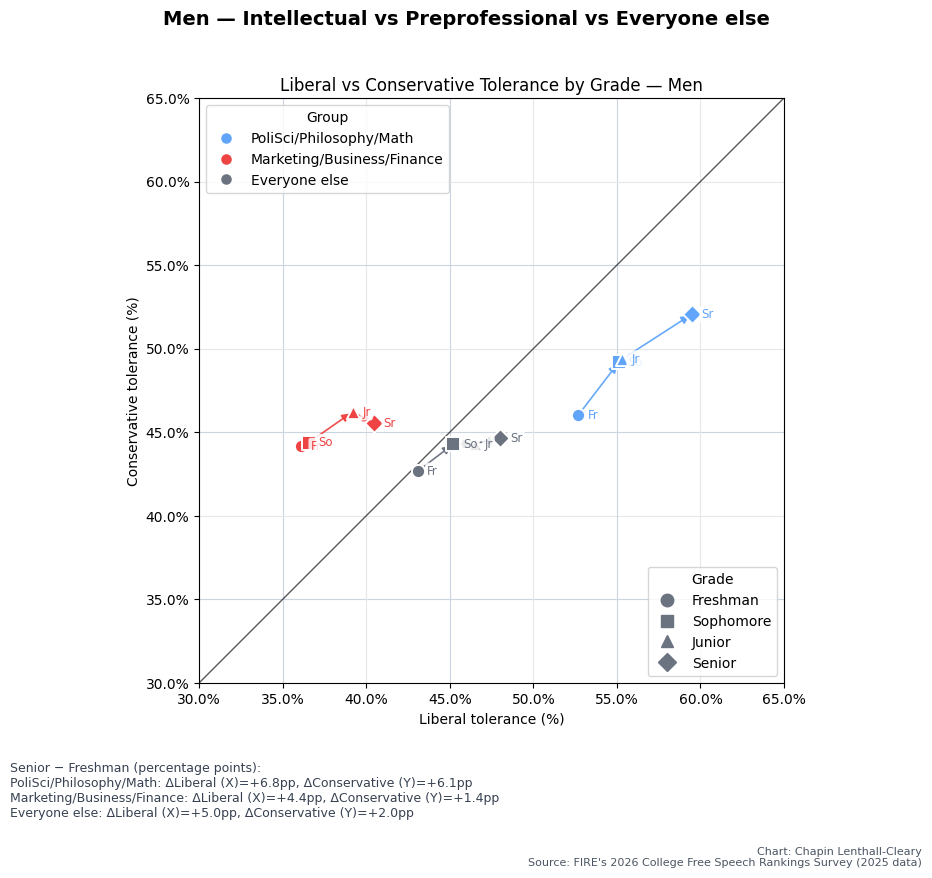

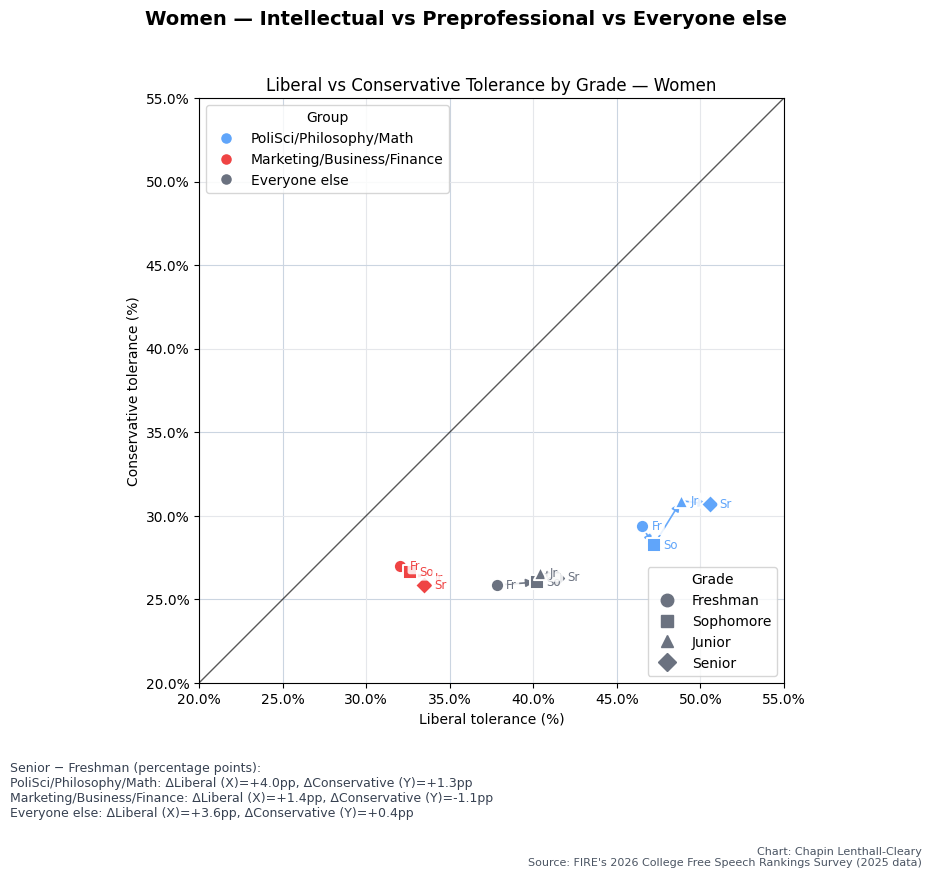

In [23]:
#!/usr/bin/env python3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from matplotlib.patches import FancyArrowPatch
from matplotlib.lines import Line2D
from pathlib import Path

# ========= Config =========
CSV_IN = "cfsr2026.csv"   # must include: gender (1 men, 2 women), grade (0..3), major1/2/3, spk* items below
OUTDIR = "."

# Grade codes (0 Senior, 1 Junior, 2 Sophomore, 3 Freshman) — arrows go 3→2→1→0
GRADE_ORDER   = [3, 2, 1, 0]
GRADE_LABELS  = {3: "Freshman", 2: "Sophomore", 1: "Junior", 0: "Senior"}
GRADE_SHORT   = {3: "Fr",       2: "So",        1: "Jr",     0: "Sr"}
GRADE_MARKERS = {3: "o", 2: "s", 1: "^", 0: "D"}  # marker shape by grade

# Major codes (from your codebook)
MATH_CODE     = 47
BUS_CODE      = 14
PHIL_CODE     = 52
MKTG_CODE     = 46
POLISCI_CODE  = 54
FIN_CODE      = 34
MAJOR_COLS = ["major1", "major2", "major3"]

# === Triads USING cfsr2026 NAMES ===
# Conservative tolerance (y-axis)
RIGHT_TRIAD = ["spkabortion", "spktrans", "spkblm"]
# Liberal tolerance (x-axis)
LEFT_TRIAD  = ["spkchurch", "spkpolice", "spkchildren"]
SPK_ALL = RIGHT_TRIAD + LEFT_TRIAD

# Colors
COLOR_MATH   = "#1f77b4"   # keep
COLOR_BUS    = "#ff7f0e"   # keep
COLOR_ELSE   = "#6b7280"   # keep
COLOR_POLI   = "#60a5fa"   # political science = light blue
COLOR_PHIL   = "#8b5cf6"   # philosophy = purple
COLOR_MKTG   = "#ef4444"   # marketing = red

# Auto-zoom config (per plot)
TICK_STEP = 5
MIN_BUF_PCTPTS = 2.5          # absolute minimum buffer in percentage points
BUF_FRACTION = 0.08           # buffer as fraction of data span (whichever is larger)

# Suptitle + credits
CREDIT_TEXT = (
    "Chart: Chapin Lenthall-Cleary\n"
    "Source: FIRE's 2026 College Free Speech Rankings Survey (2025 data)"
)
SUPTITLE_Y = 0.955
TITLE_PAD  = 5

# Make room at bottom for deltas + credits
TIGHT_RECT = [0.02, 0.16, 0.98, 0.935]
DELTA_X, DELTA_Y = 0.02, 0.075
DELTA_COLOR = "#374151"
DELTA_FONTSIZE = 9

CREDIT_X, CREDIT_Y = 0.98, 0.022
CREDIT_COLOR = "#4b5563"


# ========= Helpers =========
def scale_triad_to_pct(sum_vals, k=3):
    """Map triad sum (k..4k) to 0..100%."""
    return (sum_vals - k) / (3 * k) * 100.0


def majors_set_from_row(row) -> set[int]:
    """Extract a set of major codes from major1/2/3 (ignores NaN)."""
    out = set()
    for c in MAJOR_COLS:
        v = row.get(c)
        if pd.notna(v):
            try:
                out.add(int(v))
            except Exception:
                pass
    return out


def make_assign_group(ordered_groups: list[tuple[str, set[int]]], fallback: str = "Everyone else"):
    """
    ordered_groups: list of (group_name, {major_codes...}) checked in order.
    Returns a function(row) -> group_name.
    If a respondent has multiple majors spanning bins, FIRST match wins.
    """
    def _assign(row) -> str:
        majors = majors_set_from_row(row)
        for name, codes in ordered_groups:
            if majors.intersection(codes):
                return name
        return fallback
    return _assign


def compute_group_grade_means(
    df: pd.DataFrame,
    gender_code: int,
    groups: list[str],
    assign_group_func,
) -> pd.DataFrame:
    """
    Return mean left/right tolerance by (group, grade) for a single gender.
    Columns: ['group','grade','left_pct','right_pct','n']
    """
    g = df[df["gender"] == gender_code].copy()

    # require valid grades and all six spk_* in [1,4]
    g = g.dropna(subset=["grade"])
    g["grade"] = pd.to_numeric(g["grade"], errors="coerce")

    in_range = g[SPK_ALL].ge(1) & g[SPK_ALL].le(4)
    g = g[in_range.all(axis=1)].copy()

    # group label
    g["group"] = g.apply(assign_group_func, axis=1)

    # triad percents
    g["right_sum"] = g[RIGHT_TRIAD].sum(axis=1).astype(int)
    g["left_sum"]  = g[LEFT_TRIAD].sum(axis=1).astype(int)
    g["right_pct"] = scale_triad_to_pct(g["right_sum"], k=len(RIGHT_TRIAD))
    g["left_pct"]  = scale_triad_to_pct(g["left_sum"],  k=len(LEFT_TRIAD))

    # means by (group, grade)
    stats = (g.groupby(["group", "grade"], observed=True)
               .agg(left_pct=("left_pct", "mean"),
                    right_pct=("right_pct", "mean"),
                    n=("left_pct", "size"))
               .reset_index())

    # ensure we have all groups×grades cells (may be NaN if missing)
    idx = pd.MultiIndex.from_product([groups, GRADE_ORDER], names=["group", "grade"])
    stats = stats.set_index(["group", "grade"]).reindex(idx).reset_index()
    return stats


def draw_arrows(ax, xs, ys, color):
    """Draw arrows xs[i]→xs[i+1], ys[i]→ys[i+1] in data coords."""
    for i in range(len(xs) - 1):
        if np.isfinite(xs[i]) and np.isfinite(ys[i]) and np.isfinite(xs[i+1]) and np.isfinite(ys[i+1]):
            ax.add_patch(FancyArrowPatch(
                (xs[i], ys[i]), (xs[i+1], ys[i+1]),
                arrowstyle="-|>", mutation_scale=12, linewidth=1.2, color=color,
                alpha=0.95, zorder=2
            ))


def alternating_grid(ax, lo, hi, step=5):
    """Alternating grid, limited to [lo, hi]."""
    light_gray, medium_gray = "#e5e7eb", "#cbd5e1"
    lo_i, hi_i = int(round(lo)), int(round(hi))
    for v in range(lo_i, hi_i + 1, step):
        idx = ((v - lo_i) // step) % 2
        c = light_gray if idx == 0 else medium_gray
        ax.axhline(v, color=c, linewidth=0.8, zorder=0)
        ax.axvline(v, color=c, linewidth=0.8, zorder=0)


def annotate_grade(ax, x, y, grade_code, color):
    """Cleaner on-plot grade labels (small white pill)."""
    ax.annotate(
        GRADE_SHORT[int(grade_code)],
        (x, y),
        textcoords="offset points",
        xytext=(7, 0),
        ha="left",
        va="center",
        fontsize=8.5,
        color=color,
        bbox=dict(boxstyle="round,pad=0.18,rounding_size=0.2", fc="white", ec="none", alpha=0.85),
        zorder=4
    )


def _round_down(x, step):
    return step * np.floor(x / step)


def _round_up(x, step):
    return step * np.ceil(x / step)


def compute_square_zoom_limits(stats: pd.DataFrame, groups: list[str],
                               min_buf=MIN_BUF_PCTPTS, frac=BUF_FRACTION,
                               step=TICK_STEP):
    """
    Auto-zoom to plotted points + buffer, but force identical x/y limits.
    Returns (lo, hi) in [0,100], rounded to tick step.
    """
    sub = stats[stats["group"].isin(groups)][["left_pct", "right_pct"]].copy()
    sub = sub.dropna()
    if sub.empty:
        return 0.0, 100.0

    xs = sub["left_pct"].to_numpy()
    ys = sub["right_pct"].to_numpy()

    min_val = float(np.nanmin([np.nanmin(xs), np.nanmin(ys)]))
    max_val = float(np.nanmax([np.nanmax(xs), np.nanmax(ys)]))

    span = max_val - min_val
    buf = max(min_buf, frac * span)

    lo = max(0.0, min_val - buf)
    hi = min(100.0, max_val + buf)

    lo = float(_round_down(lo, step))
    hi = float(_round_up(hi, step))

    if hi - lo < step:
        hi = min(100.0, lo + step)

    return lo, hi


def _fmt_pp(x):
    return "n/a" if x is None else f"{x:+.1f}pp"


def format_fr_sr_diffs(stats: pd.DataFrame, groups: list[str]) -> str:
    """
    Per group: Senior − Freshman (percentage points) on X (left_pct) and Y (right_pct).
    """
    lines = ["Senior − Freshman (percentage points):"]
    for group in groups:
        sub = (stats[stats["group"] == group]
               .set_index("grade")[["left_pct", "right_pct"]])

        dx = dy = None
        if 3 in sub.index and 0 in sub.index:
            xf, yf = sub.loc[3, "left_pct"], sub.loc[3, "right_pct"]  # Freshman
            xs, ys = sub.loc[0, "left_pct"], sub.loc[0, "right_pct"]  # Senior

            if pd.notna(xf) and pd.notna(xs):
                dx = float(xs - xf)
            if pd.notna(yf) and pd.notna(ys):
                dy = float(ys - yf)

        lines.append(f"{group}: ΔLiberal (X)={_fmt_pp(dx)}, ΔConservative (Y)={_fmt_pp(dy)}")

    return "\n".join(lines)


def plot_scatter_for_gender(
    stats: pd.DataFrame,
    gender_code: int,
    outpath: Path,
    groups: list[str],
    group_colors: dict[str, str],
    suptitle_text: str,
):
    """
    One gender plot. points = len(groups) × 4 grades.
    Consistent colors per group; group legend top-left; grade legend lower-right.
    Auto-zooms to points+buffer with identical x/y limits and ticks.
    Adds figure suptitle + credits + freshman/senior deltas below plot.
    """
    lo, hi = compute_square_zoom_limits(stats, groups=groups)

    fig, ax = plt.subplots(figsize=(9.5, 9.2))

    # Grid and axes (AUTO-ZOOMED, SQUARE LIMITS)
    alternating_grid(ax, lo=lo, hi=hi, step=TICK_STEP)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal", adjustable="box")

    ticks = list(range(int(round(lo)), int(round(hi)) + 1, TICK_STEP))
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=100))
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))

    # Parity line clipped to zoomed window
    ax.plot([lo, hi], [lo, hi], color="black", linewidth=1, alpha=0.65, zorder=1.5)

    # Titles & labels
    title_gender = "Men" if gender_code == 1 else "Women"
    ax.set_title(f"Liberal vs Conservative Tolerance by Grade — {title_gender}", pad=TITLE_PAD)
    ax.set_xlabel("Liberal tolerance (%)")
    ax.set_ylabel("Conservative tolerance (%)")

    # One series per group
    for group in groups:
        sub = stats[stats["group"] == group].set_index("grade").reindex(GRADE_ORDER)
        xs = sub["left_pct"].to_numpy()
        ys = sub["right_pct"].to_numpy()
        color = group_colors[group]

        # arrows F→So→Jr→Sr
        draw_arrows(ax, xs, ys, color)

        # points + grade markers + clean grade labels
        for g in GRADE_ORDER:
            x, y = sub.loc[g, ["left_pct", "right_pct"]]
            if pd.notna(x) and pd.notna(y):
                ax.scatter(
                    x, y,
                    s=90,
                    marker=GRADE_MARKERS[g],
                    facecolor=color,
                    edgecolor="white",
                    linewidth=1.4,
                    zorder=3
                )
                annotate_grade(ax, x, y, g, color)

    # Legends — group legend TOP-LEFT; grade legend LOWER-RIGHT
    group_handles = [
        Line2D([0], [0], marker="o", linestyle="", color="none",
               markerfacecolor=group_colors[g], markeredgecolor="white",
               markeredgewidth=1.4, markersize=9, label=g)
        for g in groups
    ]
    leg1 = ax.legend(handles=group_handles, title="Group", loc="upper left", frameon=True)
    ax.add_artist(leg1)

    grade_handles = [
        Line2D([0], [0], marker=GRADE_MARKERS[g], linestyle="", color="#6b7280",
               markersize=9, label=GRADE_LABELS[g])
        for g in GRADE_ORDER
    ]
    ax.legend(handles=grade_handles, title="Grade", loc="lower right", frameon=True)

    # Suptitle
    fig.suptitle(suptitle_text, fontsize=14, fontweight="bold", y=SUPTITLE_Y)

    # Freshman vs Senior diffs (below plot)
    delta_text = format_fr_sr_diffs(stats, groups)
    fig.text(
        DELTA_X, DELTA_Y, delta_text,
        ha="left", va="bottom",
        fontsize=DELTA_FONTSIZE,
        color=DELTA_COLOR
    )

    # Credits
    fig.text(
        CREDIT_X, CREDIT_Y, CREDIT_TEXT,
        ha="right", va="bottom", fontsize=8, color=CREDIT_COLOR
    )

    fig.tight_layout(rect=TIGHT_RECT)
    outpath = Path(outpath)
    fig.savefig(outpath, dpi=150)
    plt.show()
    plt.close(fig)


def main():
    df = pd.read_csv(CSV_IN, low_memory=False)

    # Ensure required columns exist
    required = {"gender", "grade", *MAJOR_COLS, *SPK_ALL}
    missing = required - set(df.columns)
    if missing:
        raise SystemExit(f"Missing columns in {CSV_IN}: {sorted(missing)}")

    # Coerce needed cols
    for c in ["gender", "grade", *MAJOR_COLS, *SPK_ALL]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # Keep men/women only
    df = df[df["gender"].isin([1, 2])].copy()
    if df.empty:
        raise SystemExit("No rows with gender in [1,2].")

    outdir = Path(OUTDIR)
    outdir.mkdir(parents=True, exist_ok=True)

    # =========================================================
    # KEEP ONLY THE LAST 4 PLOTS:
    #   Set B (Men/Women) + Set C (Men/Women)
    # =========================================================

    # =========================================================
    # PLOT SET B: Philosophy, Marketing, Everyone else
    # =========================================================
    GROUPS_B = ["Philosophy", "Marketing", "Everyone else"]
    GROUP_COLORS_B = {
        "Philosophy": COLOR_PHIL,
        "Marketing": COLOR_MKTG,
        "Everyone else": COLOR_ELSE,
    }
    assign_B = make_assign_group([
        ("Philosophy", {PHIL_CODE}),
        ("Marketing", {MKTG_CODE}),
    ], fallback="Everyone else")

    statsB_m = compute_group_grade_means(df, gender_code=1, groups=GROUPS_B, assign_group_func=assign_B)
    statsB_w = compute_group_grade_means(df, gender_code=2, groups=GROUPS_B, assign_group_func=assign_B)

    plot_scatter_for_gender(
        statsB_m, 1, outdir / "scatter_lr_by_grade_men_phil_marketing.png",
        groups=GROUPS_B, group_colors=GROUP_COLORS_B,
        suptitle_text="Men — Philosophy vs Marketing vs Everyone else"
    )
    plot_scatter_for_gender(
        statsB_w, 2, outdir / "scatter_lr_by_grade_women_phil_marketing.png",
        groups=GROUPS_B, group_colors=GROUP_COLORS_B,
        suptitle_text="Women — Philosophy vs Marketing vs Everyone else"
    )

    # =========================================================
    # PLOT SET C: bin (Political Science + Philosophy + Math)
    #        vs (Marketing + Business + Finance) vs Everyone else
    # Colors: Poli/Phil/Math = light blue; Mktg/Bus/Fin = red; Everyone else = gray
    # =========================================================
    GROUPS_C = ["PoliSci/Philosophy/Math", "Marketing/Business/Finance", "Everyone else"]
    GROUP_COLORS_C = {
        "PoliSci/Philosophy/Math": COLOR_POLI,
        "Marketing/Business/Finance": COLOR_MKTG,  # red
        "Everyone else": COLOR_ELSE,
    }
    assign_C = make_assign_group([
        ("PoliSci/Philosophy/Math", {POLISCI_CODE, PHIL_CODE, MATH_CODE}),
        ("Marketing/Business/Finance", {MKTG_CODE, BUS_CODE, FIN_CODE}),
    ], fallback="Everyone else")

    statsC_m = compute_group_grade_means(df, gender_code=1, groups=GROUPS_C, assign_group_func=assign_C)
    statsC_w = compute_group_grade_means(df, gender_code=2, groups=GROUPS_C, assign_group_func=assign_C)

    plot_scatter_for_gender(
        statsC_m, 1, outdir / "scatter_lr_by_grade_men_bins_ps_phil_math_vs_mktg_bus_fin.png",
        groups=GROUPS_C, group_colors=GROUP_COLORS_C,
        suptitle_text="Men — Intellectual vs Preprofessional vs Everyone else"
    )
    plot_scatter_for_gender(
        statsC_w, 2, outdir / "scatter_lr_by_grade_women_bins_ps_phil_math_vs_mktg_bus_fin.png",
        groups=GROUPS_C, group_colors=GROUP_COLORS_C,
        suptitle_text="Women — Intellectual vs Preprofessional vs Everyone else"
    )


if __name__ == "__main__":
    main()


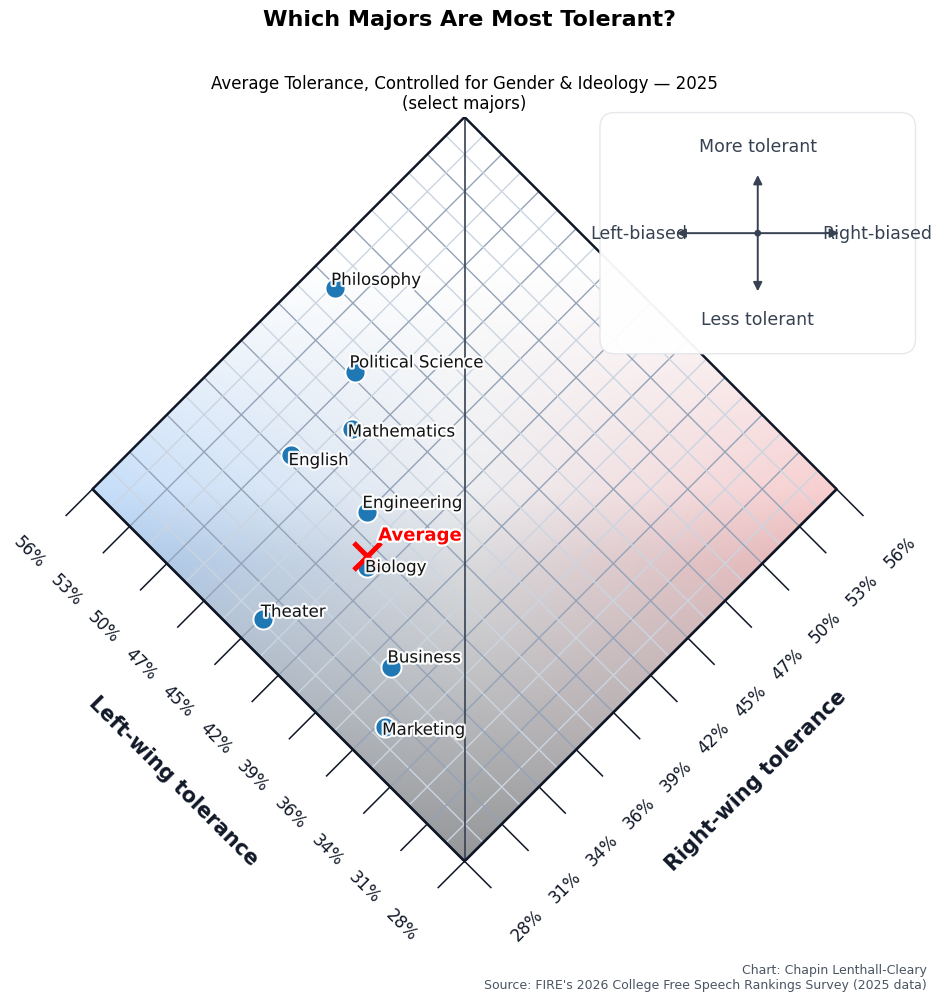

Saved: /Users/chapin.lenthall-cleary/diamond_major_left_vs_right_mfavg_ideoFE_all.png


In [41]:
#!/usr/bin/env python3
"""
ONE-PLOT script: Major-level DIAMOND scatter (Code-2 style) for Plot 2 only.

Edits in this version (per your request):
- Includes ONLY: Philosophy, Political Science, Mathematics, Marketing, Business, English,
  Biology (was Biological Sciences), Engineering (was Engineering Sciences), Theater.
- Removes Computer Science.
- Makes dots bigger and major labels bigger.
- Makes subtitle line say: (select majors)

Run:
  python3 diamond_major_plot.py
"""

from pathlib import Path
from typing import Optional, Callable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

from matplotlib.colors import to_rgb
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch, Circle, Polygon

# --- adjustText (optional) ---
try:
    from adjustText import adjust_text
    HAS_ADJUSTTEXT = True
except ImportError:
    HAS_ADJUSTTEXT = False


# =========================
# Config
# =========================
CSV_PATH = Path("cfsr2026.csv")

MAJOR_COLS = ["major1", "major2", "major3"]
GENDER_COL = "gender"     # 1 = men, 2 = women
IDEO_COL = "ideo"

YEAR_COL = "datayear"
YEAR = 2025  # set to None to disable

MIN_MEN = 100
MIN_WOMEN = 100

# Triads using Code 1 column names
RIGHT_TRIAD = ["spkabortion", "spktrans", "spkblm"]
LEFT_TRIAD  = ["spkchurch", "spkpolice", "spkchildren"]
SPK_LR = RIGHT_TRIAD + LEFT_TRIAD

CLIP_0_100_AFTER_ADJ = True

# Figure / labels
FIG_W, FIG_H = 8.8 * 1.3, 8.6 * 1.3

# Bigger labels (point labels)
LABEL_FONTSIZE = 12.0
LABEL_ALPHA = 0.92

# Bigger dots / markers
POINT_SIZE = 210
AVG_MARKER_SIZE = 380

# Zoom buffer for diamond scaling
BUFFER_PP_MIN = 1.5
BUFFER_FRAC = 0.06

# Titles / credits
CREDIT_TEXT = (
    "Chart: Chapin Lenthall-Cleary\n"
    "Source: FIRE's 2026 College Free Speech Rankings Survey (2025 data)"
)
SUPTITLE_Y = 0.958
TITLE_PAD = 6
CREDIT_X, CREDIT_Y = 0.9, 0.08
CREDIT_COLOR = "#4b5563"

# Compass placement (push further right by increasing SHIFT_RIGHT)
COMPASS_W = 0.40
COMPASS_H = 0.30
COMPASS_PAD = 0.006
COMPASS_SHIFT_RIGHT = 0.10  # increase to move further RIGHT (can extend past x=1)

# ---- major codebook (as provided) ----
MAJOR_MAP = {
    1: "Accounting",
    2: "African/Afr-American Studies",
    3: "Agricultural/Food Sciences",
    4: "Animal Science",
    5: "Anthropology",
    6: "Archaeology",
    7: "Architecture",
    8: "Art History",
    9: "Asian/Mideast Lang & Lit",
    10: "Asian/Mideast Studies",
    11: "Physics and Astronomy",
    12: "Biochemistry and Molecular Biology",
    13: "Biological Sciences",
    14: "Business",
    15: "Chemistry",
    16: "Classics",
    17: "Cognitive Science",
    18: "Communication",
    19: "Computer Science",
    20: "Dance",
    21: "Data Science",
    22: "Development Studies",
    23: "Digital Media Design",
    24: "Earth Sciences",
    25: "Economics",
    26: "Education",
    27: "Engineering Sciences",
    28: "English",
    29: "Environmental Studies",
    30: "Ethnicity and Race Studies",
    31: "European Cultural Studies",
    32: "Fashion",
    33: "Film and Media Studies",
    34: "Finance",
    35: "Fine Arts",
    36: "French and Italian",
    37: "Geography",
    38: "German Studies",
    39: "History",
    40: "Hotel Administration",
    41: "International Relations",
    42: "Jewish Studies",
    43: "Lat Am/Latino/Carib Studies",
    44: "Law/Criminology",
    45: "Linguistics",
    46: "Marketing",
    47: "Mathematics",
    48: "Music",
    50: "Neuroscience",
    51: "Nursing",
    52: "Philosophy",
    53: "Physical Education",
    54: "Political Science",
    55: "Portuguese and Brazilian Studies",
    56: "Pre-Medical",
    57: "Psychological and Brain Sciences",
    58: "Public Health",
    59: "Public Policy",
    61: "Real Estate",
    62: "Religion",
    63: "Robotics and Intelligent Systems",
    65: "Sociology",
    66: "Spanish and Portuguese",
    67: "Statistics",
    68: "Studio Art",
    69: "Theater",
    70: "Undecided",
    71: "Urban Studies",
    72: "Visual Arts",
    73: "Women's and Gender Studies",
    74: "other",
}
EXCLUDE_MAJOR_CODES = {98, 99}

# Label overrides (your request)
MAJOR_LABEL_OVERRIDES = {
    13: "Biology",
    27: "Engineering",
}

# ONLY include these majors (your updated list)
INCLUDE_MAJOR_CODES = {
    52,  # Philosophy
    54,  # Political Science
    47,  # Mathematics
    46,  # Marketing
    14,  # Business
    28,  # English
    13,  # Biology (Biological Sciences)
    27,  # Engineering (Engineering Sciences)
    69,  # Theater
}


# =========================
# Helpers: scoring + adjustment + reshape
# =========================
def scale_triad_to_pct(sum_vals: pd.Series, k: int) -> pd.Series:
    """Maps triad sum (k..4k) to 0..100%."""
    return (sum_vals - k) / (3 * k) * 100.0


def filter_ideology(df: pd.DataFrame, keep_codes: set[int]) -> pd.DataFrame:
    if IDEO_COL not in df.columns:
        raise ValueError(f"Missing required column '{IDEO_COL}'.")
    df = df.copy()
    df[IDEO_COL] = pd.to_numeric(df[IDEO_COL], errors="coerce")
    return df[df[IDEO_COL].isin(keep_codes)].copy()


def residualize_categorical_fe(
    df: pd.DataFrame,
    value_cols: list[str],
    *,
    ideo_col: str = IDEO_COL,
    suffix: str = "_ideoadj",
    clip_0_100: bool = True
) -> pd.DataFrame:
    """
    Ideology FE:
      y_adj = y - mean(y | ideo) + mean(y)
    """
    df = df.copy()
    for col in value_cols:
        y = pd.to_numeric(df[col], errors="coerce")
        overall_mean = float(np.nanmean(y))

        means_by_ideo = (
            pd.DataFrame({ideo_col: df[ideo_col], col: y})
            .dropna(subset=[ideo_col, col])
            .groupby(ideo_col)[col]
            .mean()
        )

        adj = y - df[ideo_col].map(means_by_ideo) + overall_mean
        if clip_0_100:
            adj = np.clip(adj, 0, 100)
        df[col + suffix] = pd.to_numeric(adj, errors="coerce").round(1)
    return df


def build_major_long(df: pd.DataFrame, id_vars: list) -> pd.DataFrame:
    """Melt majors long, filter valid codes, de-dupe per person/major."""
    df = df.copy()
    if "respondent_id" not in df.columns:
        df = df.reset_index().rename(columns={"index": "respondent_id"})

    for col in MAJOR_COLS:
        if col not in df.columns:
            raise ValueError(f"Missing required column '{col}'.")
        df[col] = pd.to_numeric(df[col], errors="coerce")

    valid_codes = set(MAJOR_MAP.keys()) - EXCLUDE_MAJOR_CODES

    long = (
        df.melt(
            id_vars=id_vars,
            value_vars=MAJOR_COLS,
            var_name="major_slot",
            value_name="major_code",
        )
        .dropna(subset=["major_code"])
        .copy()
    )
    long["major_code"] = pd.to_numeric(long["major_code"], errors="coerce").astype("Int64")
    long = long[long["major_code"].isin(valid_codes)].copy()

    return long.drop_duplicates(subset=["respondent_id", "major_code"])


def pivot_gender_means(agg: pd.DataFrame, value_cols: list) -> pd.DataFrame:
    """Wide male_*/female_* plus male_n/female_n."""
    piv_vals = agg.pivot(index="major_code", columns=GENDER_COL, values=value_cols)
    piv_n = agg.pivot(index="major_code", columns=GENDER_COL, values=["n"])

    def rename_cols(cols):
        out = []
        for metric, gender in cols:
            sex = "male" if int(gender) == 1 else "female"
            out.append(f"{sex}_{metric}")
        return out

    piv_vals.columns = rename_cols(piv_vals.columns)
    piv_n.columns = rename_cols(piv_n.columns)

    return pd.concat([piv_vals, piv_n], axis=1).reset_index()


def filter_min_counts(df_wide: pd.DataFrame) -> pd.DataFrame:
    df_wide = df_wide.copy()
    df_wide["male_n"] = pd.to_numeric(df_wide.get("male_n"), errors="coerce")
    df_wide["female_n"] = pd.to_numeric(df_wide.get("female_n"), errors="coerce")
    keep = (df_wide["male_n"] >= MIN_MEN) & (df_wide["female_n"] >= MIN_WOMEN)
    out = df_wide.loc[keep].copy()
    out["total_n"] = out["male_n"] + out["female_n"]
    return out


def label_points(ax, df_points: pd.DataFrame, xcol: str, ycol: str, label_col: str):
    """Label every point; repel with adjustText if available."""
    if label_col not in df_points.columns:
        return

    stroke = [pe.withStroke(linewidth=3.2, foreground="white")]  # slightly thicker halo

    if not HAS_ADJUSTTEXT:
        offsets = [(4, 4), (4, -6), (-6, 4), (-6, -6), (6, 0), (0, 6), (-8, 0), (0, -8)]
        for i, (_, r) in enumerate(df_points.iterrows()):
            dx, dy = offsets[i % len(offsets)]
            ax.annotate(
                str(r[label_col]),
                (float(r[xcol]), float(r[ycol])),
                textcoords="offset points",
                xytext=(dx, dy),
                ha="left" if dx >= 0 else "right",
                va="bottom" if dy >= 0 else "top",
                fontsize=LABEL_FONTSIZE,
                alpha=LABEL_ALPHA,
                zorder=10,
                path_effects=stroke
            )
        return

    texts = []
    for _, r in df_points.iterrows():
        t = ax.text(
            float(r[xcol]), float(r[ycol]), str(r[label_col]),
            fontsize=LABEL_FONTSIZE, alpha=LABEL_ALPHA, zorder=10,
            path_effects=stroke
        )
        texts.append(t)

    adjust_text(
        texts,
        ax=ax,
        expand_points=(1.25, 1.35),
        expand_text=(1.10, 1.25),
        force_points=0.10,
        force_text=0.35,
        lim=250,
        arrowprops=dict(arrowstyle="-", lw=0.6, color="0.45", alpha=0.65),
    )


# =========================
# Diamond plotting (Code-2 style) with zoom-by-rescale
# =========================
P0 = np.array([50.0, 0.0])       # bottom vertex
VL = np.array([-50.0, 50.0])     # toward left vertex
VR = np.array([ 50.0, 50.0])     # toward right vertex


def to_diamond_xy(L, R):
    """Vectorized map (L,R) in [0..100]^2 -> (x,y) in diamond coords."""
    L = np.asarray(L, dtype=float)
    R = np.asarray(R, dtype=float)
    sL, sR = L / 100.0, R / 100.0
    xy = P0 + sL[..., None] * VL + sR[..., None] * VR
    return xy[..., 0], xy[..., 1]


def _add_2d_gradient_bg(ax, diamond_outline, *, nx=900, ny=900):
    """2D gradient background clipped to diamond."""
    x = np.linspace(0.0, 1.0, nx)
    y = np.linspace(0.0, 1.0, ny)
    X, Y = np.meshgrid(x, y)

    c_left  = np.array(to_rgb("#93c5fd"))  # blue-300
    c_mid   = np.array(to_rgb("#e5e7eb"))  # gray-200
    c_right = np.array(to_rgb("#fca5a5"))  # red-300

    H = np.zeros((ny, nx, 3), dtype=float)
    uL = np.clip(2 * X, 0, 1)
    uR = np.clip(2 * (X - 0.5), 0, 1)
    for ch in range(3):
        H[..., ch] = np.where(
            X <= 0.5,
            (1 - uL) * c_left[ch] + uL * c_mid[ch],
            (1 - uR) * c_mid[ch]  + uR * c_right[ch]
        )

    white = np.array(to_rgb("#ffffff"))
    gray  = np.array(to_rgb("#e5e7eb"))
    t = np.clip(Y / 0.80, 0, 1)
    V = (1 - t)[..., None] * gray + t[..., None] * white

    bell = 1.0 - np.abs(2 * t - 1.0)
    alpha = 0.65 * bell
    IMG = (1 - alpha)[..., None] * V + alpha[..., None] * H

    bottom_cutoff = 0.5
    shade_strength = np.clip((bottom_cutoff - Y) / bottom_cutoff, 0.0, 1.0)
    max_darken = 0.35
    IMG *= (1.0 - max_darken * shade_strength[..., None])

    IMG = np.clip(IMG, 0.0, 1.0)
    IMG[Y >= 0.85] = white

    im = ax.imshow(
        IMG, origin="lower",
        extent=[0, 100, 0, 100],
        interpolation="bilinear",
        zorder=-10
    )
    im.set_clip_path(diamond_outline)


def add_compass(ax, *, width, height, pad, shift_right,
                directions_deg=(90, 180, 0, 270),
                labels=("More tolerant", "Left-biased", "Right-biased", "Less tolerant")):
    """Compass box in axes coords, pushed right by shift_right."""
    cx = 1 - pad - width / 2 + shift_right
    cy = 1 - pad - height / 2

    compass_box = FancyBboxPatch(
        (cx - width/2, cy - height/2), width, height,
        transform=ax.transAxes,
        boxstyle="round,pad=0.012,rounding_size=0.02",
        linewidth=1.0, facecolor="white", edgecolor="#e5e7eb",
        alpha=0.96, zorder=20
    )
    compass_box.set_clip_on(False)
    ax.add_patch(compass_box)

    hx, hy = width / 2.0, height / 2.0
    m = min(width, height) * 0.06

    def r_max(theta):
        ct, st = abs(np.cos(theta)), abs(np.sin(theta))
        ct = max(ct, 1e-9); st = max(st, 1e-9)
        return min((hx - m) / ct, (hy - m) / st)

    color = "#374151"
    lw = 1.4
    ms = 13
    fz = 12.5  # bigger compass labels

    for angle_deg, label in zip(directions_deg, labels):
        th = np.deg2rad(angle_deg)
        rmax = r_max(th)
        r_arrow = rmax * 0.62
        r_label = rmax * 0.88

        x_tip = cx + r_arrow * np.cos(th)
        y_tip = cy + r_arrow * np.sin(th)

        arr = FancyArrowPatch(
            (cx, cy), (x_tip, y_tip),
            transform=ax.transAxes, arrowstyle="-|>",
            mutation_scale=ms, linewidth=lw,
            color=color, zorder=21
        )
        arr.set_clip_on(False)
        ax.add_patch(arr)

        txt = ax.text(
            cx + r_label*np.cos(th), cy + r_label*np.sin(th),
            label, transform=ax.transAxes,
            ha="center", va="center",
            fontsize=fz, color=color, zorder=22
        )
        txt.set_clip_on(False)

    center = Circle(
        (cx, cy), radius=min(width, height) * 0.012,
        transform=ax.transAxes, color=color, zorder=22
    )
    center.set_clip_on(False)
    ax.add_patch(center)


def _draw_edge_axis(ax, p0, p1, *, label,
                    tick_vals=range(0, 101, 10),
                    tick_len=5.0, label_pad=20.0, tick_label_pad=7.0,
                    label_fontsize=15, tick_fontsize=12,  # bigger axis labels + tick labels
                    color="#111827", increasing_from="start",
                    tick_label_func: Optional[Callable[[int], str]] = None):
    """Oblique axis with ticks/labels along a diamond edge."""
    p0 = np.asarray(p0, float); p1 = np.asarray(p1, float)
    v = p1 - p0
    L = float(np.hypot(v[0], v[1]))
    if L == 0:
        return
    u = v / L

    # outward normal pointing "below"
    n_cw  = np.array([ u[1], -u[0]])
    n_ccw = np.array([-u[1],  u[0]])
    n = n_cw if n_cw[1] < n_ccw[1] else n_ccw

    ax.plot([p0[0], p1[0]], [p0[1], p1[1]], color=color, linewidth=1.6, zorder=4, clip_on=False)
    edge_angle_deg = np.degrees(np.arctan2(v[1], v[0]))

    for t in tick_vals:
        s = t / 100.0
        pt = (p1 - u*(s*L)) if (increasing_from == "end") else (p0 + u*(s*L))

        p_tick_end = pt + n * tick_len
        ax.plot([pt[0], p_tick_end[0]], [pt[1], p_tick_end[1]],
                color=color, linewidth=1.1, zorder=4, clip_on=False)

        p_text = pt + n * (tick_len + tick_label_pad)
        tick_txt = tick_label_func(t) if tick_label_func else f"{t}%"
        ax.text(p_text[0], p_text[1], tick_txt,
                ha="center", va="center",
                fontsize=tick_fontsize, color=color,
                rotation=edge_angle_deg, rotation_mode="anchor",
                zorder=5, clip_on=False)

    mid = (p0 + p1) / 2.0
    p_label = mid + n * label_pad
    ax.text(p_label[0], p_label[1], label,
            ha="center", va="center",
            fontsize=label_fontsize, color=color, fontweight="bold",
            rotation=edge_angle_deg, rotation_mode="anchor",
            zorder=5, clip_on=False)


def _compute_zoom_range(left_vals: pd.Series, right_vals: pd.Series):
    """Shared [lo, hi] range in ORIGINAL % units with buffer."""
    L = pd.to_numeric(left_vals, errors="coerce").dropna()
    R = pd.to_numeric(right_vals, errors="coerce").dropna()
    if L.empty or R.empty:
        return (0.0, 100.0)

    minv = float(min(L.min(), R.min()))
    maxv = float(max(L.max(), R.max()))
    span = max(1e-6, maxv - minv)

    buffer = max(BUFFER_PP_MIN, BUFFER_FRAC * span)
    lo = max(0.0, minv - buffer)
    hi = min(100.0, maxv + buffer)

    if hi - lo < 5:
        mid = (hi + lo) / 2.0
        lo = max(0.0, mid - 2.5)
        hi = min(100.0, mid + 2.5)

    return (lo, hi)


def scatter_major_plot_diamond(
    df_points: pd.DataFrame,
    x: str,  # mf_left (0..100)
    y: str,  # mf_right (0..100)
    out_path: Path,
    *,
    suptitle_text: str,
    title: str,
    left_edge_label: str,
    right_edge_label: str,
    weights: str,
    label_col: str = "major",
    credit_text: str = CREDIT_TEXT,
):
    """
    Diamond chart with zoom-by-rescale:
    - Compute lo..hi from data (plus buffer).
    - Normalize values into 0..100 for plotting, but show tick labels in true %.
    """
    pts = df_points.copy()
    pts[x] = pd.to_numeric(pts[x], errors="coerce")
    pts[y] = pd.to_numeric(pts[y], errors="coerce")
    pts = pts.dropna(subset=[x, y])
    if pts.empty:
        raise ValueError("No points to plot after dropping NA values.")

    lo, hi = _compute_zoom_range(pts[x], pts[y])
    denom = max(1e-9, hi - lo)

    Lnorm = np.clip((pts[x].to_numpy() - lo) / denom * 100.0, 0, 100)
    Rnorm = np.clip((pts[y].to_numpy() - lo) / denom * 100.0, 0, 100)
    Xd, Yd = to_diamond_xy(Lnorm, Rnorm)

    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

    # Diamond outline
    diamond_xy = np.array([[50, 100], [100, 50], [50, 0], [0, 50]], dtype=float)
    diamond_outline = Polygon(
        diamond_xy, closed=True, facecolor="none",
        edgecolor="#111827", linewidth=1.8, zorder=3, joinstyle="miter"
    )
    ax.add_patch(diamond_outline)

    # Background
    _add_2d_gradient_bg(ax, diamond_outline)

    # Diamond grid
    grid_artists = []
    light_line = "#cbd5e1"
    heavy_line = "#94a3b8"
    for v in range(0, 101, 5):
        color = heavy_line if (v // 5) % 2 == 0 else light_line

        x1, y1 = to_diamond_xy(v, 0)
        x2, y2 = to_diamond_xy(v, 100)
        ln1, = ax.plot([x1, x2], [y1, y2], color=color, linewidth=1.0, zorder=0)
        grid_artists.append(ln1)

        x3, y3 = to_diamond_xy(0, v)
        x4, y4 = to_diamond_xy(100, v)
        ln2, = ax.plot([x3, x4], [y3, y4], color=color, linewidth=1.0, zorder=0)
        grid_artists.append(ln2)

    # Points (bigger)
    sc = ax.scatter(
        Xd, Yd, s=POINT_SIZE,
        edgecolor="white", linewidth=1.4,
        zorder=6
    )

    # Weighted average in ORIGINAL units, then normalized for plotting
    w = pd.to_numeric(pts.get(weights), errors="coerce")
    mx = pts[x].notna() & w.notna() & (w > 0)
    my = pts[y].notna() & w.notna() & (w > 0)
    avg_artist = None
    if mx.any() and my.any():
        x_avg = float(np.average(pts.loc[mx, x], weights=w.loc[mx]))
        y_avg = float(np.average(pts.loc[my, y], weights=w.loc[my]))
        x_avg_n = np.clip((x_avg - lo) / denom * 100.0, 0, 100)
        y_avg_n = np.clip((y_avg - lo) / denom * 100.0, 0, 100)
        axx, ayy = to_diamond_xy(x_avg_n, y_avg_n)
        avg_artist = ax.scatter([axx], [ayy], marker="x", s=AVG_MARKER_SIZE,
                                linewidths=3.6, color="red", zorder=8)
        ax.annotate(
            "Average",
            (axx, ayy),
            textcoords="offset points",
            xytext=(8, 8),
            ha="left", va="bottom",
            fontsize=LABEL_FONTSIZE + 1,
            fontweight="bold",
            color="red",
            zorder=9,
            path_effects=[pe.withStroke(linewidth=3.2, foreground="white")]
        )

    # Parity line (L=R) in normalized space
    x0, y0 = to_diamond_xy(0, 0)
    xT, yT = to_diamond_xy(100, 100)
    parity_line, = ax.plot([x0, xT], [y0, yT],
                           color="#374151", linewidth=1.2, alpha=1.0, zorder=2)

    # Clip core artists
    clip_list = grid_artists + [parity_line, sc]
    if avg_artist is not None:
        clip_list.append(avg_artist)
    for art in clip_list:
        art.set_clip_path(diamond_outline)

    # Remove default axes
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlim(0, 100); ax.set_ylim(0, 100)
    ax.set_aspect("equal", adjustable="box")

    # Compass (pushed further right)
    add_compass(
        ax,
        width=COMPASS_W, height=COMPASS_H,
        pad=COMPASS_PAD,
        shift_right=COMPASS_SHIFT_RIGHT
    )

    # Tick labels show TRUE % values from [lo..hi]
    def tick_label_func(t: int) -> str:
        val = lo + (t / 100.0) * (hi - lo)
        return f"{int(round(val))}%"

    _draw_edge_axis(
        ax, (0, 50), (50, 0),
        label=left_edge_label,
        increasing_from="end",
        tick_label_func=tick_label_func
    )
    _draw_edge_axis(
        ax, (50, 0), (100, 50),
        label=right_edge_label,
        tick_label_func=tick_label_func
    )

    # Labels
    pts_for_labels = pts.copy()
    pts_for_labels["_xd"] = Xd
    pts_for_labels["_yd"] = Yd
    label_points(ax, pts_for_labels, "_xd", "_yd", label_col)

    # Titles / credits
    ax.set_title(title, pad=TITLE_PAD)
    fig.suptitle(suptitle_text, fontsize=16, fontweight="bold", y=SUPTITLE_Y)
    fig.text(CREDIT_X, CREDIT_Y, credit_text, ha="right", va="bottom",
             fontsize=9, color=CREDIT_COLOR)

    # Extra room (bottom for diagonal axis labels). Use bbox_inches='tight' to keep compass.
    fig.tight_layout(rect=[0.02, 0.10, 0.98, 0.945])
    fig.savefig(out_path, dpi=220, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path.resolve()}")


# =========================
# Pipeline: compute majors + diamond plot
# =========================
def run_diamond_major_plot(
    df_base: pd.DataFrame,
    *,
    set_tag: str,
    set_desc: str,
    ideo_keep: set[int],
    residualize_fn: Callable[[pd.DataFrame, list[str]], pd.DataFrame],
):
    df = filter_ideology(df_base, keep_codes=ideo_keep)
    if df.empty:
        raise SystemExit(f"[{set_tag}] No rows after ideology filter.")

    # Numeric + in-range filter for triads
    df2 = df.copy()
    for c in SPK_LR:
        if c not in df2.columns:
            raise ValueError(f"Missing required column '{c}' for left/right triads.")
        df2[c] = pd.to_numeric(df2[c], errors="coerce")

    in_range = df2[SPK_LR].ge(1) & df2[SPK_LR].le(4)
    df2 = df2[in_range.all(axis=1)].copy()
    if df2.empty:
        raise SystemExit(f"[{set_tag}] No rows remain after requiring all six spk* in [1,4].")

    df2["right_sum"] = df2[RIGHT_TRIAD].sum(axis=1)
    df2["left_sum"] = df2[LEFT_TRIAD].sum(axis=1)
    df2["right_pct"] = scale_triad_to_pct(df2["right_sum"], k=len(RIGHT_TRIAD))
    df2["left_pct"] = scale_triad_to_pct(df2["left_sum"],  k=len(LEFT_TRIAD))

    df2 = residualize_fn(df2, ["left_pct", "right_pct"])

    # Major reshape + aggregation
    long2 = build_major_long(
        df2,
        id_vars=["respondent_id", GENDER_COL, "left_pct_ideoadj", "right_pct_ideoadj"]
    )

    agg2 = (
        long2.groupby(["major_code", GENDER_COL], as_index=False)
        .agg(
            left_avg=("left_pct_ideoadj", "mean"),
            right_avg=("right_pct_ideoadj", "mean"),
            n=("respondent_id", "nunique")
        )
    )

    wide2 = pivot_gender_means(agg2, ["left_avg", "right_avg"])

    # Major labels (with requested overrides)
    wide2["major"] = wide2["major_code"].map(MAJOR_MAP)
    wide2["major"] = wide2.apply(
        lambda r: MAJOR_LABEL_OVERRIDES.get(int(r["major_code"]), r["major"]),
        axis=1
    )

    wide2 = filter_min_counts(wide2)

    # Keep ONLY the requested majors
    wide2 = wide2[wide2["major_code"].isin(INCLUDE_MAJOR_CODES)].copy()

    # Men+women average per major
    wide2["mf_left"] = wide2[["male_left_avg", "female_left_avg"]].mean(axis=1, skipna=True)
    wide2["mf_right"] = wide2[["male_right_avg", "female_right_avg"]].mean(axis=1, skipna=True)

    for c in ["mf_left", "mf_right"]:
        wide2[c] = pd.to_numeric(wide2[c], errors="coerce").round(1)

    if wide2.empty:
        raise SystemExit(
            f"[{set_tag}] No majors remain after min-count filter (>= {MIN_MEN}/{MIN_WOMEN}) "
            f"and INCLUDE_MAJOR_CODES filter."
        )

    out_path = Path(f"diamond_major_left_vs_right_mfavg_{set_tag}.png")

    scatter_major_plot_diamond(
        df_points=wide2,
        x="mf_left",
        y="mf_right",
        out_path=out_path,
        suptitle_text="Which Majors Are Most Tolerant?",
        title=f"Average Tolerance, Controlled for Gender & Ideology"
              f"{'' if YEAR is None else f' — {YEAR}'}\n(select majors)",
        left_edge_label="Left-wing tolerance",
        right_edge_label="Right-wing tolerance",
        weights="total_n",
        label_col="major",
    )


def main():
    # Toggle ideology-control approach
    RUN_DUMMY_FE_ALL = True
    RUN_LINEAR_1TO7 = False  # left here if you want to add linear later

    df0 = pd.read_csv(CSV_PATH, low_memory=False)

    if YEAR is not None and YEAR_COL in df0.columns:
        df0[YEAR_COL] = pd.to_numeric(df0[YEAR_COL], errors="coerce")
        df0 = df0[df0[YEAR_COL] == YEAR].copy()

    df0[GENDER_COL] = pd.to_numeric(df0[GENDER_COL], errors="coerce")
    df0 = df0[df0[GENDER_COL].isin([1, 2])].copy()
    if df0.empty:
        raise SystemExit("No rows after filtering to men/women (gender in [1,2]).")

    if IDEO_COL not in df0.columns:
        raise SystemExit(f"Missing required ideology column '{IDEO_COL}'.")
    df0[IDEO_COL] = pd.to_numeric(df0[IDEO_COL], errors="coerce")

    if RUN_DUMMY_FE_ALL:
        ALL_IDEO = set(range(1, 12))  # 1..11

        def fe_all(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
            return residualize_categorical_fe(
                df, cols, suffix="_ideoadj", clip_0_100=CLIP_0_100_AFTER_ADJ
            )

        run_diamond_major_plot(
            df0,
            set_tag="ideoFE_all",
            set_desc="Ideology FE (1–11; DS=8)",
            ideo_keep=ALL_IDEO,
            residualize_fn=fe_all,
        )

    if RUN_LINEAR_1TO7:
        raise SystemExit("RUN_LINEAR_1TO7 is not implemented in this one-plot script.")


if __name__ == "__main__":
    main()


In [ ]:
#Everything below isn't in the article.

In [11]:
#full major list
import pandas as pd
import numpy as np
from pathlib import Path

# ---- config (edit if your column names differ) ----
CSV_IN = "cfsr2026.csv"
MAJOR_COLS = ["major1", "major2", "major3"]
GENDER_COL = "gender"        # 1 = men, 2 = women (others excluded)
SPK_PREFIX = "spk"           # tolerance items prefix
ITEM_MIN, ITEM_MAX = 1, 4    # Likert scale bounds

# ---- major codebook (as provided) ----
MAJOR_MAP = {
    1: "Accounting",
    2: "African/Afr-American Studies",
    3: "Agricultural/Food Sciences",
    4: "Animal Science",
    5: "Anthropology",
    6: "Archaeology",
    7: "Architecture",
    8: "Art History",
    9: "Asian/Mideast Lang & Lit",
    10: "Asian/Mideast Studies",
    11: "Physics and Astronomy",
    12: "Biochemistry and Molecular Biology",
    13: "Biological Sciences",
    14: "Business",
    15: "Chemistry",
    16: "Classics",
    17: "Cognitive Science",
    18: "Communication",
    19: "Computer Science",
    20: "Dance",
    21: "Data Science",
    22: "Development Studies",
    23: "Digital Media Design",
    24: "Earth Sciences",
    25: "Economics",
    26: "Education",
    27: "Engineering Sciences",
    28: "English",
    29: "Environmental Studies",
    30: "Ethnicity and Race Studies",
    31: "European Cultural Studies",
    32: "Fashion",
    33: "Film and Media Studies",
    34: "Finance",
    35: "Fine Arts",
    36: "French and Italian",
    37: "Geography",
    38: "German Studies",
    39: "History",
    40: "Hotel Administration",
    41: "International Relations",
    42: "Jewish Studies",
    43: "Lat Am/Latino/Carib Studies",
    44: "Law/Criminology",
    45: "Linguistics",
    46: "Marketing",
    47: "Mathematics",
    48: "Music",
    50: "Neuroscience",
    51: "Nursing",
    52: "Philosophy",
    53: "Physical Education",
    54: "Political Science",
    55: "Portuguese and Brazilian Studies",
    56: "Pre-Medical",
    57: "Psychological and Brain Sciences",
    58: "Public Health",
    59: "Public Policy",
    61: "Real Estate",
    62: "Religion",
    63: "Robotics and Intelligent Systems",
    65: "Sociology",
    66: "Spanish and Portuguese",
    67: "Statistics",
    68: "Studio Art",
    69: "Theater",
    70: "Undecided",
    71: "Urban Studies",
    72: "Visual Arts",
    73: "Women's and Gender Studies",
    74: "other",
}
EXCLUDE_MAJOR_CODES = {98, 99}

def ensure_tolerance(df: pd.DataFrame,
                     prefix: str = SPK_PREFIX,
                     min_val: int = ITEM_MIN,
                     max_val: int = ITEM_MAX) -> pd.DataFrame:
    """Add tolerance_score_pct if missing, using all columns starting with prefix."""
    if "tolerance_score_pct" in df.columns:
        return df

    spk_cols = [c for c in df.columns if c.lower().startswith(prefix.lower())]
    if not spk_cols:
        raise ValueError("No tolerance items found. Expected columns starting with "
                         f"'{prefix}' or an existing 'tolerance_score_pct'.")

    df[spk_cols] = df[spk_cols].apply(pd.to_numeric, errors="coerce")
    answered = df[spk_cols].notna().sum(axis=1)
    raw_sum = df[spk_cols].sum(axis=1, min_count=1)
    min_sum = answered * min_val
    max_sum = answered * max_val

    with np.errstate(invalid="ignore", divide="ignore"):
        pct = ((raw_sum - min_sum) / (max_sum - min_sum)) * 100

    df["tolerance_score_pct"] = np.where(answered > 0, np.clip(pct, 0, 100), np.nan).round(1)
    return df

def major_gender_tolerance(csv_in: str = CSV_IN,
                           out_csv: str | None = None,
                           sort_ascending: bool = False) -> pd.DataFrame:
    df = pd.read_csv(csv_in)
    df = ensure_tolerance(df)

    # Keep only men (1) and women (2)
    df = df[df[GENDER_COL].isin([1, 2])].copy()

    # Add a stable respondent id if none present
    if "respondent_id" not in df.columns:
        df = df.reset_index().rename(columns={"index": "respondent_id"})

    # Coerce majors to numeric, keep only valid codes
    for col in MAJOR_COLS:
        if col not in df.columns:
            raise ValueError(f"Missing required column '{col}'.")
        df[col] = pd.to_numeric(df[col], errors="coerce")

    valid_codes = set(MAJOR_MAP.keys())
    valid_codes_no_excl = valid_codes - EXCLUDE_MAJOR_CODES

    # Long format; de-duplicate per person/major
    long = (
        df.melt(
            id_vars=["respondent_id", GENDER_COL, "tolerance_score_pct"],
            value_vars=MAJOR_COLS,
            var_name="major_slot",
            value_name="major_code",
        )
        .dropna(subset=["major_code"])
        .copy()
    )
    long["major_code"] = long["major_code"].astype(int)
    long = long[long["major_code"].isin(valid_codes_no_excl)]
    long = long.drop_duplicates(subset=["respondent_id", "major_code"])

    # Aggregate by (major_code, gender)
    agg = (
        long.groupby(["major_code", GENDER_COL], as_index=False)
            .agg(tolerance=("tolerance_score_pct", "mean"),
                 n=("respondent_id", "nunique"))
    )

    # Pivot to male/female columns
    piv = agg.pivot(index="major_code", columns=GENDER_COL, values=["tolerance", "n"])

    def col_name(tup):
        metric, gender = tup
        sex = "male" if gender == 1 else "female"
        return f"{sex}_{'tolerance' if metric=='tolerance' else 'n'}"

    piv.columns = [col_name(c) for c in piv.columns]
    piv = piv.reset_index()

    # Attach labels
    piv["major"] = piv["major_code"].map(MAJOR_MAP)

    # Round tolerances and compute male - female gap
    for c in ["male_tolerance", "female_tolerance"]:
        if c in piv:
            piv[c] = piv[c].round(1)

    piv["male_minus_female_tolerance"] = (piv.get("male_tolerance") - piv.get("female_tolerance")).round(1)

    # Average of male & female tolerance (for sorting)
    piv["avg_mf_tolerance"] = piv[["male_tolerance", "female_tolerance"]].mean(axis=1, skipna=True).round(1)

    # Order columns (fill if some are missing due to zero men/women in a major)
    cols = ["major_code", "major",
            "male_tolerance", "female_tolerance",
            "male_minus_female_tolerance",
            "male_n", "female_n",
            "avg_mf_tolerance"]
    for c in cols:
        if c not in piv.columns:
            piv[c] = np.nan

    piv = piv[cols].sort_values("avg_mf_tolerance", ascending=sort_ascending, na_position="last")

    # Write output
    if out_csv is None:
        p = Path(csv_in)
        out_csv = p.with_name(p.stem + "_major_gender_tolerance.csv")
    piv.to_csv(out_csv, index=False)

    # Console preview
    print(f"Wrote: {out_csv}")
    print(piv.head(100).to_string(index=False))
    return piv

if __name__ == "__main__":
    major_gender_tolerance(CSV_IN, out_csv=None, sort_ascending=False)


Wrote: cfsr2026_major_gender_tolerance.csv
 major_code                              major  male_tolerance  female_tolerance  male_minus_female_tolerance  male_n  female_n  avg_mf_tolerance
         62                           Religion            56.4              43.7                         12.7    47.0      70.0              50.0
         52                         Philosophy            56.2              42.6                         13.6   216.0     294.0              49.4
         16                           Classics            51.5              42.3                          9.2    48.0     103.0              46.9
         54                  Political Science            53.5              39.0                         14.5   867.0    1805.0              46.2
         39                            History            52.7              39.7                         13.0   328.0     459.0              46.2
         71                      Urban Studies            53.8              37.1 

/var/folders/6p/86hvnths0bb7nsydcyhcx87m0000gp/T/ipykernel_12571/2501591250.py:117: DtypeWarning: Columns (14,79) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_in)


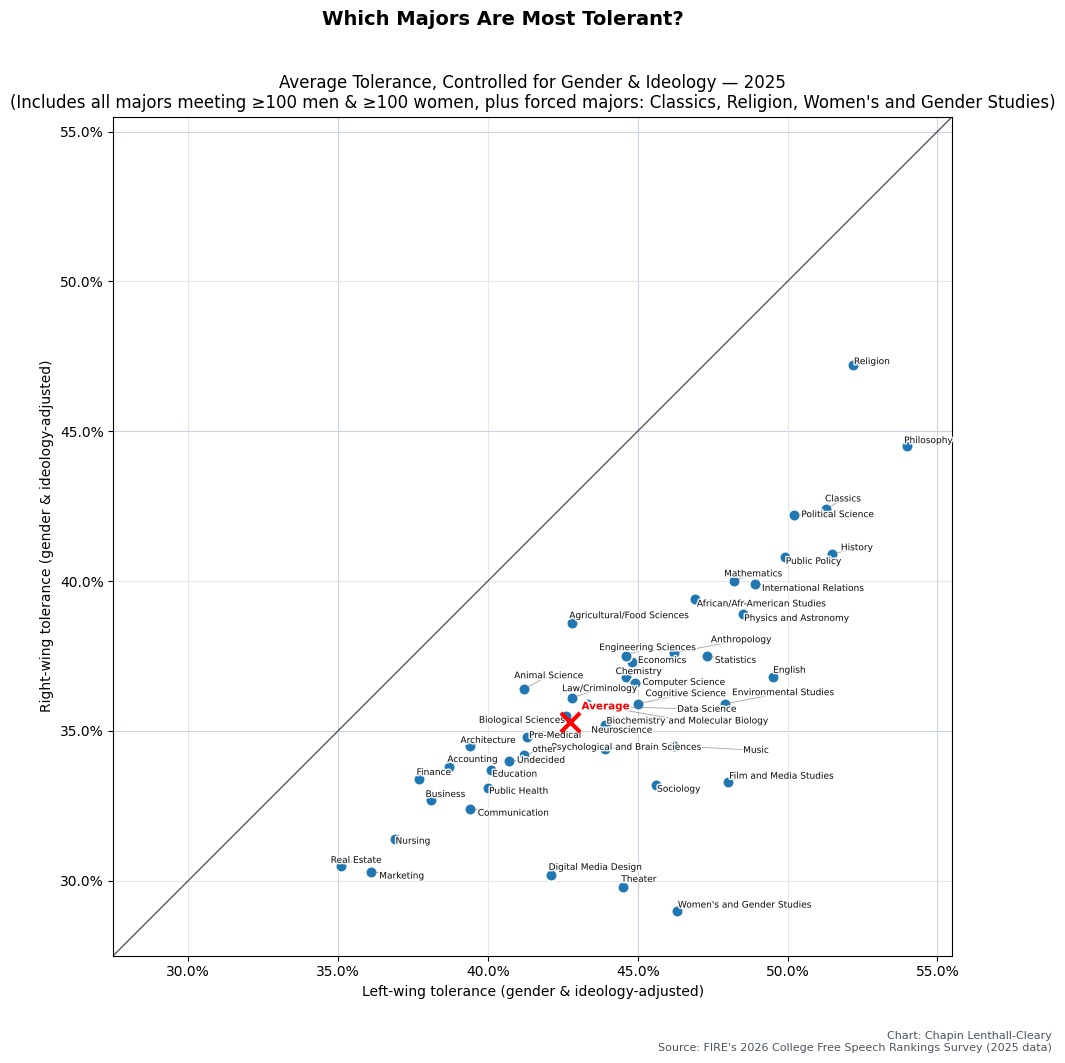

Saved: /Users/chapin.lenthall-cleary/scatter_major_left_vs_right_mfavg_gender_ideo_forcedmajors.png


In [18]:
#!/usr/bin/env python3
"""
Make ONLY Plot 2: Left vs Right tolerance by major (MF-average),
controlled for gender and ideology, and FORCE-INCLUDE:
  - Religion (major_code=62)
  - Women's and Gender Studies (major_code=73)
  - Classics (major_code=16)
even if they fail the usual sample-size thresholds.

"Controlled for gender" here = MF-average:
  mf_left  = mean(male_left_avg, female_left_avg)
  mf_right = mean(male_right_avg, female_right_avg)

"Controlled for ideology" here = ideology fixed effects (dummy regression),
implemented by residualizing each respondent-level outcome:
  y_adj = y - mean(y | ideo) + mean(y)

Also: ignore gender responses not in {1,2}.
"""

from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import matplotlib.patheffects as pe

# --- adjustText (optional but recommended) ---
try:
    from adjustText import adjust_text
    HAS_ADJUSTTEXT = True
except ImportError:
    HAS_ADJUSTTEXT = False

# ---------------- Config ----------------
CSV_PATH = Path("cfsr2026.csv")

MAJOR_COLS = ["major1", "major2", "major3"]
GENDER_COL = "gender"     # 1 = men, 2 = women
IDEO_COL = "ideo"

# Optional year filter (applies only if YEAR_COL exists in the file)
YEAR_COL = "datayear"
YEAR = 2025  # set to None to disable filtering

# Standard Plot-2 major inclusion rule (majors meeting these stay "as usual")
MIN_MEN = 100
MIN_WOMEN = 100

# Force-include these majors regardless of sample size
FORCE_INCLUDE_MAJOR_CODES = {16, 62, 73}  # Classics, Religion, Women's and Gender Studies

# Left/Right triads (your column names)
RIGHT_TRIAD = ["spkabortion", "spktrans", "spkblm"]
LEFT_TRIAD  = ["spkchurch", "spkpolice", "spkchildren"]
SPK_LR = RIGHT_TRIAD + LEFT_TRIAD

# Ideology handling for dummy-regression control:
# default = keep 1..11 exactly, no recode (DS stays 8)
IDEO_KEEP = set(range(1, 12))
IDEO_RECODE = {}  # e.g., {8: 1} if you ever want DS->Very liberal

# Figure / style
FIG_W, FIG_H = 8.8 * 1.3, 8.6 * 1.3
LABEL_FONTSIZE = 6.5
LABEL_ALPHA = 0.92
BUFFER_PP_MIN = 1.5
BUFFER_FRAC = 0.06

CREDIT_TEXT = (
    "Chart: Chapin Lenthall-Cleary\n"
    "Source: FIRE's 2026 College Free Speech Rankings Survey (2025 data)"
)
SUPTITLE_Y = 0.958
TITLE_PAD = 6
TIGHT_LAYOUT_RECT = [0.02, 0.06, 0.98, 0.945]
CREDIT_X, CREDIT_Y = 0.98, 0.025
CREDIT_COLOR = "#4b5563"

# ---- major codebook (as provided) ----
MAJOR_MAP = {
    1: "Accounting",
    2: "African/Afr-American Studies",
    3: "Agricultural/Food Sciences",
    4: "Animal Science",
    5: "Anthropology",
    6: "Archaeology",
    7: "Architecture",
    8: "Art History",
    9: "Asian/Mideast Lang & Lit",
    10: "Asian/Mideast Studies",
    11: "Physics and Astronomy",
    12: "Biochemistry and Molecular Biology",
    13: "Biological Sciences",
    14: "Business",
    15: "Chemistry",
    16: "Classics",
    17: "Cognitive Science",
    18: "Communication",
    19: "Computer Science",
    20: "Dance",
    21: "Data Science",
    22: "Development Studies",
    23: "Digital Media Design",
    24: "Earth Sciences",
    25: "Economics",
    26: "Education",
    27: "Engineering Sciences",
    28: "English",
    29: "Environmental Studies",
    30: "Ethnicity and Race Studies",
    31: "European Cultural Studies",
    32: "Fashion",
    33: "Film and Media Studies",
    34: "Finance",
    35: "Fine Arts",
    36: "French and Italian",
    37: "Geography",
    38: "German Studies",
    39: "History",
    40: "Hotel Administration",
    41: "International Relations",
    42: "Jewish Studies",
    43: "Lat Am/Latino/Carib Studies",
    44: "Law/Criminology",
    45: "Linguistics",
    46: "Marketing",
    47: "Mathematics",
    48: "Music",
    50: "Neuroscience",
    51: "Nursing",
    52: "Philosophy",
    53: "Physical Education",
    54: "Political Science",
    55: "Portuguese and Brazilian Studies",
    56: "Pre-Medical",
    57: "Psychological and Brain Sciences",
    58: "Public Health",
    59: "Public Policy",
    61: "Real Estate",
    62: "Religion",
    63: "Robotics and Intelligent Systems",
    65: "Sociology",
    66: "Spanish and Portuguese",
    67: "Statistics",
    68: "Studio Art",
    69: "Theater",
    70: "Undecided",
    71: "Urban Studies",
    72: "Visual Arts",
    73: "Women's and Gender Studies",
    74: "other",
}
EXCLUDE_MAJOR_CODES = {98, 99}


# ---------------- Helpers ----------------
def scale_triad_to_pct(sum_vals: pd.Series, k: int) -> pd.Series:
    """Maps triad sum (k..4k) to 0..100%."""
    return (sum_vals - k) / (3 * k) * 100.0


def clean_ideology(df: pd.DataFrame) -> pd.DataFrame:
    """Apply optional recodes, then keep only IDEO_KEEP."""
    if IDEO_COL not in df.columns:
        raise ValueError(f"Missing ideology column '{IDEO_COL}'.")
    df = df.copy()
    df[IDEO_COL] = pd.to_numeric(df[IDEO_COL], errors="coerce")
    for src, dst in IDEO_RECODE.items():
        df.loc[df[IDEO_COL] == src, IDEO_COL] = dst
    return df[df[IDEO_COL].isin(IDEO_KEEP)].copy()


def residualize_categorical_fe(df: pd.DataFrame, value_cols: list[str], suffix: str = "_ideoadj") -> pd.DataFrame:
    """
    Dummy-regression ideology control (fixed effects):
      y_adj = y - mean(y | ideo) + mean(y)
    """
    df = df.copy()
    for col in value_cols:
        y = pd.to_numeric(df[col], errors="coerce")
        overall_mean = float(np.nanmean(y))
        means_by_ideo = (
            pd.DataFrame({IDEO_COL: df[IDEO_COL], col: y})
            .dropna(subset=[IDEO_COL, col])
            .groupby(IDEO_COL)[col]
            .mean()
        )
        adj = y - df[IDEO_COL].map(means_by_ideo) + overall_mean
        # keep percent scale sane
        adj = np.clip(adj, 0, 100)
        df[col + suffix] = pd.to_numeric(adj, errors="coerce").round(1)
    return df


def build_major_long(df: pd.DataFrame, id_vars: list[str]) -> pd.DataFrame:
    """Melt majors long, filter valid codes, de-dupe per person/major."""
    df = df.copy()
    if "respondent_id" not in df.columns:
        df = df.reset_index().rename(columns={"index": "respondent_id"})

    for col in MAJOR_COLS:
        if col not in df.columns:
            raise ValueError(f"Missing required column '{col}'.")
        df[col] = pd.to_numeric(df[col], errors="coerce")

    valid_codes = set(MAJOR_MAP.keys()) - EXCLUDE_MAJOR_CODES
    long = (
        df.melt(
            id_vars=id_vars,
            value_vars=MAJOR_COLS,
            var_name="major_slot",
            value_name="major_code",
        )
        .dropna(subset=["major_code"])
        .copy()
    )
    long["major_code"] = pd.to_numeric(long["major_code"], errors="coerce").astype("Int64")
    long = long[long["major_code"].isin(valid_codes)].copy()
    return long.drop_duplicates(subset=["respondent_id", "major_code"])


def pivot_gender_means(agg: pd.DataFrame, value_cols: list[str]) -> pd.DataFrame:
    """Wide male_*/female_* plus male_n/female_n."""
    piv_vals = agg.pivot(index="major_code", columns=GENDER_COL, values=value_cols)
    piv_n = agg.pivot(index="major_code", columns=GENDER_COL, values=["n"])

    def rename_cols(cols):
        out = []
        for metric, gender in cols:
            sex = "male" if int(gender) == 1 else "female"
            out.append(f"{sex}_{metric}")
        return out

    piv_vals.columns = rename_cols(piv_vals.columns)
    piv_n.columns = rename_cols(piv_n.columns)

    wide = pd.concat([piv_vals, piv_n], axis=1).reset_index()

    # Ensure expected columns exist even if a gender is missing for a major
    for needed in ["male_left_avg", "female_left_avg", "male_right_avg", "female_right_avg", "male_n", "female_n"]:
        if needed not in wide.columns:
            wide[needed] = np.nan if not needed.endswith("_n") else 0

    wide["male_n"] = pd.to_numeric(wide["male_n"], errors="coerce").fillna(0).astype(int)
    wide["female_n"] = pd.to_numeric(wide["female_n"], errors="coerce").fillna(0).astype(int)
    wide["total_n"] = wide["male_n"] + wide["female_n"]

    return wide


def alternating_grid(ax):
    """Alternating 5% gridlines."""
    light_gray, medium_gray = "#e5e7eb", "#cbd5e1"
    for v in range(0, 101, 5):
        ax.axhline(v, color=(light_gray if (v // 5) % 2 == 0 else medium_gray), linewidth=0.8, zorder=0)
        ax.axvline(v, color=(light_gray if (v // 5) % 2 == 0 else medium_gray), linewidth=0.8, zorder=0)


def pick_tick_step(span: float) -> int:
    if span <= 20:
        return 2
    if span <= 40:
        return 5
    return 10


def set_square_zoom(ax, x: pd.Series, y: pd.Series):
    """Zoom to points with buffer; same limits on x and y."""
    x = pd.to_numeric(x, errors="coerce").dropna()
    y = pd.to_numeric(y, errors="coerce").dropna()
    if x.empty or y.empty:
        ax.set_xlim(0, 100)
        ax.set_ylim(0, 100)
        return (0.0, 100.0)

    minv = float(min(x.min(), y.min()))
    maxv = float(max(x.max(), y.max()))
    span = max(1e-6, maxv - minv)

    buffer = max(BUFFER_PP_MIN, BUFFER_FRAC * span)
    lo = max(0.0, minv - buffer)
    hi = min(100.0, maxv + buffer)

    if hi - lo < 5:
        mid = (hi + lo) / 2.0
        lo = max(0.0, mid - 2.5)
        hi = min(100.0, mid + 2.5)

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)

    step = pick_tick_step(hi - lo)
    start = int(np.ceil(lo / step) * step)
    end = int(np.floor(hi / step) * step)
    ax.set_xticks(list(range(start, end + 1, step)))
    ax.set_yticks(list(range(start, end + 1, step)))

    return (lo, hi)


def label_points(ax, df_points: pd.DataFrame, xcol: str, ycol: str, label_col: str):
    """Label every point; repel with adjustText if available."""
    if not HAS_ADJUSTTEXT:
        offsets = [(4, 4), (4, -6), (-6, 4), (-6, -6), (6, 0), (0, 6), (-8, 0), (0, -8)]
        for i, (_, r) in enumerate(df_points.iterrows()):
            dx, dy = offsets[i % len(offsets)]
            ax.annotate(
                str(r[label_col]),
                (float(r[xcol]), float(r[ycol])),
                textcoords="offset points",
                xytext=(dx, dy),
                ha="left" if dx >= 0 else "right",
                va="bottom" if dy >= 0 else "top",
                fontsize=LABEL_FONTSIZE,
                alpha=LABEL_ALPHA,
                zorder=4,
                path_effects=[pe.withStroke(linewidth=2.2, foreground="white")]
            )
        return

    texts = []
    for _, r in df_points.iterrows():
        t = ax.text(
            float(r[xcol]), float(r[ycol]), str(r[label_col]),
            fontsize=LABEL_FONTSIZE, alpha=LABEL_ALPHA, zorder=4,
            path_effects=[pe.withStroke(linewidth=2.2, foreground="white")]
        )
        texts.append(t)

    adjust_text(
        texts,
        ax=ax,
        expand_points=(1.25, 1.35),
        expand_text=(1.10, 1.25),
        force_points=0.10,
        force_text=0.35,
        lim=250,
        arrowprops=dict(arrowstyle="-", lw=0.6, color="0.45", alpha=0.65),
    )


def scatter_major_plot(
    df_points: pd.DataFrame,
    x: str,
    y: str,
    title: str,
    xlabel: str,
    ylabel: str,
    out_path: Path,
    suptitle_text: str,
    weights: str,
    label_col: str = "major",
):
    """Scatter with population-weighted 'Average' marker."""
    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

    alternating_grid(ax)
    ax.scatter(df_points[x], df_points[y], s=70, edgecolor="white", linewidth=1.2, zorder=3)

    # weighted average marker
    x_ser = pd.to_numeric(df_points[x], errors="coerce")
    y_ser = pd.to_numeric(df_points[y], errors="coerce")
    w = pd.to_numeric(df_points[weights], errors="coerce")

    m = x_ser.notna() & y_ser.notna() & w.notna() & (w > 0)
    if m.any():
        x_avg = float(np.average(x_ser[m], weights=w[m]))
        y_avg = float(np.average(y_ser[m], weights=w[m]))
        ax.scatter([x_avg], [y_avg], marker="x", s=190, linewidths=3.0, color="red", zorder=4.6)
        ax.annotate(
            "Average",
            (x_avg, y_avg),
            textcoords="offset points",
            xytext=(8, 8),
            ha="left",
            va="bottom",
            fontsize=LABEL_FONTSIZE + 1,
            fontweight="bold",
            color="red",
            zorder=5,
            path_effects=[pe.withStroke(linewidth=2.6, foreground="white")]
        )

    lo, hi = set_square_zoom(ax, df_points[x], df_points[y])
    ax.plot([lo, hi], [lo, hi], color="black", linewidth=1, alpha=0.65, zorder=1.5)

    ax.set_title(title, pad=TITLE_PAD)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_aspect("equal", adjustable="box")
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=100))
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))

    label_points(ax, df_points, x, y, label_col)

    fig.suptitle(suptitle_text, fontsize=14, fontweight="bold", y=SUPTITLE_Y)
    fig.text(CREDIT_X, CREDIT_Y, CREDIT_TEXT, ha="right", va="bottom", fontsize=8, color=CREDIT_COLOR)

    fig.tight_layout(rect=TIGHT_LAYOUT_RECT)
    fig.savefig(out_path, dpi=150)
    plt.show()
    print(f"Saved: {out_path.resolve()}")


# ---------------- Main ----------------
def main():
    df = pd.read_csv(CSV_PATH, low_memory=False)

    # Optional year filter
    if YEAR is not None and YEAR_COL in df.columns:
        df[YEAR_COL] = pd.to_numeric(df[YEAR_COL], errors="coerce")
        df = df[df[YEAR_COL] == YEAR].copy()

    # Keep only men/women
    df[GENDER_COL] = pd.to_numeric(df[GENDER_COL], errors="coerce")
    df = df[df[GENDER_COL].isin([1, 2])].copy()
    if df.empty:
        raise SystemExit("No rows after filtering to men/women (gender in [1,2]).")

    # Require ideology present + in keep set (for ideology control)
    df = clean_ideology(df)
    if df.empty:
        raise SystemExit("No rows after ideology filtering for dummy-regression control.")

    # Left/Right triad validity (Plot 2 requirement)
    for c in SPK_LR:
        if c not in df.columns:
            raise SystemExit(f"Missing required column '{c}' for left/right triads.")
        df[c] = pd.to_numeric(df[c], errors="coerce")

    in_range = df[SPK_LR].ge(1) & df[SPK_LR].le(4)
    df = df[in_range.all(axis=1)].copy()
    if df.empty:
        raise SystemExit("No rows remain after requiring all six left/right spk* items to be in [1,4].")

    # Compute left/right tolerance (0..100)
    df["right_sum"] = df[RIGHT_TRIAD].sum(axis=1)
    df["left_sum"] = df[LEFT_TRIAD].sum(axis=1)
    df["right_pct"] = scale_triad_to_pct(df["right_sum"], k=len(RIGHT_TRIAD))
    df["left_pct"] = scale_triad_to_pct(df["left_sum"], k=len(LEFT_TRIAD))

    # Ideology-adjust these respondent-level outcomes (dummy regression / FE)
    df = residualize_categorical_fe(df, ["left_pct", "right_pct"], suffix="_ideoadj")

    # Build major-long with gender + adjusted outcomes
    long = build_major_long(df, id_vars=["respondent_id", GENDER_COL, "left_pct_ideoadj", "right_pct_ideoadj"])

    # Gender-specific means + n (unique respondents) by major
    agg = (
        long.groupby(["major_code", GENDER_COL], as_index=False)
        .agg(
            left_avg=("left_pct_ideoadj", "mean"),
            right_avg=("right_pct_ideoadj", "mean"),
            n=("respondent_id", "nunique"),
        )
    )
    wide = pivot_gender_means(agg, ["left_avg", "right_avg"])

    wide["major_code"] = pd.to_numeric(wide["major_code"], errors="coerce").astype("Int64")
    wide["major"] = wide["major_code"].astype(int).map(MAJOR_MAP)

    # MF-average controls for gender (unweighted mean of male/female means; skipna to allow forced majors)
    wide["mf_left"] = wide[["male_left_avg", "female_left_avg"]].mean(axis=1, skipna=True)
    wide["mf_right"] = wide[["male_right_avg", "female_right_avg"]].mean(axis=1, skipna=True)

    # Round for display
    for c in ["mf_left", "mf_right", "male_left_avg", "female_left_avg", "male_right_avg", "female_right_avg"]:
        wide[c] = pd.to_numeric(wide[c], errors="coerce").round(1)

    # Keep majors that were "already there" by threshold, PLUS force-includes
    keep_standard = (wide["male_n"] >= MIN_MEN) & (wide["female_n"] >= MIN_WOMEN)
    keep_forced = wide["major_code"].astype(int).isin(list(FORCE_INCLUDE_MAJOR_CODES))
    wide_keep = wide.loc[keep_standard | keep_forced].copy()

    # Drop rows that still can't be plotted (need both coords)
    wide_keep = wide_keep.dropna(subset=["mf_left", "mf_right"])

    # Plot
    out_path = Path("scatter_major_left_vs_right_mfavg_gender_ideo_forcedmajors.png")
    scatter_major_plot(
        df_points=wide_keep,
        x="mf_left",
        y="mf_right",
        suptitle_text="Which Majors Are Most Tolerant?",
        title=f"Average Tolerance, Controlled for Gender & Ideology"
              f"{'' if YEAR is None else f' — {YEAR}'}\n"
              f"(Includes all majors meeting ≥{MIN_MEN} men & ≥{MIN_WOMEN} women, plus forced majors: "
              f"{', '.join([MAJOR_MAP[m] for m in sorted(FORCE_INCLUDE_MAJOR_CODES)])})",
        xlabel="Left-wing tolerance (gender & ideology-adjusted)",
        ylabel="Right-wing tolerance (gender & ideology-adjusted)",
        out_path=out_path,
        weights="total_n",
        label_col="major",
    )


if __name__ == "__main__":
    main()


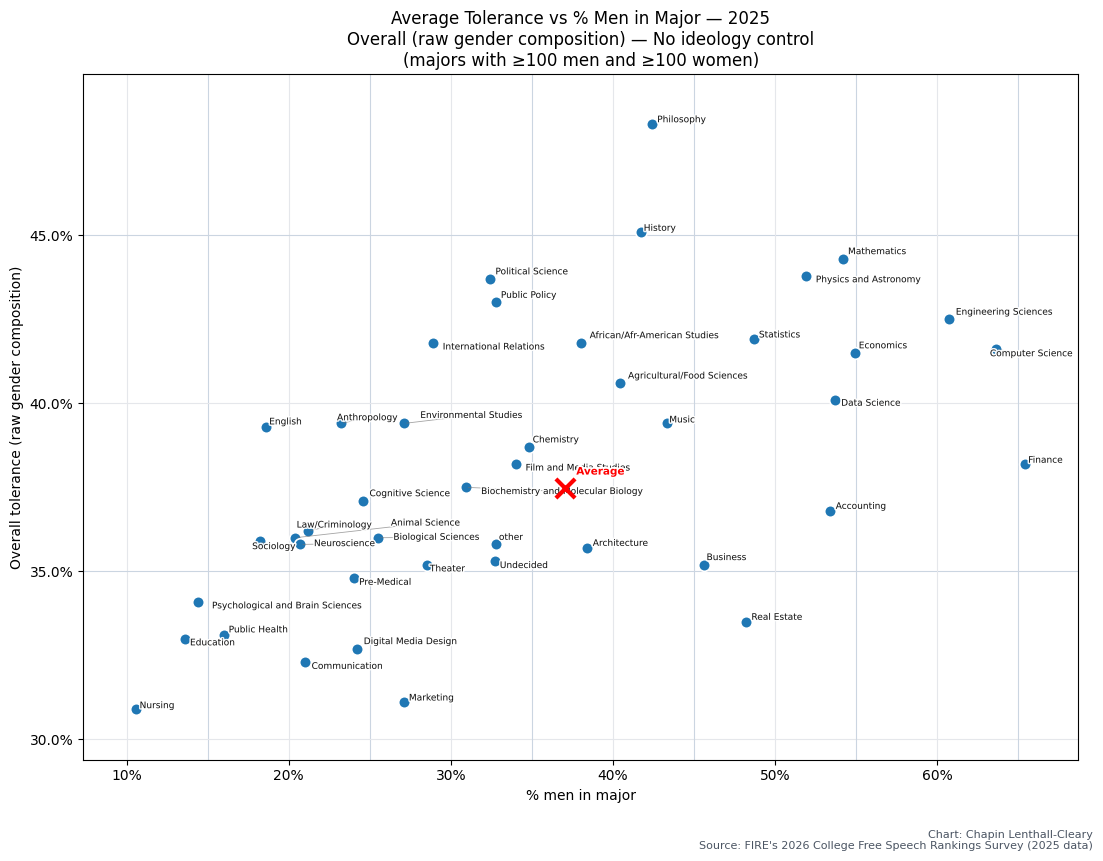

Saved: /Users/chapin.lenthall-cleary/scatter_tol_vs_malepct_overall_raw_no_ideo.png


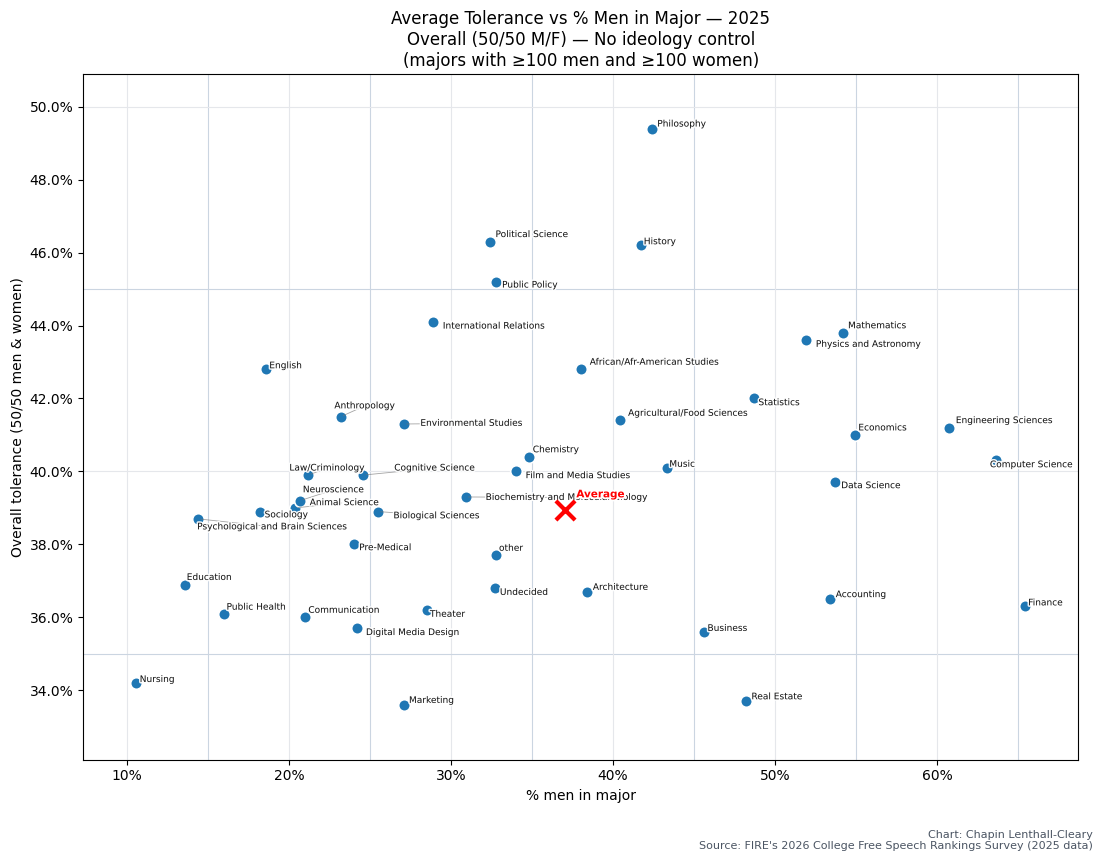

Saved: /Users/chapin.lenthall-cleary/scatter_tol_vs_malepct_overall_5050_no_ideo.png


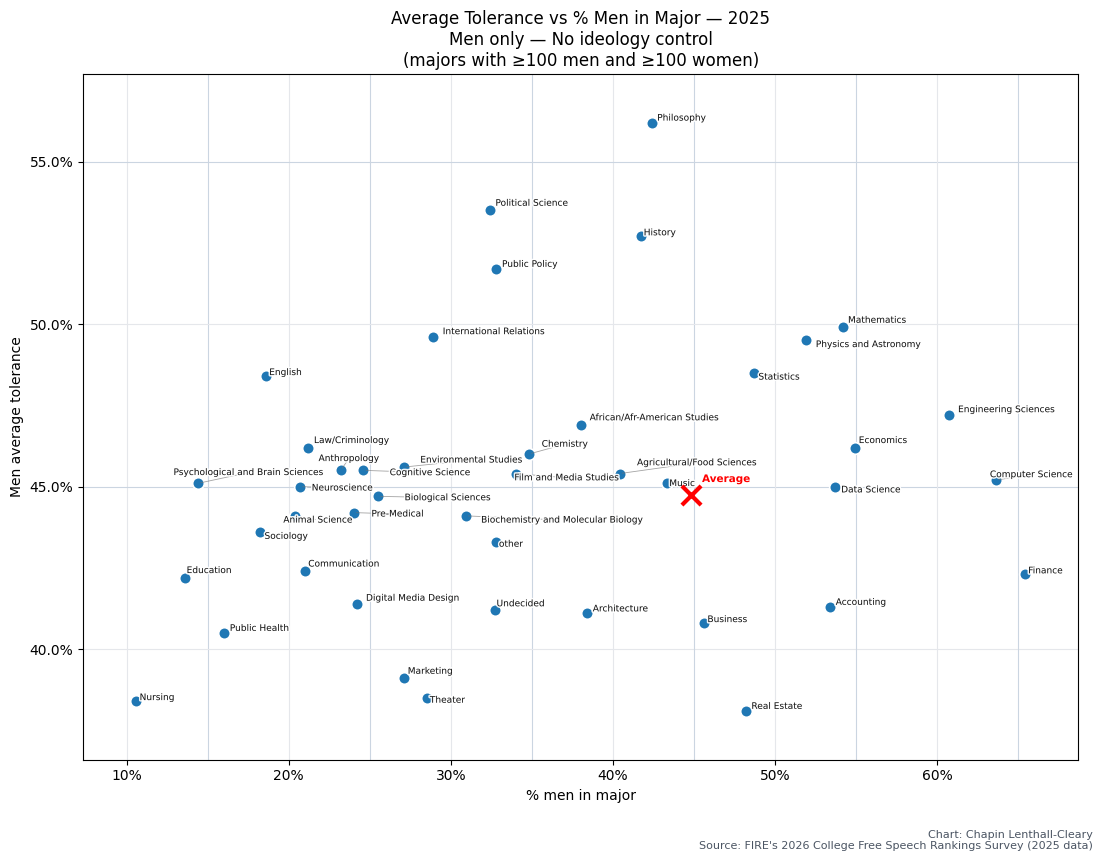

Saved: /Users/chapin.lenthall-cleary/scatter_tol_vs_malepct_male_only_no_ideo.png


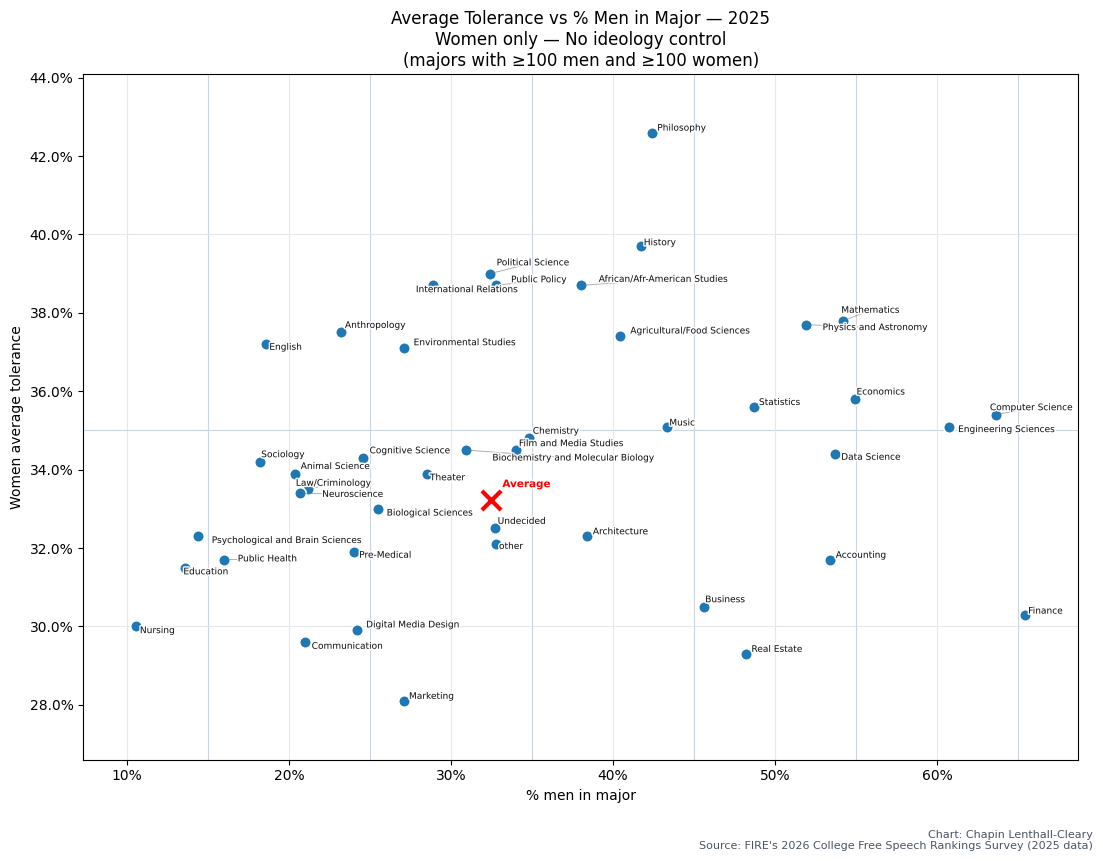

Saved: /Users/chapin.lenthall-cleary/scatter_tol_vs_malepct_female_only_no_ideo.png


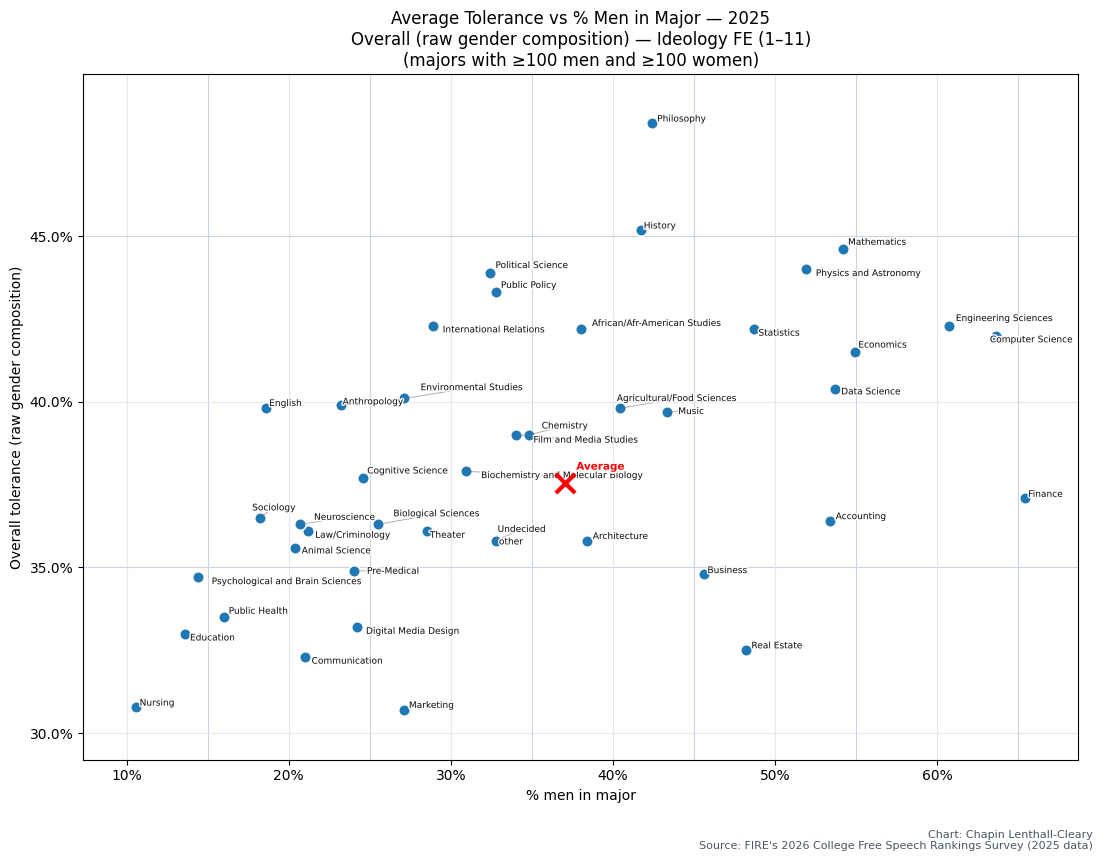

Saved: /Users/chapin.lenthall-cleary/scatter_tol_vs_malepct_overall_raw_ideoadj.png


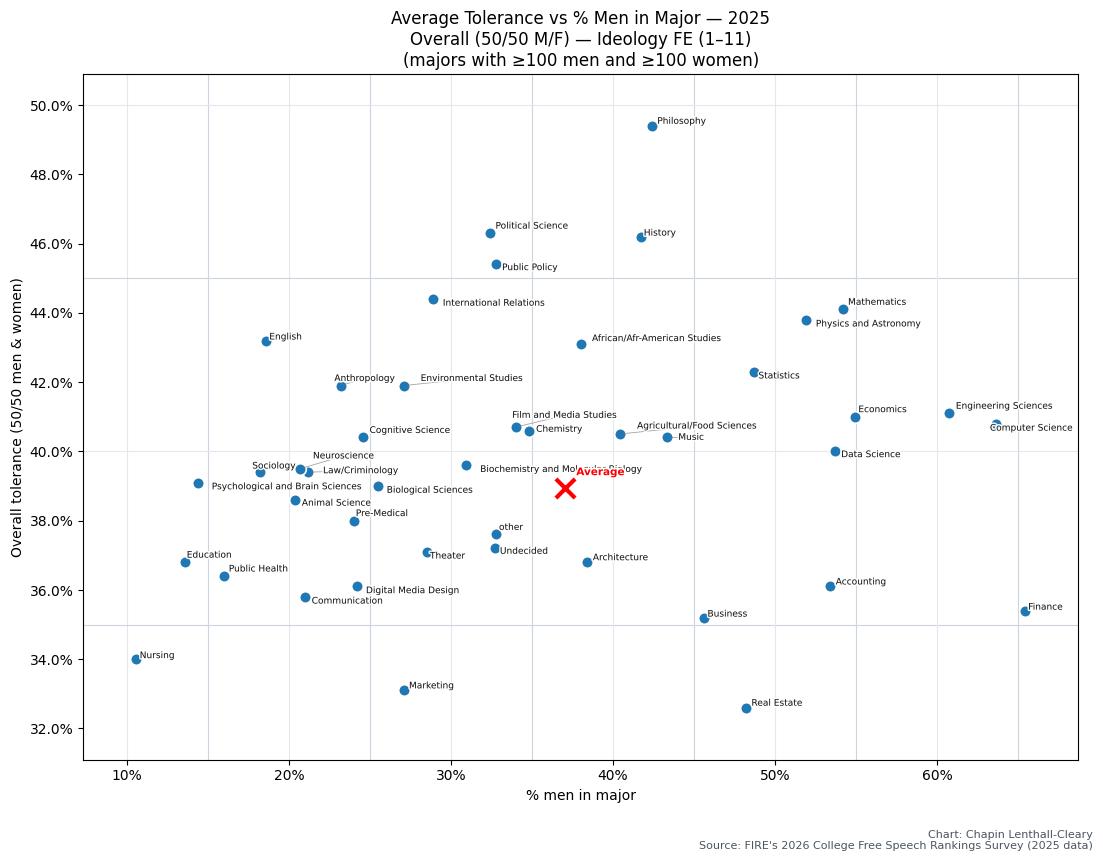

Saved: /Users/chapin.lenthall-cleary/scatter_tol_vs_malepct_overall_5050_ideoadj.png


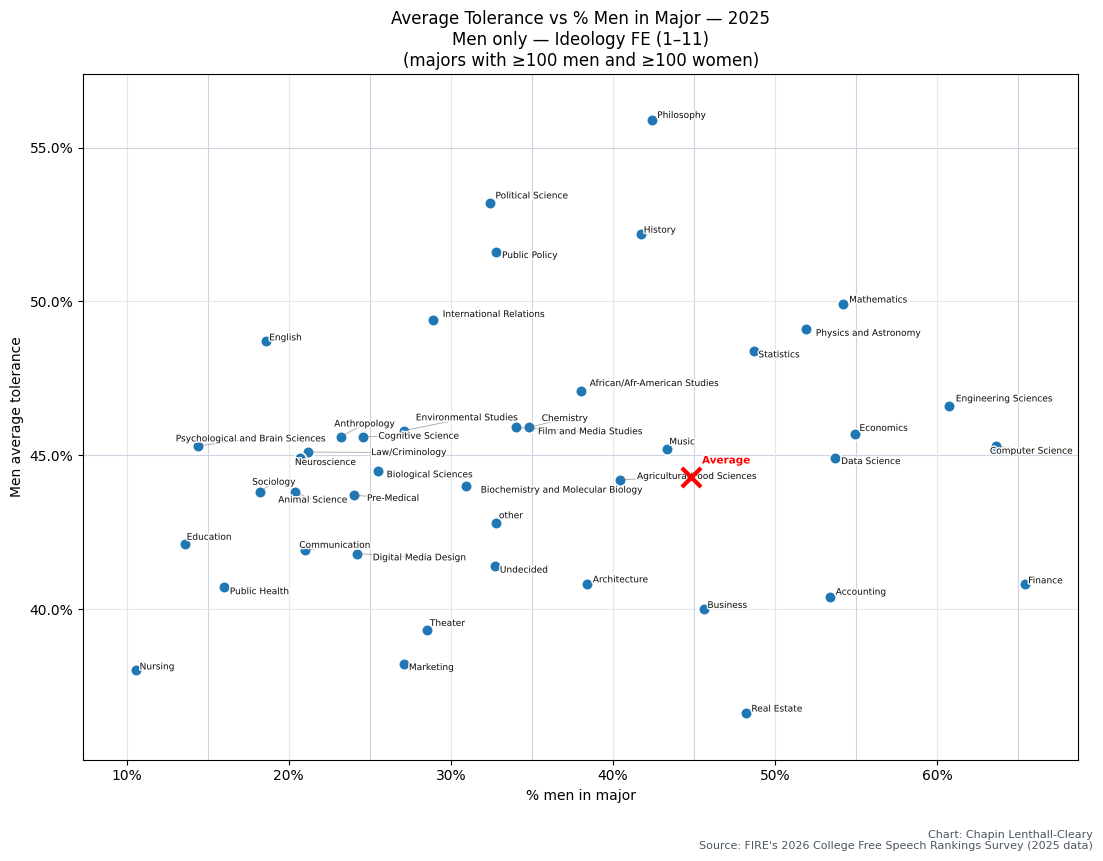

Saved: /Users/chapin.lenthall-cleary/scatter_tol_vs_malepct_male_only_ideoadj.png


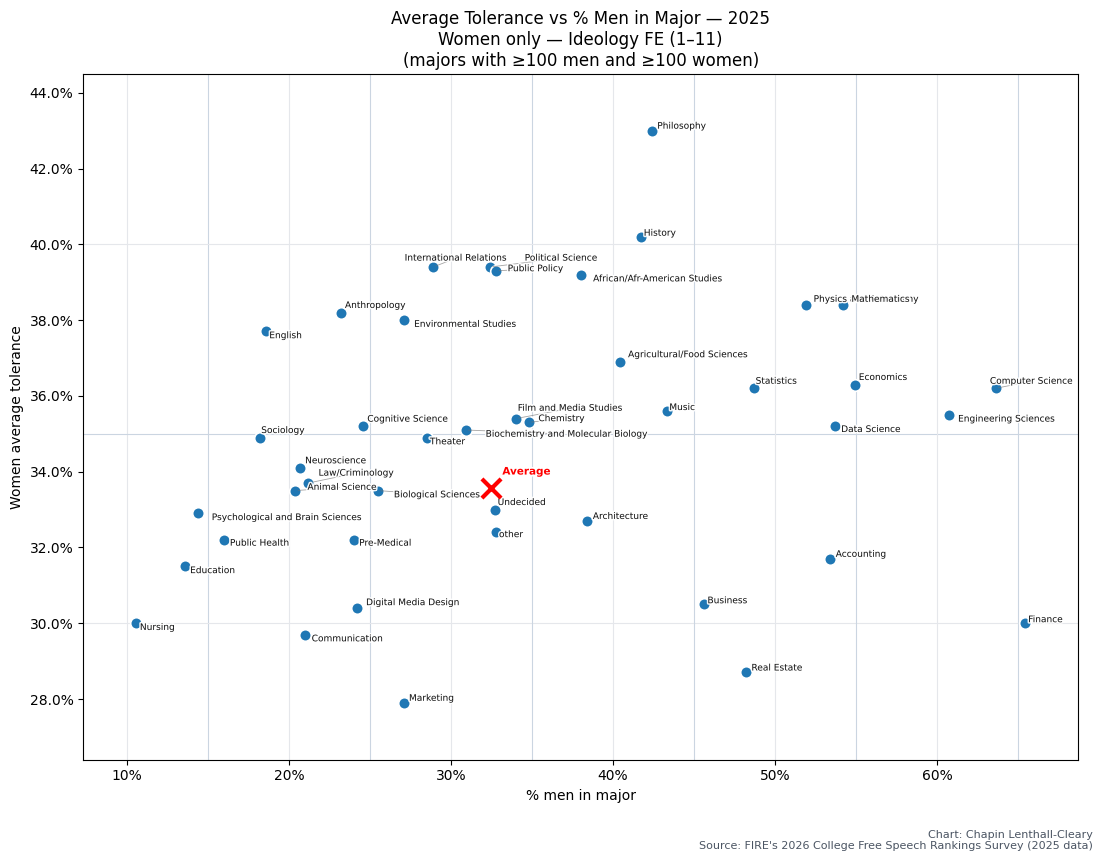

Saved: /Users/chapin.lenthall-cleary/scatter_tol_vs_malepct_female_only_ideoadj.png


In [45]:
#!/usr/bin/env python3
"""
8 scatterplots: average tolerance (y) vs % men in major (x), one point per major.
Majors restricted to those with >=100 men and >=100 women (unique respondents per major
across major1/2/3).

For EACH of two ideology conditions:
  A) NO ideology control (raw tolerance)
  B) Ideology-controlled (categorical FE over ideo codes 1..11)

We plot four y-variables:
  1) Overall tolerance (raw gender composition within major)
  2) Overall tolerance (gender-controlled via 50/50 M/F averaging)
  3) Men-only tolerance
  4) Women-only tolerance

Axes zoom to data + buffer (independently for x and y).
"""

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import matplotlib.patheffects as pe

# --- adjustText (optional but recommended) ---
try:
    from adjustText import adjust_text
    HAS_ADJUSTTEXT = True
except ImportError:
    HAS_ADJUSTTEXT = False


# ---------------- Config ----------------
CSV_PATH = Path("cfsr2026.csv")

MAJOR_COLS = ["major1", "major2", "major3"]
GENDER_COL = "gender"     # 1 = men, 2 = women
IDEO_COL = "ideo"

SPK_PREFIX = "spk"        # overall tolerance items prefix (for tolerance_score_pct)
ITEM_MIN, ITEM_MAX = 1, 4

YEAR_COL = "datayear"
YEAR = 2025  # set to None to disable filtering

MIN_MEN = 100
MIN_WOMEN = 100

# Keep the sample the same across "raw" and "ideo-controlled" plots by filtering
# to ideology codes 1..11 even for the raw plots.
KEEP_IDEO_FOR_RAW = True
IDEO_KEEP = set(range(1, 12))  # 1..11

# Keep adjusted outcomes on 0..100 percent axes
CLIP_0_100_AFTER_ADJ = True

# Figure size
FIG_W, FIG_H = 8.8 * 1.3, 8.6 * 1.1

# Labeling
LABEL_FONTSIZE = 6.5
LABEL_ALPHA = 0.92
TITLE_PAD = 6

# Zoom buffer
BUFFER_PP_MIN = 1.5
BUFFER_FRAC = 0.06

CREDIT_TEXT = (
    "Chart: Chapin Lenthall-Cleary\n"
    "Source: FIRE's 2026 College Free Speech Rankings Survey (2025 data)"
)
CREDIT_X, CREDIT_Y = 0.98, 0.025
CREDIT_COLOR = "#4b5563"
TIGHT_LAYOUT_RECT = [0.02, 0.06, 0.98, 0.93]

# ---- major codebook ----
MAJOR_MAP = {
    1: "Accounting",
    2: "African/Afr-American Studies",
    3: "Agricultural/Food Sciences",
    4: "Animal Science",
    5: "Anthropology",
    6: "Archaeology",
    7: "Architecture",
    8: "Art History",
    9: "Asian/Mideast Lang & Lit",
    10: "Asian/Mideast Studies",
    11: "Physics and Astronomy",
    12: "Biochemistry and Molecular Biology",
    13: "Biological Sciences",
    14: "Business",
    15: "Chemistry",
    16: "Classics",
    17: "Cognitive Science",
    18: "Communication",
    19: "Computer Science",
    20: "Dance",
    21: "Data Science",
    22: "Development Studies",
    23: "Digital Media Design",
    24: "Earth Sciences",
    25: "Economics",
    26: "Education",
    27: "Engineering Sciences",
    28: "English",
    29: "Environmental Studies",
    30: "Ethnicity and Race Studies",
    31: "European Cultural Studies",
    32: "Fashion",
    33: "Film and Media Studies",
    34: "Finance",
    35: "Fine Arts",
    36: "French and Italian",
    37: "Geography",
    38: "German Studies",
    39: "History",
    40: "Hotel Administration",
    41: "International Relations",
    42: "Jewish Studies",
    43: "Lat Am/Latino/Carib Studies",
    44: "Law/Criminology",
    45: "Linguistics",
    46: "Marketing",
    47: "Mathematics",
    48: "Music",
    50: "Neuroscience",
    51: "Nursing",
    52: "Philosophy",
    53: "Physical Education",
    54: "Political Science",
    55: "Portuguese and Brazilian Studies",
    56: "Pre-Medical",
    57: "Psychological and Brain Sciences",
    58: "Public Health",
    59: "Public Policy",
    61: "Real Estate",
    62: "Religion",
    63: "Robotics and Intelligent Systems",
    65: "Sociology",
    66: "Spanish and Portuguese",
    67: "Statistics",
    68: "Studio Art",
    69: "Theater",
    70: "Undecided",
    71: "Urban Studies",
    72: "Visual Arts",
    73: "Women's and Gender Studies",
    74: "other",
}
EXCLUDE_MAJOR_CODES = {98, 99}


# ---------------- Scoring helpers ----------------
def ensure_tolerance(df: pd.DataFrame,
                     prefix: str = SPK_PREFIX,
                     min_val: int = ITEM_MIN,
                     max_val: int = ITEM_MAX) -> pd.DataFrame:
    """Add tolerance_score_pct if missing, using all columns starting with prefix."""
    if "tolerance_score_pct" in df.columns:
        return df

    spk_cols = [c for c in df.columns if c.lower().startswith(prefix.lower())]
    if not spk_cols:
        raise ValueError(
            f"No tolerance items found (expected columns starting with '{prefix}') "
            "or an existing 'tolerance_score_pct'."
        )

    df = df.copy()
    df[spk_cols] = df[spk_cols].apply(pd.to_numeric, errors="coerce")
    answered = df[spk_cols].notna().sum(axis=1)
    raw_sum = df[spk_cols].sum(axis=1, min_count=1)
    min_sum = answered * min_val
    max_sum = answered * max_val

    with np.errstate(invalid="ignore", divide="ignore"):
        pct = ((raw_sum - min_sum) / (max_sum - min_sum)) * 100

    df["tolerance_score_pct"] = np.where(answered > 0, np.clip(pct, 0, 100), np.nan).round(1)
    return df


# ---------------- Ideology adjustment ----------------
def filter_ideology(df: pd.DataFrame, keep_codes: set[int]) -> pd.DataFrame:
    """Keep only rows with ideology codes in keep_codes (drops missing/other)."""
    df = df.copy()
    if IDEO_COL not in df.columns:
        raise ValueError(f"Missing required column '{IDEO_COL}'.")
    df[IDEO_COL] = pd.to_numeric(df[IDEO_COL], errors="coerce")
    return df[df[IDEO_COL].isin(keep_codes)].copy()


def residualize_categorical_fe(
    df: pd.DataFrame,
    value_cols: list[str],
    *,
    group_col: str = IDEO_COL,
    suffix: str = "_ideoadj",
    clip_0_100: bool = True
) -> pd.DataFrame:
    """
    Categorical fixed effects control:
      y_adj = y - mean(y|group) + mean(y)
    """
    df = df.copy()
    for col in value_cols:
        y = pd.to_numeric(df[col], errors="coerce")
        overall_mean = float(np.nanmean(y))

        means_by_group = (
            pd.DataFrame({group_col: df[group_col], col: y})
            .dropna(subset=[group_col, col])
            .groupby(group_col)[col]
            .mean()
        )

        adj = y - df[group_col].map(means_by_group) + overall_mean
        if clip_0_100:
            adj = np.clip(adj, 0, 100)
        df[col + suffix] = pd.to_numeric(adj, errors="coerce").round(1)

    return df


# ---------------- Major reshaping helpers ----------------
def build_major_long(df: pd.DataFrame, id_vars: list[str]) -> pd.DataFrame:
    """Melt majors long, filter valid codes, de-dupe per person/major."""
    df = df.copy()
    if "respondent_id" not in df.columns:
        df = df.reset_index().rename(columns={"index": "respondent_id"})

    for col in MAJOR_COLS:
        if col not in df.columns:
            raise ValueError(f"Missing required column '{col}'.")
        df[col] = pd.to_numeric(df[col], errors="coerce")

    valid_codes = set(MAJOR_MAP.keys()) - EXCLUDE_MAJOR_CODES

    long = (
        df.melt(
            id_vars=id_vars,
            value_vars=MAJOR_COLS,
            var_name="major_slot",
            value_name="major_code",
        )
        .dropna(subset=["major_code"])
        .copy()
    )
    long["major_code"] = pd.to_numeric(long["major_code"], errors="coerce").astype("Int64")
    long = long[long["major_code"].isin(valid_codes)].copy()

    return long.drop_duplicates(subset=["respondent_id", "major_code"])


def pivot_gender_means(agg: pd.DataFrame, value_cols: list[str]) -> pd.DataFrame:
    """Wide male_*/female_* plus male_n/female_n."""
    piv_vals = agg.pivot(index="major_code", columns=GENDER_COL, values=value_cols)
    piv_n = agg.pivot(index="major_code", columns=GENDER_COL, values=["n"])

    def rename_cols(cols):
        out = []
        for metric, gender in cols:
            sex = "male" if int(gender) == 1 else "female"
            out.append(f"{sex}_{metric}")
        return out

    piv_vals.columns = rename_cols(piv_vals.columns)
    piv_n.columns = rename_cols(piv_n.columns)

    return pd.concat([piv_vals, piv_n], axis=1).reset_index()


def filter_min_counts(df_wide: pd.DataFrame) -> pd.DataFrame:
    df_wide = df_wide.copy()
    df_wide["male_n"] = pd.to_numeric(df_wide.get("male_n"), errors="coerce")
    df_wide["female_n"] = pd.to_numeric(df_wide.get("female_n"), errors="coerce")
    keep = (df_wide["male_n"] >= MIN_MEN) & (df_wide["female_n"] >= MIN_WOMEN)
    out = df_wide.loc[keep].copy()
    out["total_n"] = out["male_n"] + out["female_n"]
    out["male_pct"] = (out["male_n"] / out["total_n"]) * 100.0
    return out


# ---------------- Plotting helpers ----------------
def alternating_grid(ax):
    """Alternating 5% gridlines across 0..100 (axes are zoomed; lines outside view are harmless)."""
    light_gray, medium_gray = "#e5e7eb", "#cbd5e1"
    for v in range(0, 101, 5):
        ax.axhline(v, color=(light_gray if (v // 5) % 2 == 0 else medium_gray), linewidth=0.8, zorder=0)
        ax.axvline(v, color=(light_gray if (v // 5) % 2 == 0 else medium_gray), linewidth=0.8, zorder=0)


def pick_tick_step(span: float) -> int:
    if span <= 20:
        return 2
    if span <= 40:
        return 5
    return 10


def set_zoom_with_buffer(
    ax,
    x: pd.Series,
    y: pd.Series,
    *,
    buffer_pp_min: float = BUFFER_PP_MIN,
    buffer_frac: float = BUFFER_FRAC,
    clip_lo: float = 0.0,
    clip_hi: float = 100.0,
):
    """Zoom x and y independently to data with a buffer; clamp to [clip_lo, clip_hi]."""
    xs = pd.to_numeric(x, errors="coerce").dropna()
    ys = pd.to_numeric(y, errors="coerce").dropna()

    if xs.empty:
        xlo, xhi = clip_lo, clip_hi
    else:
        xmin, xmax = float(xs.min()), float(xs.max())
        xspan = max(1e-6, xmax - xmin)
        xbuf = max(buffer_pp_min, buffer_frac * xspan)
        xlo = max(clip_lo, xmin - xbuf)
        xhi = min(clip_hi, xmax + xbuf)
        if xhi - xlo < 5:
            mid = (xhi + xlo) / 2.0
            xlo = max(clip_lo, mid - 2.5)
            xhi = min(clip_hi, mid + 2.5)

    if ys.empty:
        ylo, yhi = clip_lo, clip_hi
    else:
        ymin, ymax = float(ys.min()), float(ys.max())
        yspan = max(1e-6, ymax - ymin)
        ybuf = max(buffer_pp_min, buffer_frac * yspan)
        ylo = max(clip_lo, ymin - ybuf)
        yhi = min(clip_hi, ymax + ybuf)
        if yhi - ylo < 5:
            mid = (yhi + ylo) / 2.0
            ylo = max(clip_lo, mid - 2.5)
            yhi = min(clip_hi, mid + 2.5)

    ax.set_xlim(xlo, xhi)
    ax.set_ylim(ylo, yhi)

    # ticks: start/end on step boundaries
    xstep = pick_tick_step(xhi - xlo)
    ystep = pick_tick_step(yhi - ylo)

    xstart = int(np.ceil(xlo / xstep) * xstep)
    xend = int(np.floor(xhi / xstep) * xstep)
    ystart = int(np.ceil(ylo / ystep) * ystep)
    yend = int(np.floor(yhi / ystep) * ystep)

    ax.set_xticks(list(range(xstart, xend + 1, xstep)))
    ax.set_yticks(list(range(ystart, yend + 1, ystep)))


def label_points(ax, df_points: pd.DataFrame, xcol: str, ycol: str, label_col: str):
    """Label every point; repel with adjustText if available."""
    if not HAS_ADJUSTTEXT:
        offsets = [(4, 4), (4, -6), (-6, 4), (-6, -6), (6, 0), (0, 6), (-8, 0), (0, -8)]
        for i, (_, r) in enumerate(df_points.iterrows()):
            dx, dy = offsets[i % len(offsets)]
            ax.annotate(
                str(r[label_col]),
                (float(r[xcol]), float(r[ycol])),
                textcoords="offset points",
                xytext=(dx, dy),
                ha="left" if dx >= 0 else "right",
                va="bottom" if dy >= 0 else "top",
                fontsize=LABEL_FONTSIZE,
                alpha=LABEL_ALPHA,
                zorder=4,
                path_effects=[pe.withStroke(linewidth=2.2, foreground="white")]
            )
        return

    texts = []
    for _, r in df_points.iterrows():
        t = ax.text(
            float(r[xcol]), float(r[ycol]), str(r[label_col]),
            fontsize=LABEL_FONTSIZE, alpha=LABEL_ALPHA, zorder=4,
            path_effects=[pe.withStroke(linewidth=2.2, foreground="white")]
        )
        texts.append(t)

    adjust_text(
        texts,
        ax=ax,
        expand_points=(1.25, 1.35),
        expand_text=(1.10, 1.25),
        force_points=0.10,
        force_text=0.35,
        lim=250,
        arrowprops=dict(arrowstyle="-", lw=0.6, color="0.45", alpha=0.65),
    )


def scatter_major_tolerance_vs_malepct(
    df_points: pd.DataFrame,
    ycol: str,
    title: str,
    out_path: Path,
    *,
    y_label: str = "Average tolerance",
    weight_col: str = "total_n",
    label_col: str = "major",
):
    """Scatter: x=% men in major, y=tolerance metric, zoomed to data + buffer; weighted 'Average' marker."""
    needed = ["male_pct", ycol, weight_col, label_col]
    for c in needed:
        if c not in df_points.columns:
            raise ValueError(f"Missing required column '{c}' for plotting.")

    dfp = df_points.copy()
    dfp["male_pct"] = pd.to_numeric(dfp["male_pct"], errors="coerce")
    dfp[ycol] = pd.to_numeric(dfp[ycol], errors="coerce")
    dfp[weight_col] = pd.to_numeric(dfp[weight_col], errors="coerce")

    # Drop NA points so labels/float casts won't crash
    dfp = dfp.dropna(subset=["male_pct", ycol]).copy()
    if dfp.empty:
        print(f"Skipping plot (no non-missing points): {out_path}")
        return

    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
    alternating_grid(ax)

    ax.scatter(dfp["male_pct"], dfp[ycol], s=70, edgecolor="white", linewidth=1.2, zorder=3)

    # Weighted "Average" marker
    m = dfp["male_pct"].notna() & dfp[ycol].notna() & dfp[weight_col].notna() & (dfp[weight_col] > 0)
    if m.any():
        x_avg = float(np.average(dfp.loc[m, "male_pct"], weights=dfp.loc[m, weight_col]))
        y_avg = float(np.average(dfp.loc[m, ycol], weights=dfp.loc[m, weight_col]))
        ax.scatter([x_avg], [y_avg], marker="x", s=190, linewidths=3.0, color="red", zorder=4.6)
        ax.annotate(
            "Average",
            (x_avg, y_avg),
            textcoords="offset points",
            xytext=(8, 8),
            ha="left",
            va="bottom",
            fontsize=LABEL_FONTSIZE + 1,
            fontweight="bold",
            color="red",
            zorder=5,
            path_effects=[pe.withStroke(linewidth=2.6, foreground="white")]
        )

    # ✅ zoomed axes
    set_zoom_with_buffer(ax, dfp["male_pct"], dfp[ycol])

    ax.xaxis.set_major_formatter(PercentFormatter(xmax=100))
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))

    ax.set_title(title, pad=TITLE_PAD)
    ax.set_xlabel("% men in major")
    ax.set_ylabel(y_label)

    label_points(ax, dfp, "male_pct", ycol, label_col)

    fig.text(CREDIT_X, CREDIT_Y, CREDIT_TEXT, ha="right", va="bottom", fontsize=8, color=CREDIT_COLOR)
    fig.tight_layout(rect=TIGHT_LAYOUT_RECT)
    fig.savefig(out_path, dpi=150)
    plt.show()
    print(f"Saved: {out_path.resolve()}")


# ---------------- Major aggregation for tolerance ----------------
def compute_major_tolerance(df: pd.DataFrame, tol_col: str) -> pd.DataFrame:
    """
    Returns a major-level wide df with:
      - male_tolerance, female_tolerance
      - male_n, female_n, total_n, male_pct
      - overall_raw_gendercomp  (weighted by actual gender composition)
      - overall_50_50           (simple average of male & female)
    """
    df = df.copy()
    df[tol_col] = pd.to_numeric(df[tol_col], errors="coerce")

    long = build_major_long(df, id_vars=["respondent_id", GENDER_COL, tol_col])
    long = long.dropna(subset=[tol_col])

    agg = (
        long.groupby(["major_code", GENDER_COL], as_index=False)
        .agg(
            tolerance=(tol_col, "mean"),
            n=("respondent_id", "nunique"),
        )
    )

    wide = pivot_gender_means(agg, ["tolerance"])
    wide = filter_min_counts(wide)
    wide["major"] = wide["major_code"].map(MAJOR_MAP)

    wide["male_tolerance"] = pd.to_numeric(wide["male_tolerance"], errors="coerce")
    wide["female_tolerance"] = pd.to_numeric(wide["female_tolerance"], errors="coerce")

    wide["overall_raw_gendercomp"] = (
        (wide["male_tolerance"] * wide["male_n"] + wide["female_tolerance"] * wide["female_n"])
        / wide["total_n"]
    )
    wide["overall_50_50"] = wide[["male_tolerance", "female_tolerance"]].mean(axis=1, skipna=True)

    for c in ["male_pct", "overall_raw_gendercomp", "overall_50_50", "male_tolerance", "female_tolerance"]:
        wide[c] = pd.to_numeric(wide[c], errors="coerce").round(1)

    return wide


def make_8_plots(df0: pd.DataFrame):
    df0 = ensure_tolerance(df0)

    # --- RAW (no ideology adjustment) ---
    df_for_raw = df0
    if KEEP_IDEO_FOR_RAW:
        df_for_raw = filter_ideology(df_for_raw, IDEO_KEEP)

    # --- Ideology-controlled (categorical FE) ---
    df_ideo = filter_ideology(df0, IDEO_KEEP)
    df_ideo = residualize_categorical_fe(
        df_ideo,
        ["tolerance_score_pct"],
        group_col=IDEO_COL,
        suffix="_ideoadj",
        clip_0_100=CLIP_0_100_AFTER_ADJ,
    )

    # --- Major aggregation ---
    wide_raw = compute_major_tolerance(df_for_raw, "tolerance_score_pct")
    wide_ideo = compute_major_tolerance(df_ideo, "tolerance_score_pct_ideoadj")

    year_txt = "" if YEAR is None else f" — {YEAR}"
    sample_note = f"(majors with ≥{MIN_MEN} men and ≥{MIN_WOMEN} women)"

    # 4 measures x 2 ideology conditions = 8 plots
    specs = [
        # RAW ideology (no adjustment)
        (wide_raw, "overall_raw_gendercomp", "Overall tolerance (raw gender composition)", "total_n",
         f"Average Tolerance vs % Men in Major{year_txt}\nOverall (raw gender composition) — No ideology control\n{sample_note}",
         "scatter_tol_vs_malepct_overall_raw_no_ideo.png"),
        (wide_raw, "overall_50_50", "Overall tolerance (50/50 men & women)", "total_n",
         f"Average Tolerance vs % Men in Major{year_txt}\nOverall (50/50 M/F) — No ideology control\n{sample_note}",
         "scatter_tol_vs_malepct_overall_5050_no_ideo.png"),
        (wide_raw, "male_tolerance", "Men average tolerance", "male_n",
         f"Average Tolerance vs % Men in Major{year_txt}\nMen only — No ideology control\n{sample_note}",
         "scatter_tol_vs_malepct_male_only_no_ideo.png"),
        (wide_raw, "female_tolerance", "Women average tolerance", "female_n",
         f"Average Tolerance vs % Men in Major{year_txt}\nWomen only — No ideology control\n{sample_note}",
         "scatter_tol_vs_malepct_female_only_no_ideo.png"),

        # Ideology-controlled
        (wide_ideo, "overall_raw_gendercomp", "Overall tolerance (raw gender composition)", "total_n",
         f"Average Tolerance vs % Men in Major{year_txt}\nOverall (raw gender composition) — Ideology FE (1–11)\n{sample_note}",
         "scatter_tol_vs_malepct_overall_raw_ideoadj.png"),
        (wide_ideo, "overall_50_50", "Overall tolerance (50/50 men & women)", "total_n",
         f"Average Tolerance vs % Men in Major{year_txt}\nOverall (50/50 M/F) — Ideology FE (1–11)\n{sample_note}",
         "scatter_tol_vs_malepct_overall_5050_ideoadj.png"),
        (wide_ideo, "male_tolerance", "Men average tolerance", "male_n",
         f"Average Tolerance vs % Men in Major{year_txt}\nMen only — Ideology FE (1–11)\n{sample_note}",
         "scatter_tol_vs_malepct_male_only_ideoadj.png"),
        (wide_ideo, "female_tolerance", "Women average tolerance", "female_n",
         f"Average Tolerance vs % Men in Major{year_txt}\nWomen only — Ideology FE (1–11)\n{sample_note}",
         "scatter_tol_vs_malepct_female_only_ideoadj.png"),
    ]

    for df_points, ycol, ylabel, wcol, title, fname in specs:
        scatter_major_tolerance_vs_malepct(
            df_points=df_points,
            ycol=ycol,
            y_label=ylabel,
            weight_col=wcol,
            title=title,
            out_path=Path(fname),
            label_col="major",
        )


def main():
    df0 = pd.read_csv(CSV_PATH, low_memory=False)

    # Optional year filter
    if YEAR is not None and YEAR_COL in df0.columns:
        df0[YEAR_COL] = pd.to_numeric(df0[YEAR_COL], errors="coerce")
        df0 = df0[df0[YEAR_COL] == YEAR].copy()

    # Keep only men/women
    df0[GENDER_COL] = pd.to_numeric(df0[GENDER_COL], errors="coerce")
    df0 = df0[df0[GENDER_COL].isin([1, 2])].copy()
    if df0.empty:
        raise SystemExit("No rows after filtering to men/women (gender in [1,2]).")

    # Ideology column (needed for controlled plots)
    if IDEO_COL not in df0.columns:
        raise SystemExit(f"Missing required ideology column '{IDEO_COL}'.")
    df0[IDEO_COL] = pd.to_numeric(df0[IDEO_COL], errors="coerce")

    make_8_plots(df0)


if __name__ == "__main__":
    main()
